# Evolving Level-Set Models — Experimental Notebook



---

This notebook provides an experimental framework for the analysis and comparison of **Level-Set Models (LSM)** under batch, recursive, and online learning regimes.

The focus is on understanding how different learning mechanisms balance:

- **Prediction accuracy**
- **Structural complexity**
- **Online adaptability**
- **Interpretability**

when operating under **single-pass streaming constraints**.

The notebook is designed to support **transparent, reproducible comparisons** between learning paradigms.

All experiments are implemented from scratch with explicit control over initialization, update rules, and evaluation protocols, allowing the user to inspect both **numerical performance** and **structural behavior** in detail.

---

The remainder of the notebook is organized as follows:

- A formal description of the proposed **evolving Level-Set Model (e-LSM)**  
- Implementation of batch, recursive, and evolving LSM variants  
- Controlled experiments under stationary and nonstationary conditions  
- Comparative analysis in terms of accuracy, complexity, and runtime  

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

## Evolving Level-Set Model (e-LSM): Controlled e-RLSM With Adaptive Growth

The evolving Level-Set Model (e-LSM) extends the data-driven Level-Set Modeling (LSM) framework by enabling the **rule base to evolve online** while maintaining a compact structure. Unlike unconstrained growing rule bases, the proposed variant employs **soft creation throttling** and **periodic winner–neighbor merging** to balance accuracy and structural parsimony under streaming nonstationarity.

---

### Rule Representation

Each rule $$i$$ stores:

- **Center** $$\mathbf{c}_i \in \mathbb{R}^p$$  
- **Diagonal dispersion** $$\boldsymbol{\sigma}_i \in \mathbb{R}^p_{+}$$  
- **Support counter** $$n_i \in \mathbb{N}$$  
- **Reliability weight** $$r_i \in (0,1]$$  

Antecedent activation uses a diagonal Gaussian with a **mean-squared normalized distance** (matching the vectorized implementation):

$$
\tau_i(\mathbf{x})=
\exp\!\left(
-\frac{1}{2}\,\mathrm{mean}_{j=1,\dots,p}\left(\frac{x_j-c_{ij}}{\sigma_{ij}}\right)^2
\right).
$$

Reliability is incorporated multiplicatively:

$$
\tilde{\tau}_i(\mathbf{x}) = r_i\,\tau_i(\mathbf{x}).
$$

---

### Consequent Structure and Level-Set Regressor

Given effective activations $$\tilde{\boldsymbol{\tau}}(\mathbf{x})=[\tilde{\tau}_1(\mathbf{x}),\dots,\tilde{\tau}_c(\mathbf{x})]^T$$, define the normalization term:

$$
s(\mathbf{x}) = \sum_{\ell=1}^{c}\tilde{\tau}_{\ell}(\mathbf{x}) + \varepsilon,
\quad \varepsilon>0.
$$

The level-set regressor vector $$\mathbf{d}(\mathbf{x})\in\mathbb{R}^{2c}$$ stacks **two terms per rule**:

$$
d_{2i-1}(\mathbf{x})=\frac{\tilde{\tau}_i(\mathbf{x})^2}{s(\mathbf{x})},
\qquad
d_{2i}(\mathbf{x})=\frac{\tilde{\tau}_i(\mathbf{x})}{s(\mathbf{x})}.
$$

The prediction is:

$$
\hat{y}(\mathbf{x})=\mathbf{d}(\mathbf{x})^\top \mathbf{u},
\qquad
\mathbf{u}\in\mathbb{R}^{2c}.
$$

For normalized targets $$y\in[0,1]$$, the output is optionally clipped **for reporting**:

$$
\hat{y}\leftarrow \min\big(\max(\hat{y},0),1\big).
$$

---

### Initialization (Fixed Start, Comparable Complexity)

To ensure a fair starting point and avoid arbitrary early growth, e-LSM starts from a **fixed initial rule base**:

1. **K-means** provides $$N_{\mathrm{init}}$$ centers $$\{\mathbf{c}_i\}_{i=1}^{N_{\mathrm{init}}}$$.
2. Each dispersion $$\boldsymbol{\sigma}_i$$ is estimated from within-cluster standard deviations (with fallback to global statistics) and clipped:

$$
\boldsymbol{\sigma}_{\min}\le \boldsymbol{\sigma}_i \le \boldsymbol{\sigma}_{\max}.
$$

3. The consequent parameters $$\mathbf{u}$$ are initialized via a **batch least-squares** fit (DLSM) using the initial rule base.

---

### Controlled Rule Creation (Soft Brakes, No Hard Max)

At stream step $$k$$, let:

- $$\tau_{\max}=\max_i \tau_i(\mathbf{x}^k)$$ computed from **raw activations** (not reliability-weighted),
- $$\hat{y}_{\mathrm{unc}}$$ be the **unclipped** prediction,
- $$e_{\mathrm{create}}^k = y^k-\hat{y}_{\mathrm{unc}}$$.

Creation is allowed only if a **cooldown timer** is inactive (prevents bursts), and one of the following holds:

**(i) Activation-based novelty:**
$$
\tau_{\max} < \tau_{\mathrm{create}}^{\mathrm{eff}}.
$$

**(ii) Error-gated novelty:**
$$
|e_{\mathrm{create}}^k|>e_{\mathrm{create}}
\quad \wedge \quad
\tau_{\max}<\tau_{\mathrm{err}}^{\mathrm{eff}}.
$$

The thresholds become **more stringent as the model grows** (soft size penalty), with $$c$$ the current number of rules:

$$
\tau_{\mathrm{create}}^{\mathrm{eff}}=
\max\!\Big(\tau_{\mathrm{create,hard}},\ \tau_{\mathrm{create}}-\gamma\log(1+c)\Big),
$$

$$
\tau_{\mathrm{err}}^{\mathrm{eff}}=
\max\!\Big(\tau_{\mathrm{err,hard}},\ \tau_{\mathrm{err}}-\gamma\log(1+c)\Big),
$$

where $$\gamma>0$$ controls how strongly growth is discouraged as the structure expands.

**New rule initialization.** If a new rule is created at $$\mathbf{x}^k$$:

$$
\mathbf{c}_{\mathrm{new}}=\mathbf{x}^k,\qquad
\boldsymbol{\sigma}_{\mathrm{new}}=\boldsymbol{\sigma}_{\max}\mathbf{1},
\qquad
n_{\mathrm{new}}=1,\qquad
r_{\mathrm{new}}=1.
$$

Initializing with $$\boldsymbol{\sigma}_{\max}$$ intentionally starts the new rule **wide** to absorb subsequent samples and reduce over-fragmentation.

The consequent vector $$\mathbf{u}$$ and covariance $$\mathbf{P}$$ are expanded by **two parameters per new rule**.

---

### Online Consequent Learning (e-RLSM)

After the creation decision, the consequent parameters are updated using recursive least squares (RLS) with forgetting factor $$\lambda$$:

$$
\mathbf{K}^k = \frac{\mathbf{P}^{k-1}\mathbf{d}^k}{\lambda + (\mathbf{d}^k)^\top \mathbf{P}^{k-1}\mathbf{d}^k},
\qquad
\mathbf{u}^k = \mathbf{u}^{k-1} + \mathbf{K}^k e^k,
$$

$$
\mathbf{P}^k = \frac{1}{\lambda}\left(\mathbf{P}^{k-1} - \mathbf{K}^k(\mathbf{d}^k)^\top \mathbf{P}^{k-1}\right),
\qquad
e^k = y^k-\hat{y}^k.
$$

---

### Rule Drift and Dispersion Adaptation

Only the winning rule $$i^\*$$ (by raw activation) is updated.

**Center drift (incremental mean):**
$$
\mathbf{c}_{i^\*}\leftarrow \mathbf{c}_{i^\*} + \frac{\mathbf{x}^k-\mathbf{c}_{i^\*}}{n_{i^\*}+1}.
$$

**Dispersion update (incremental variance form), then clipped:**
$$
\boldsymbol{\sigma}_{i^\*}\leftarrow
\mathrm{clip}\!\left(\boldsymbol{\sigma}_{i^\*}^{\mathrm{new}},\ \boldsymbol{\sigma}_{\min},\ \boldsymbol{\sigma}_{\max}\right).
$$

This yields smooth drift with adaptation rate inversely proportional to support $$n_{i^\*}$$.

---

### Reliability Dynamics (Penalizing Poor Local Predictors)

For the winning rule $$i^\*$$, reliability is updated as:

$$
r_{i^\*}\leftarrow \beta r_{i^\*} + (1-\beta)\exp\!\left(-\frac{(e^k)^2}{2\eta^2}\right),
$$

where $$\beta\in(0,1)$$ controls memory and $$\eta>0$$ sets the error scale. Reliability affects the **effective activations** $$\tilde{\tau}_i(\cdot)$$ used to form $$\mathbf{d}(\cdot)$$, reducing the impact of locally unreliable rules without deleting them.

---

### Cheap Periodic Merging (Winner–Neighbor Compression)

To prevent redundancy at low cost, merging is attempted **periodically** (every $$M$$ steps):

1. Identify the winner $$i^\*$$.
2. Find its nearest neighbor $$j\neq i^\*$$ in Euclidean distance between centers.
3. If $$\|\mathbf{c}_{i^\*}-\mathbf{c}_j\|_2 < \varepsilon_m$$, merge $$j$$ into $$i^\*$$.

Support-weighted center and dispersion updates:

$$
\mathbf{c}_{i^\*}\leftarrow \frac{n_{i^\*}\mathbf{c}_{i^\*}+n_j\mathbf{c}_j}{n_{i^\*}+n_j},
\qquad
\boldsymbol{\sigma}_{i^\*}\leftarrow
\mathrm{clip}\!\left(\frac{n_{i^\*}\boldsymbol{\sigma}_{i^\*}+n_j\boldsymbol{\sigma}_j}{n_{i^\*}+n_j},\ \boldsymbol{\sigma}_{\min},\ \boldsymbol{\sigma}_{\max}\right).
$$

Reliability is conservatively propagated, e.g.:

$$
r_{i^\*}\leftarrow \max(r_{i^\*}, r_j).
$$

**Consequent compression.** Since each rule contributes two parameters in $$\mathbf{u}$$, merging also compresses $$\mathbf{u}$$ and $$\mathbf{P}$$. The surviving pair is support-weighted:

$$
(u_{2i^\*-1},u_{2i^\*})\leftarrow
\frac{n_{i^\*}(u_{2i^\*-1},u_{2i^\*})+n_j(u_{2j-1},u_{2j})}{n_{i^\*}+n_j},
$$

and the two parameters associated with rule $$j$$ are removed (same indices removed from $$\mathbf{P}$$).

---

### Protocol and Accounting

For each dataset, the model is run in two phases:

1. **Training stream:** initialized via k-means + DLSM and then evolved online.
2. **Test stream:** evolution remains enabled, allowing **rule creation and merging** to adapt to unseen regimes.

The implementation explicitly reports:
- final number of rules,
- test MSE,
- runtime,
- number of rules created during test,
- number of merge events during test.

---

### Summary

The proposed e-LSM is a **controlled evolving e-RLSM** combining:

- batch **k-means + DLSM** initialization,
- vectorized Gaussian activations with **reliability weighting**,
- **soft rule creation braking** (cooldown + size-adaptive thresholds) without a hard rule cap,
- **cheap periodic winner–neighbor merging** for online compression,
- single-pass **RLS** consequent learning with seamless expansion and compression.

This design aims to preserve interpretability while enabling compact, performance-driven structural adaptation in nonstationary data streams.

## Models Evaluated

The following models are implemented and compared:

- **DLSM (Batch Level-Set Model)**  
  A batch least-squares formulation that estimates all consequent parameters using the full training dataset.

- **RLSM (Recursive Level-Set Model)**  
  A recursive least-squares variant that updates parameters online with a forgetting factor, assuming a fixed rule base.

- **ALSM (Adaptive Level-Set Model)**  
  A correntropy-based recursive model designed to improve robustness to noise and outliers under online learning.

- **e-LSM (Evolving Level-Set Model)**  
  An online model that extends RLSM by allowing **structural adaptation**, including rule creation, drift, expansion, and merging, based on novelty and residual-driven criteria.

---

## Evaluation Protocol

- Training and test sets are clearly separated when applicable.
- Batch models are trained offline using the training set.
- Recursive and evolving models update parameters **online**, processing each sample once.
- Structural evolution in e-LSM is enabled only during the streaming phase.
- Performance is evaluated using:
  - Mean Squared Error (MSE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Error (MAE)
  - Coefficient of Determination (R²)
  - Number of rules (model complexity)

---


**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

## **Experiment 1: Health datasets**

---

## Datasets and Experimental Scope

The experiments cover three representative regression scenarios, spanning stationary data and real-world nonstationary streams from health and wearable monitoring:

1. **Stationary tabular data**  
   - *Diabetes dataset* (10 features, 442 instances).  
   This dataset is used as a stationary baseline to verify that evolving mechanisms do not degrade predictive performance when no concept drift is present.

2. **Wearable health data with real-world drift**  
   - *PPG-DaLiA dataset* (multimodal wearable signals; 20–200 features per instance depending on windowing, approximately 25k–50k instances).  
   The task consists of heart-rate prediction from wrist-based physiological and motion signals collected under daily-life conditions, where strong nonstationarity arises from motion artifacts, activity changes, and subject variability.

3. **Clinical physiological data with gradual drift**  
   - *BIDMC dataset* (ECG and PPG signals; 5–50 features per instance or 1 Hz numerical streams, approximately 25k instances).  
   This dataset addresses respiratory-rate prediction in a clinical monitoring setting, where nonstationarity emerges from physiological variability and sensor-related effects.

All datasets are formulated as **regression problems** and processed in a **prequential (test-then-train) streaming manner**, ensuring that models operate under single-pass, online learning constraints when applicable.


# **Experiment 1.1: Diabetes dataset (10 features, 442 instances)**

**Load & split data (50/50)**

In [ ]:
# =========================
# CELL 1 — Load & split data (50/50)
# =========================
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 0

# Load Diabetes dataset (10 inputs -> 1 output), 442 instances
data = load_diabetes()
X = data.data.astype(float)   # (442, 10)
y = data.target.astype(float) # (442,)

# 50/50 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=SEED, shuffle=True
)

# Standardize inputs (recommended)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Diabetes dataset loaded.")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

Diabetes dataset loaded.
X_train: (221, 10) y_train: (221,)
X_test : (221, 10) y_test : (221,)


**Min–max normalization**

In [ ]:
# =========================
# CELL 1b — Min–max normalization [0,1]
# =========================
import numpy as np

# Normalize inputs feature-by-feature using TRAINING statistics only
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)
X_range = np.maximum(X_max - X_min, 1e-12)

X_train = (X_train - X_min) / X_range
X_test  = (X_test  - X_min) / X_range

print("Inputs normalized to [0,1].")

# Optional: normalize outputs (recommended for ALSM / e-LSM)
NORMALIZE_Y = True

if NORMALIZE_Y:
    y_min = y_train.min()
    y_max = y_train.max()
    y_range = max(y_max - y_min, 1e-12)

    y_train = (y_train - y_min) / y_range
    y_test  = (y_test  - y_min) / y_range

    print("Outputs normalized to [0,1].")
else:
    print("Outputs NOT normalized.")

Inputs normalized to [0,1].
Outputs normalized to [0,1].


**DLSM (Batch Level-Set Model)**

In [ ]:
# =========================
# CELL 2 — Batch DLSM (ridge-regularized)
# Output: MSE + runtime
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
N_RULES      = 12     # number of clusters/rules (fixed for DLSM/RLSM/ALSM)
SIGMA_SCALE  = 1.00   # scales per-rule std (larger => broader rules)
RIDGE_LAM    = 1e-3   # <<< NEW: ridge regularization (stabilizes extrapolation)
EPS          = 1e-12
SEED         = 0
# --------------------------------------------

def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if abs(s) > eps else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_rule_activations(x, centers, sigmas, eps=1e-12):
    x = np.asarray(x, float).ravel()
    diff = (x[None, :] - centers) / np.maximum(sigmas, eps)
    return np.exp(-0.5 * np.sum(diff * diff, axis=1))

def make_rules_kmeans(X_train, n_rules, sigma_scale=1.0, seed=0):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(X_train)
    centers = km.cluster_centers_
    labels = km.labels_

    # per-cluster diagonal std; fallback to global std if cluster too small
    global_std = X_train.std(axis=0) + 1e-3
    sigmas = np.zeros_like(centers)
    for i in range(n_rules):
        Xi = X_train[labels == i]
        if Xi.shape[0] >= 5:
            sigmas[i] = Xi.std(axis=0) + 1e-3
        else:
            sigmas[i] = global_std

    sigmas *= float(sigma_scale)
    return centers, sigmas

def dlsm_fit_ridge(X, y, centers, sigmas, lam=1e-3, eps=1e-12):
    """
    Ridge-regularized batch DLSM:
      u = argmin ||D u - y||^2 + lam ||u||^2
    """
    D = np.vstack([
        build_d_from_tau(
            gaussian_rule_activations(x, centers, sigmas, eps), eps
        )
        for x in X
    ])
    I = np.eye(D.shape[1])
    u = np.linalg.solve(D.T @ D + lam * I, D.T @ y)
    return u

def predict_batch(X, u, centers, sigmas, eps=1e-12):
    yhat = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, eps)
        d = build_d_from_tau(tau, eps)
        yhat[k] = float(d @ u)
    return yhat

# -----------------------------
# Train & test
# -----------------------------
t0 = time.perf_counter()

centers_dlsm, sigmas_dlsm = make_rules_kmeans(
    X_train, N_RULES, SIGMA_SCALE, SEED
)

u_dlsm = dlsm_fit_ridge(
    X_train, y_train,
    centers_dlsm, sigmas_dlsm,
    lam=RIDGE_LAM, eps=EPS
)

yhat_test_dlsm = predict_batch(
    X_test, u_dlsm,
    centers_dlsm, sigmas_dlsm, EPS
)

mse_test_dlsm = float(np.mean((y_test - yhat_test_dlsm) ** 2))
t1 = time.perf_counter()

time_dlsm_s = float(t1 - t0)
time_dlsm_msps = 1000.0 * time_dlsm_s / max(len(y_test), 1)

print(f"DLSM (ridge) u shape: {u_dlsm.shape}")
print(f"MSE (test): {mse_test_dlsm:.6f}")
print(f"Runtime (s): {time_dlsm_s:.4f}")

DLSM (ridge) u shape: (24,)
MSE (test): 0.037514
Runtime (s): 0.1821


**DLSM: Plots**  

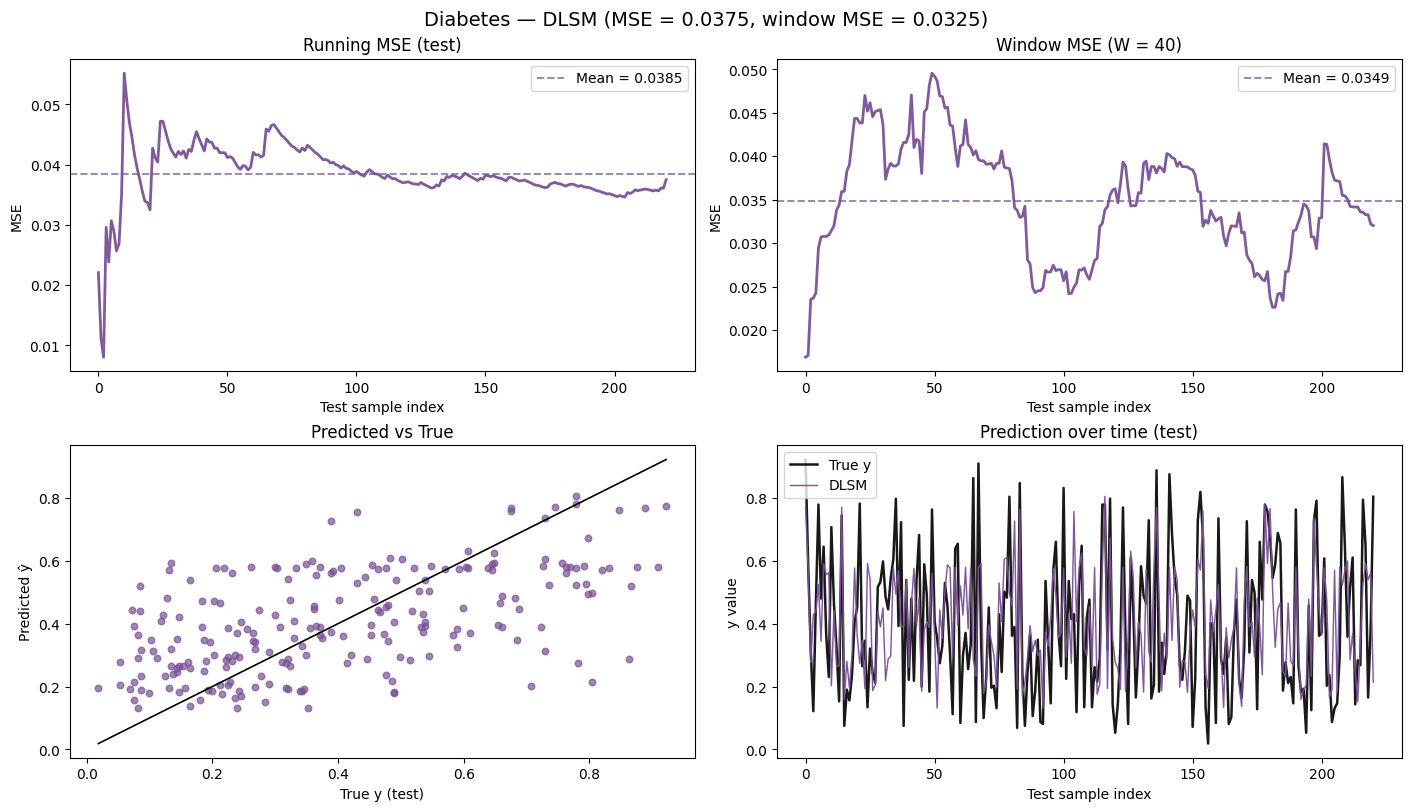

In [ ]:
# =========================
# CELL 3 — DLSM visualization (Diabetes)
# Compact overview
# Panels (2×2):
#   (1) running MSE | (2) window MSE
#   (3) predicted vs true | (4) prediction over time
# =========================
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Colors & style (EXACTLY aligned with MG final plots)
# -------------------------
TRUE_COLOR = "black"
DLSM_COLOR = "#7A5195"   # muted purple (same as MG global comparison)

LW_RUNMSE = 2.0
LW_PRED   = 1.05
LW_TRUE   = 1.8

# -------------------------
# Error metrics
# -------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W):
    e2 = (y_true - y_pred) ** 2
    return np.convolve(e2, np.ones(W) / W, mode="same")

# -------------------------
# Prepare data
# -------------------------
y_test_d = np.asarray(y_test, float).ravel()
yhat_d   = np.asarray(yhat_test_dlsm, float).ravel()

mse_curve = running_mse(y_test_d, yhat_d)

# Rounded, safe window size (human-friendly)
W = 40 if len(y_test_d) >= 40 else max(5, len(y_test_d) // 4)
wmse_curve = window_mse(y_test_d, yhat_d, W=W)

mse_final  = float(np.mean((y_test_d - yhat_d) ** 2))
wmse_final = float(np.mean(wmse_curve[-W:]))

t = np.arange(len(y_test_d))

# Mean lines
mse_mean  = float(np.mean(mse_curve))
wmse_mean = float(np.mean(wmse_curve))

# ---------------------------------------------------------
# FIGURE — 2 × 2 layout (REFERENCE WIDTH — keep for RLSM)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# (1) Running MSE
axes[0, 0].plot(mse_curve, color=DLSM_COLOR, linewidth=LW_RUNMSE, alpha=0.95)
axes[0, 0].axhline(
    mse_mean,
    linestyle="--",
    linewidth=1.4,
    color=DLSM_COLOR,
    alpha=0.7,
    label=f"Mean = {mse_mean:.4f}"
)
axes[0, 0].set_title("Running MSE (test)")
axes[0, 0].set_xlabel("Test sample index")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend()

# (2) Window MSE
axes[0, 1].plot(wmse_curve, color=DLSM_COLOR, linewidth=LW_RUNMSE, alpha=0.95)
axes[0, 1].axhline(
    wmse_mean,
    linestyle="--",
    linewidth=1.4,
    color=DLSM_COLOR,
    alpha=0.7,
    label=f"Mean = {wmse_mean:.4f}"
)
axes[0, 1].set_title(f"Window MSE (W = {W})")
axes[0, 1].set_xlabel("Test sample index")
axes[0, 1].set_ylabel("MSE")
axes[0, 1].legend()

# (3) Predicted vs True
axes[1, 0].scatter(
    y_test_d, yhat_d,
    s=22,
    alpha=0.7,
    color=DLSM_COLOR
)
mn = float(min(y_test_d.min(), yhat_d.min()))
mx = float(max(y_test_d.max(), yhat_d.max()))
axes[1, 0].plot([mn, mx], [mn, mx], color=TRUE_COLOR, linewidth=1.2)
axes[1, 0].set_xlabel("True y (test)")
axes[1, 0].set_ylabel("Predicted ŷ")
axes[1, 0].set_title("Predicted vs True")

# (4) Prediction over time
axes[1, 1].plot(
    t, y_test_d,
    label="True y",
    color=TRUE_COLOR,
    linewidth=LW_TRUE,
    alpha=0.9
)
axes[1, 1].plot(
    t, yhat_d,
    label="DLSM",
    color=DLSM_COLOR,
    linewidth=LW_PRED,
    alpha=0.95
)
axes[1, 1].set_xlabel("Test sample index")
axes[1, 1].set_ylabel("y value")
axes[1, 1].set_title("Prediction over time (test)")
axes[1, 1].legend()

fig.suptitle(
    f"Diabetes — DLSM (MSE = {mse_final:.4f}, window MSE = {wmse_final:.4f})",
    fontsize=14
)

plt.show()

**RLSM (Recursive Level-Set Model)**  

In [ ]:
# =========================
# CELL 4 — RLSM (only) — Diabetes
# Output: MSE + runtime + store predictions for later comparison
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
# (Match MG defaults; keep N_RULES consistent with your Diabetes DLSM cell if desired)
N_RULES        = 12
SIGMA_SCALE    = 1.00

ALPHA          = 1e5    # P0 = ALPHA * I
LAMBDA         = 1.0    # forgetting factor
UPDATE_ON_TEST = False  # True = continue adapting on test; False = freeze after training

EPS            = 1e-12
SEED           = 0
# --------------------------------------------

def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if abs(s) > eps else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_rule_activations(x, centers, sigmas, eps=1e-12):
    x = np.asarray(x, float).ravel()
    diff = (x[None, :] - centers) / np.maximum(sigmas, eps)
    return np.exp(-0.5 * np.sum(diff * diff, axis=1))

def make_rules_kmeans(X_train, n_rules, sigma_scale=1.0, seed=0):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(X_train)
    centers = km.cluster_centers_
    labels = km.labels_

    global_std = X_train.std(axis=0) + 1e-3
    sigmas = np.zeros_like(centers)
    for i in range(n_rules):
        Xi = X_train[labels == i]
        sigmas[i] = (Xi.std(axis=0) + 1e-3) if Xi.shape[0] >= 5 else global_std
    sigmas *= float(sigma_scale)
    return centers, sigmas

class RLSM:
    # RLSM = ALSM with psi=1 always
    def __init__(self, n_rules, alpha=1e5, lam=1.0, eps=1e-12):
        self.n_rules = int(n_rules)
        self.dim = 2 * self.n_rules
        self.u = np.zeros((self.dim,), float)
        self.P = float(alpha) * np.eye(self.dim, dtype=float)
        self.lam = float(lam)
        self.eps = float(eps)

    def update(self, d, y):
        y = float(y)
        e = y - float(d @ self.u)

        Pd = self.P @ d
        denom = self.lam + float(d @ Pd)
        if abs(denom) < self.eps:
            denom = self.eps if denom >= 0 else -self.eps

        self.P = (1.0 / self.lam) * (self.P - (1.0 / denom) * np.outer(Pd, Pd))
        self.u = self.u + (self.P @ d) * e
        return float(d @ self.u)

def predict_with_optional_update(model, X, y, centers, sigmas, do_update, eps=1e-12):
    yhat = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, eps)
        d = build_d_from_tau(tau, eps)
        if do_update:
            yhat[k] = model.update(d, y[k])
        else:
            yhat[k] = float(d @ model.u)
    return yhat

# -----------------------------
# Run RLSM on Diabetes
# -----------------------------
t0 = time.perf_counter()

centers_rlsm, sigmas_rlsm = make_rules_kmeans(X_train, N_RULES, SIGMA_SCALE, SEED)
rlsm = RLSM(n_rules=N_RULES, alpha=ALPHA, lam=LAMBDA, eps=EPS)

# Train stream (always updates)
_ = predict_with_optional_update(
    rlsm, X_train, y_train,
    centers_rlsm, sigmas_rlsm,
    do_update=True, eps=EPS
)

# Test phase (freeze or continue adapting)
yhat_test_rlsm = predict_with_optional_update(
    rlsm, X_test, y_test,
    centers_rlsm, sigmas_rlsm,
    do_update=UPDATE_ON_TEST, eps=EPS
)

y_test_r = np.asarray(y_test, float).ravel()
yhat_r   = np.asarray(yhat_test_rlsm, float).ravel()

mse_test_rlsm = float(np.mean((y_test_r - yhat_r) ** 2))

t1 = time.perf_counter()
runtime_rlsm_s   = float(t1 - t0)
runtime_rlsm_ms  = 1000.0 * runtime_rlsm_s / len(y_test_r)

print(
    f"RLSM u shape: {rlsm.u.shape} | "
    f"MSE(test)={mse_test_rlsm:.6f} | "
    f"time={runtime_rlsm_s:.4f}s | "
    f"UPDATE_ON_TEST={UPDATE_ON_TEST}"
)

# Optional: store for later global comparison (same pattern as MG)
rlsm_model = (centers_rlsm, sigmas_rlsm, rlsm.u.copy(), rlsm.P.copy())

RLSM u shape: (24,) | MSE(test)=0.037548 | time=0.0603s | UPDATE_ON_TEST=False


**RLSM: Plots**

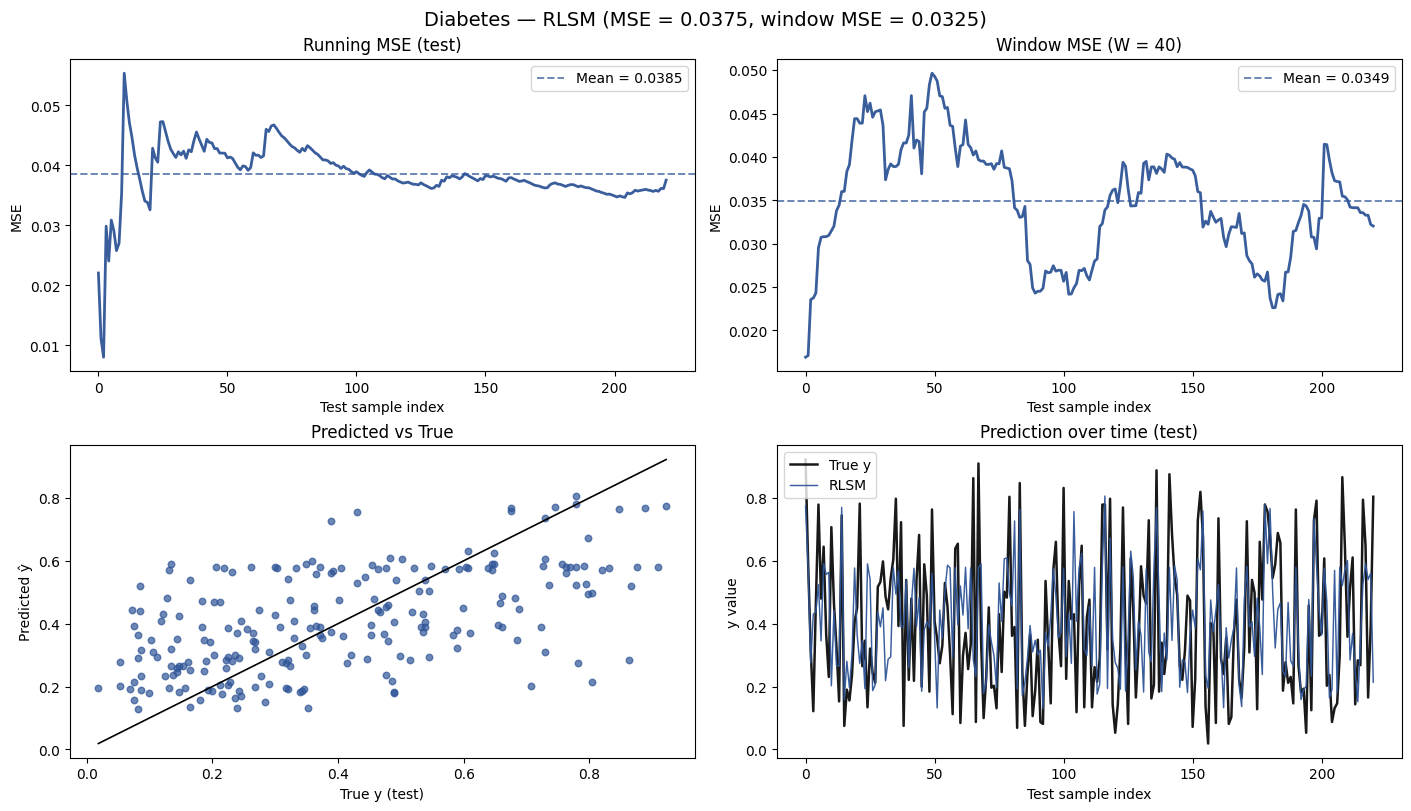

In [ ]:
# =========================
# CELL 5 — RLSM visualization (Diabetes)
# Compact overview (2×2)
# Panels:
#   (1) running MSE | (2) window MSE
#   (3) predicted vs true | (4) prediction over time
# =========================
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Colors & style (EXACT match with MG + DLSM)
# -------------------------
TRUE_COLOR = "black"
RLSM_COLOR = "#2F5597"   # darker blue (as in CELL 13)

LW_TRUE   = 1.8
LW_PRED   = 1.05
LW_RUNMSE = 2.0

# -------------------------
# Error metrics
# -------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W):
    e2 = (y_true - y_pred) ** 2
    return np.convolve(e2, np.ones(W) / W, mode="same")

# -------------------------
# Prepare data
# -------------------------
y_test_r = np.asarray(y_test, float).ravel()
yhat_r   = np.asarray(yhat_test_rlsm, float).ravel()

# Rounded, human-friendly window
W = 40 if len(y_test_r) >= 40 else max(5, len(y_test_r) // 4)

rmse_curve = running_mse(y_test_r, yhat_r)
wmse_curve = window_mse(y_test_r, yhat_r, W=W)

rmse_mean = float(np.mean(rmse_curve))
wmse_mean = float(np.mean(wmse_curve))

mse_final  = float(np.mean((y_test_r - yhat_r) ** 2))
wmse_final = float(np.mean(wmse_curve[-W:]))

t = np.arange(len(y_test_r))

# ---------------------------------------------------------
# FIGURE — 2 × 2 layout (SAME WIDTH AS DLSM)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# (1) Running MSE
axes[0, 0].plot(rmse_curve, color=RLSM_COLOR, linewidth=LW_RUNMSE, alpha=0.95)
axes[0, 0].axhline(
    rmse_mean,
    linestyle="--",
    linewidth=1.4,
    color=RLSM_COLOR,
    alpha=0.7,
    label=f"Mean = {rmse_mean:.4f}"
)
axes[0, 0].set_title("Running MSE (test)")
axes[0, 0].set_xlabel("Test sample index")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend()

# (2) Window MSE
axes[0, 1].plot(wmse_curve, color=RLSM_COLOR, linewidth=LW_RUNMSE, alpha=0.95)
axes[0, 1].axhline(
    wmse_mean,
    linestyle="--",
    linewidth=1.4,
    color=RLSM_COLOR,
    alpha=0.7,
    label=f"Mean = {wmse_mean:.4f}"
)
axes[0, 1].set_title(f"Window MSE (W = {W})")
axes[0, 1].set_xlabel("Test sample index")
axes[0, 1].set_ylabel("MSE")
axes[0, 1].legend()

# (3) Predicted vs True
axes[1, 0].scatter(
    y_test_r, yhat_r,
    s=22,
    alpha=0.7,
    color=RLSM_COLOR
)
mn = float(min(y_test_r.min(), yhat_r.min()))
mx = float(max(y_test_r.max(), yhat_r.max()))
axes[1, 0].plot([mn, mx], [mn, mx], color=TRUE_COLOR, linewidth=1.2)
axes[1, 0].set_xlabel("True y (test)")
axes[1, 0].set_ylabel("Predicted ŷ")
axes[1, 0].set_title("Predicted vs True")

# (4) Prediction over time
axes[1, 1].plot(
    t, y_test_r,
    label="True y",
    color=TRUE_COLOR,
    linewidth=LW_TRUE,
    alpha=0.9
)
axes[1, 1].plot(
    t, yhat_r,
    label="RLSM",
    color=RLSM_COLOR,
    linewidth=LW_PRED,
    alpha=0.95
)
axes[1, 1].set_xlabel("Test sample index")
axes[1, 1].set_ylabel("y value")
axes[1, 1].set_title("Prediction over time (test)")
axes[1, 1].legend()

fig.suptitle(
    f"Diabetes — RLSM (MSE = {mse_final:.4f}, window MSE = {wmse_final:.4f})",
    fontsize=14
)

plt.show()

**ALSM (Adaptive Level-Set Model)**

In [ ]:
# =========================
# CELL 6 — ALSM (Diabetes)
# - bounded correntropy weight in (0,1]
# - ridge-stabilized RLS update
# - numerically stable Gaussian activations (log-sum-exp)
# - optional online adaptation on test
# - optional clipping ONLY for evaluation (useful if y is normalized to [0,1])
# Output: MSE + runtime + basic diagnostics
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
N_RULES        = 10
SIGMA_SCALE    = 1.00
ALPHA          = 1e3
LAMBDA         = 0.998
ZETA           = 0.95        # if y is normalized to [0,1]; if NOT normalized, use larger (e.g., 20..80)
RIDGE          = 5e-3
UPDATE_ON_TEST = False
CLIP_YHAT      = True        # set True ONLY if y is normalized to [0,1]
EPS            = 1e-12
SEED           = 0
# --------------------------------------------

print("N_RULES", N_RULES,
      "SIGMA_SCALE", SIGMA_SCALE,
      "ALPHA", ALPHA,
      "LAMBDA", LAMBDA,
      "ZETA", ZETA,
      "RIDGE", RIDGE,
      "UPDATE_ON_TEST", UPDATE_ON_TEST,
      "CLIP_YHAT", CLIP_YHAT)

# -------------------------
# Helper functions
# -------------------------
def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = float(np.sum(tau))
    if not np.isfinite(s) or s < eps:
        tau = np.ones_like(tau) / max(len(tau), 1)
        s = 1.0
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_rule_activations(x, centers, sigmas, eps=1e-12):
    x = np.asarray(x, float).ravel()
    sig = np.maximum(sigmas, eps)
    diff = (x[None, :] - centers) / sig
    dist2 = np.sum(diff * diff, axis=1)
    a = -0.5 * dist2
    a = a - np.max(a)  # stabilize
    return np.exp(a)

def make_rules_kmeans(X_train, n_rules, sigma_scale=1.0, seed=0):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(X_train)
    centers = km.cluster_centers_
    labels = km.labels_

    global_std = X_train.std(axis=0) + 1e-3
    sigmas = np.zeros_like(centers)
    for i in range(n_rules):
        Xi = X_train[labels == i]
        sigmas[i] = (Xi.std(axis=0) + 1e-3) if Xi.shape[0] >= 5 else global_std
    sigmas *= float(sigma_scale)
    return centers, sigmas

# -------------------------
# ALSM model (SAFE)
# -------------------------
class ALSM:
    def __init__(self, n_rules, alpha, lam, zeta, ridge, clip_yhat=True, eps=1e-12):
        self.n_rules = int(n_rules)
        self.dim = 2 * self.n_rules
        self.u = np.zeros((self.dim,), float)
        self.P = float(alpha) * np.eye(self.dim, dtype=float)
        self.lam = float(lam)
        self.zeta = float(zeta)
        self.ridge = float(ridge)
        self.clip_yhat = bool(clip_yhat)
        self.eps = float(eps)

    def psi(self, e):
        # bounded correntropy weight in (0,1]
        z = max(self.zeta, self.eps)
        return float(np.exp(-(e*e) / (2.0*z*z)))

    def step(self, d, y):
        y = float(y)
        yhat_raw = float(d @ self.u)
        yhat_eval = float(np.clip(yhat_raw, 0.0, 1.0)) if self.clip_yhat else yhat_raw

        # learning uses RAW residual (important)
        e = y - yhat_raw
        w = self.psi(e)

        Pd = self.P @ d
        denom = self.lam + w * float(d @ Pd) + self.ridge
        if abs(denom) < self.eps:
            denom = self.eps if denom >= 0 else -self.eps

        K = Pd / denom
        self.u = self.u + (w * K) * e
        self.P = (1.0 / self.lam) * (self.P - w * np.outer(K, Pd))

        return yhat_eval, yhat_raw

def run_stream(model, X, y, centers, sigmas, do_update):
    yhat = np.zeros((X.shape[0],), float)
    yraw = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, eps=EPS)
        d = build_d_from_tau(tau, eps=EPS)
        if do_update:
            yhat[k], yraw[k] = model.step(d, y[k])
        else:
            yraw_k = float(d @ model.u)
            yhat[k] = float(np.clip(yraw_k, 0.0, 1.0)) if model.clip_yhat else yraw_k
            yraw[k] = yraw_k
    return yhat, yraw

# -------------------------
# Run ALSM (Diabetes)
# -------------------------
t0 = time.perf_counter()

centers_alsm, sigmas_alsm = make_rules_kmeans(X_train, N_RULES, SIGMA_SCALE, SEED)
alsm = ALSM(
    n_rules=N_RULES,
    alpha=ALPHA,
    lam=LAMBDA,
    zeta=ZETA,
    ridge=RIDGE,
    clip_yhat=CLIP_YHAT,
    eps=EPS
)

# TRAIN (always updates)
_ = run_stream(
    alsm,
    X_train,
    np.asarray(y_train, float).ravel(),
    centers_alsm,
    sigmas_alsm,
    do_update=True
)

# TEST (freeze or adapt)
y_test_ = np.asarray(y_test, float).ravel()
yhat_test_alsm, yraw_test_alsm = run_stream(
    alsm,
    X_test,
    y_test_,
    centers_alsm,
    sigmas_alsm,
    do_update=UPDATE_ON_TEST
)

mse_test_alsm = float(np.mean((y_test_ - yhat_test_alsm) ** 2))
clip_rate = float(np.mean((yraw_test_alsm < 0.0) | (yraw_test_alsm > 1.0))) if CLIP_YHAT else 0.0

t1 = time.perf_counter()

runtime_alsm = float(t1 - t0)
time_alsm_s = runtime_alsm
time_alsm_msps = 1000.0 * time_alsm_s / max(len(y_test_), 1)

print(f"Diabetes: ALSM u {alsm.u.shape} | MSE(test)={mse_test_alsm:.6f} | time={runtime_alsm:.4f}s "
      f"| UPDATE_ON_TEST={UPDATE_ON_TEST} | ZETA={ZETA} | CLIP_YHAT={CLIP_YHAT}")
print(f"          y_test range     = [{y_test_.min():.4f}, {y_test_.max():.4f}]")
print(f"          yhat_raw range   = [{yraw_test_alsm.min():.4f}, {yraw_test_alsm.max():.4f}]")
print(f"          yhat_eval range  = [{yhat_test_alsm.min():.4f}, {yhat_test_alsm.max():.4f}]")
if CLIP_YHAT:
    print(f"          clip_rate        = {clip_rate:.3f}")

# Optional: store for later global comparison
alsm_model = (centers_alsm, sigmas_alsm, alsm.u.copy(), alsm.P.copy())

N_RULES 10 SIGMA_SCALE 1.0 ALPHA 1000.0 LAMBDA 0.998 ZETA 0.95 RIDGE 0.005 UPDATE_ON_TEST False CLIP_YHAT True
Diabetes: ALSM u (20,) | MSE(test)=0.039287 | time=0.1191s | UPDATE_ON_TEST=False | ZETA=0.95 | CLIP_YHAT=True
          y_test range     = [0.0187, 0.9221]
          yhat_raw range   = [0.1149, 0.9666]
          yhat_eval range  = [0.1149, 0.9666]
          clip_rate        = 0.000


**ALSM: Plots**  

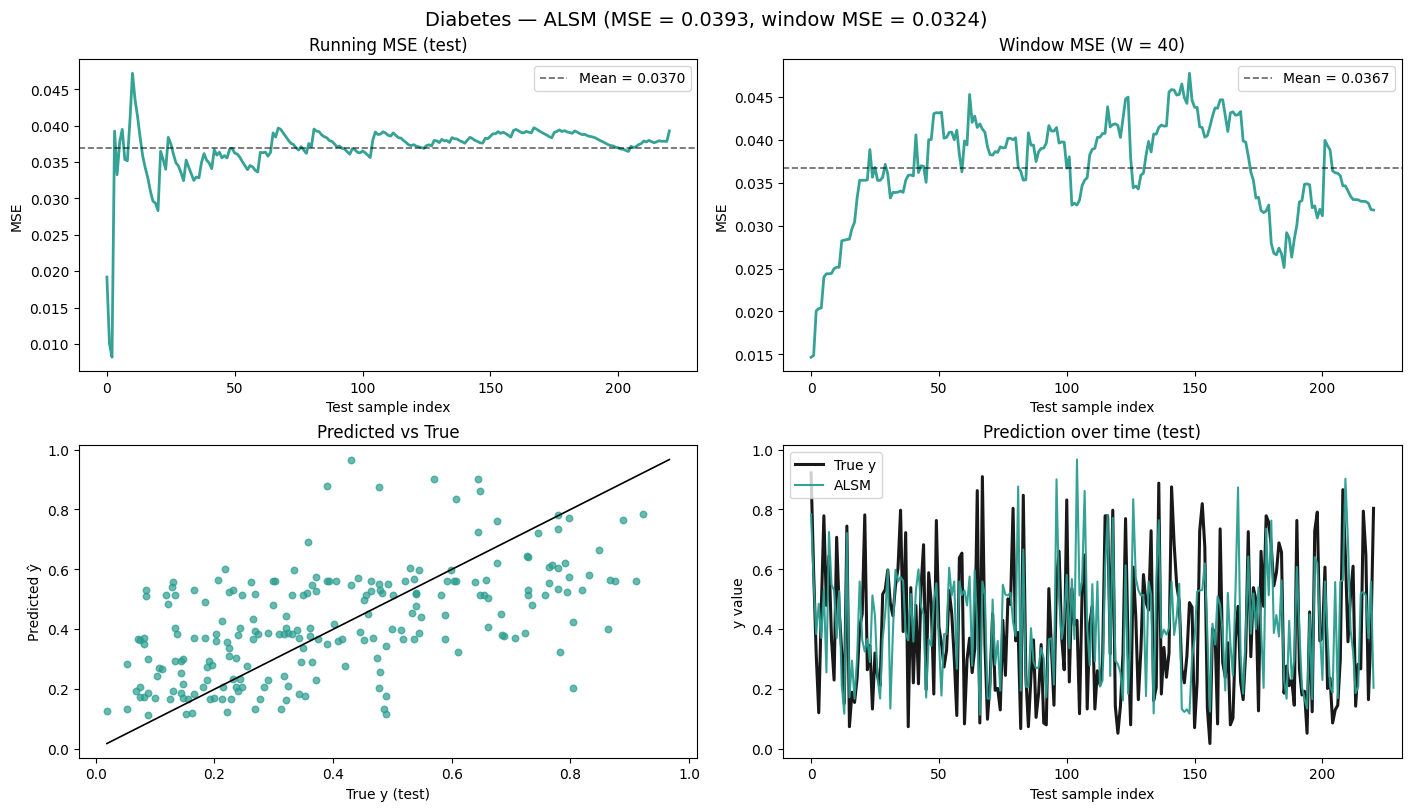

In [ ]:
# =========================
# CELL 7 — ALSM visualization (Diabetes)
# Compact overview (2×2) — aligned with DLSM/RLSM style + MG colors
# Panels:
#   (1) running MSE | (2) window MSE
#   (3) predicted vs true | (4) prediction over time
# =========================
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Colors & style (MUST match MG final plots / CELL 13)
# -------------------------
model_color = {
    "DLSM":  "#7A5195",  # muted purple
    "RLSM":  "#2F5597",  # darker blue
    "ALSM":  "#2A9D8F",  # muted teal
    "e-LSM": "#2E7D32",  # darker green
}
TRUE_COLOR = "black"
ALSM_COLOR = model_color["ALSM"]

LW_RUNMSE = 2.0
LW_PRED   = 1.5
LW_TRUE   = 2.2

# -------------------------
# Error metrics (same spirit as MG)
# -------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W):
    e2 = (y_true - y_pred) ** 2
    # moving-average window MSE (centered, same as your DLSM Diabetes cell)
    return np.convolve(e2, np.ones(W) / W, mode="same")

# -------------------------
# Prepare data
# -------------------------
y_test_a = np.asarray(y_test, float).ravel()
yhat_a   = np.asarray(yhat_test_alsm, float).ravel()

mse_curve = running_mse(y_test_a, yhat_a)

# Rounded, safe window size (human-friendly)
W = 40 if len(y_test_a) >= 40 else max(5, len(y_test_a) // 4)
wmse_curve = window_mse(y_test_a, yhat_a, W=W)

mse_final  = float(np.mean((y_test_a - yhat_a) ** 2))
wmse_final = float(np.mean(wmse_curve[-W:])) if len(wmse_curve) >= W else float(np.mean(wmse_curve))

t = np.arange(len(y_test_a))

# Mean lines
mse_mean  = float(np.mean(mse_curve))
wmse_mean = float(np.mean(wmse_curve))

# ---------------------------------------------------------
# FIGURE — 2 × 2 layout (same width feel as your DLSM cell)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# (1) Running MSE
axes[0, 0].plot(mse_curve, color=ALSM_COLOR, linewidth=LW_RUNMSE, alpha=0.95)
axes[0, 0].axhline(
    mse_mean,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.6,
    label=f"Mean = {mse_mean:.4f}"
)
axes[0, 0].set_title("Running MSE (test)")
axes[0, 0].set_xlabel("Test sample index")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend()

# (2) Window MSE
axes[0, 1].plot(wmse_curve, color=ALSM_COLOR, linewidth=LW_RUNMSE, alpha=0.95)
axes[0, 1].axhline(
    wmse_mean,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.6,
    label=f"Mean = {wmse_mean:.4f}"
)
axes[0, 1].set_title(f"Window MSE (W = {W})")
axes[0, 1].set_xlabel("Test sample index")
axes[0, 1].set_ylabel("MSE")
axes[0, 1].legend()

# (3) Predicted vs True
axes[1, 0].scatter(
    y_test_a, yhat_a,
    s=22,
    alpha=0.7,
    color=ALSM_COLOR
)
mn = float(min(y_test_a.min(), yhat_a.min()))
mx = float(max(y_test_a.max(), yhat_a.max()))
axes[1, 0].plot([mn, mx], [mn, mx], color="black", linewidth=1.2)
axes[1, 0].set_xlabel("True y (test)")
axes[1, 0].set_ylabel("Predicted ŷ")
axes[1, 0].set_title("Predicted vs True")

# (4) Prediction over time
axes[1, 1].plot(
    t, y_test_a,
    label="True y",
    color=TRUE_COLOR,
    linewidth=LW_TRUE,
    alpha=0.9
)
axes[1, 1].plot(
    t, yhat_a,
    label="ALSM",
    color=ALSM_COLOR,
    linewidth=LW_PRED,
    alpha=0.95
)
axes[1, 1].set_xlabel("Test sample index")
axes[1, 1].set_ylabel("y value")
axes[1, 1].set_title("Prediction over time (test)")
axes[1, 1].legend()

fig.suptitle(
    f"Diabetes — ALSM (MSE = {mse_final:.4f}, window MSE = {wmse_final:.4f})",
    fontsize=14
)

plt.show()

**e-LSM (Evolving Level-Set Model)**  

In [ ]:
# =========================
# CELL 8 — e-LSM (controlled e-RLSM) — Diabetes
# Output: MSE + runtime + store diagnostics for later comparison
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
N_INIT_RULES   = 12
SIGMA_SCALE    = 1.00

TAU_CREATE     = 0.03
TAU_ERR_GATE   = 1.01
E_CREATE       = 0.50

SIGMA_MIN      = 0.18
SIGMA_MAX      = 0.60

ALPHA          = 1e4
LAMBDA         = 1.0

BETA           = 0.98
ETA            = 0.25

MERGE_DIST     = 0.25
CLIP_YHAT      = False

EPS            = 1e-12
SEED           = 0
# --------------------------------------------

def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if abs(s) > eps else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_tau_mean(x, c, s):
    z = (x - c) / np.maximum(s, EPS)
    return float(np.exp(-0.5 * np.mean(z * z)))

def kmeans_init_rules(Xtr, n_rules, sigma_scale=1.0, seed=0):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(Xtr)
    centers = km.cluster_centers_
    labels = km.labels_

    global_std = Xtr.std(axis=0) + 1e-3
    sigmas = np.zeros_like(centers)
    for i in range(n_rules):
        Xi = Xtr[labels == i]
        sigmas[i] = (Xi.std(axis=0) + 1e-3) if Xi.shape[0] >= 5 else global_std
    sigmas = np.clip(sigmas * float(sigma_scale), SIGMA_MIN, SIGMA_MAX)
    return centers, sigmas

def dlsm_fit(X, y, centers, sigmas):
    D = []
    for x in X:
        tau = np.array([gaussian_tau_mean(x, centers[i], sigmas[i])
                        for i in range(centers.shape[0])])
        D.append(build_d_from_tau(tau))
    D = np.vstack(D)
    u, *_ = np.linalg.lstsq(D, y, rcond=1e-12)
    return u

class EvolvingRules:
    def __init__(self, centers=None, sigmas=None):
        self.c, self.s, self.n, self.r = [], [], [], []
        if centers is not None:
            for i in range(centers.shape[0]):
                self.c.append(centers[i].copy())
                self.s.append(sigmas[i].copy())
                self.n.append(1)
                self.r.append(1.0)

    def num_rules(self):
        return len(self.c)

    def raw_tau(self, x):
        if self.num_rules() == 0:
            return np.array([])
        return np.array([gaussian_tau_mean(x, self.c[i], self.s[i])
                         for i in range(self.num_rules())], float)

    def effective_tau(self, x):
        if self.num_rules() == 0:
            return np.array([])
        return self.raw_tau(x) * np.array(self.r, float)

    def winner_raw(self, x):
        if self.num_rules() == 0:
            return None, 0.0
        tau = self.raw_tau(x)
        i = int(np.argmax(tau))
        return i, float(tau[i])

    def add_rule(self, x):
        p = x.size
        self.c.append(x.copy())
        self.s.append(np.full(p, SIGMA_MIN))
        self.n.append(1)
        self.r.append(1.0)

    def update_rule(self, i, x):
        ni = self.n[i]
        ci = self.c[i]
        ci_new = ci + (x - ci) / (ni + 1)

        si = self.s[i]
        diff1 = x - ci
        diff2 = x - ci_new
        var = (si**2 * ni + diff1 * diff2) / (ni + 1)
        si_new = np.sqrt(np.maximum(var, SIGMA_MIN**2))
        si_new = np.minimum(si_new, SIGMA_MAX)

        self.c[i], self.s[i], self.n[i] = ci_new, si_new, ni + 1

    def update_reliability(self, i, e):
        self.r[i] = BETA * self.r[i] + (1 - BETA) * np.exp(-(e*e) / (2*ETA*ETA))

    def merge_events(self):
        if MERGE_DIST is None or MERGE_DIST <= 0 or self.num_rules() < 2:
            return []
        events = []
        changed = True
        while changed and self.num_rules() >= 2:
            changed = False
            N = self.num_rules()
            best_d, best = np.inf, None
            for i in range(N):
                for j in range(i+1, N):
                    d = np.linalg.norm(self.c[i] - self.c[j])
                    if d < best_d:
                        best_d, best = d, (i, j)
            if best is None or best_d >= MERGE_DIST:
                break
            i, j = best
            ni, nj = self.n[i], self.n[j]
            w = ni + nj

            self.c[i] = (ni*self.c[i] + nj*self.c[j]) / w
            self.s[i] = np.minimum(np.maximum((ni*self.s[i] + nj*self.s[j]) / w,
                                              SIGMA_MIN), SIGMA_MAX)
            self.n[i] = w
            self.r[i] = max(self.r[i], self.r[j])

            for arr in (self.c, self.s, self.n, self.r):
                del arr[j]

            events.append((i, j, ni, nj))
            changed = True
        return events

class eRLSM:
    def __init__(self, rules: EvolvingRules, u_init):
        self.rules = rules
        self.u = u_init.astype(float).copy()
        self.P = ALPHA * np.eye(self.u.size, dtype=float)

    def _ensure_dims(self):
        if self.u.size != 2 * self.rules.num_rules():
            raise RuntimeError("Dimension mismatch")

    def expand_params_for_new_rule(self, init_w):
        old = self.u.size
        u_new = np.zeros((old + 2,), float)
        u_new[:old] = self.u
        u_new[-1] = float(init_w)
        self.u = u_new

        P_new = np.zeros((old + 2, old + 2), float)
        P_new[:old, :old] = self.P
        P_new[old:, old:] = ALPHA * np.eye(2)
        self.P = P_new

    def apply_merge_event(self, i_keep, j_remove, n_keep_before, n_remove_before):
        ik = 2 * i_keep
        jk = 2 * j_remove
        w = n_keep_before + n_remove_before

        self.u[ik]   = (n_keep_before*self.u[ik]   + n_remove_before*self.u[jk])   / w
        self.u[ik+1] = (n_keep_before*self.u[ik+1] + n_remove_before*self.u[jk+1]) / w

        self.u = np.delete(self.u, [jk, jk+1])
        self.P = np.delete(np.delete(self.P, [jk, jk+1], axis=0), [jk, jk+1], axis=1)

    def step(self, x, y):
        x = np.asarray(x, float).ravel()
        y = float(y)

        i_win, tau_max = self.rules.winner_raw(x)
        if i_win is None:
            tau_max = 0.0

        yhat_unclipped = float(build_d_from_tau(self.rules.effective_tau(x)) @ self.u)
        e_create = y - yhat_unclipped

        create = (tau_max < TAU_CREATE) or ((abs(e_create) > E_CREATE) and (tau_max < TAU_ERR_GATE))
        if create:
            self.rules.add_rule(x)
            self.expand_params_for_new_rule(init_w=y)
            i_win = self.rules.num_rules() - 1

        self._ensure_dims()

        yhat_out = float(np.clip(yhat_unclipped, 0.0, 1.0)) if CLIP_YHAT else yhat_unclipped
        e = y - yhat_out

        d = build_d_from_tau(self.rules.effective_tau(x))
        Pd = self.P @ d
        denom = LAMBDA + float(d @ Pd)
        denom = denom if abs(denom) > EPS else EPS

        self.P = (1.0 / LAMBDA) * (self.P - (1.0 / denom) * np.outer(Pd, Pd))
        self.u = self.u + (self.P @ d) * e

        if i_win is None:
            i_win = int(np.argmax(self.rules.raw_tau(x)))
        self.rules.update_rule(i_win, x)
        self.rules.update_reliability(i_win, e)

        for (ik, jr, nk, nr) in self.rules.merge_events():
            self.apply_merge_event(ik, jr, nk, nr)

        self._ensure_dims()
        return yhat_out

# -------------------------
# Run e-LSM — Diabetes
# -------------------------
t0 = time.perf_counter()

centers0, sigmas0 = kmeans_init_rules(X_train, N_INIT_RULES, SIGMA_SCALE, SEED)
u0 = dlsm_fit(X_train, y_train, centers0, sigmas0)
rules0 = EvolvingRules(centers0, sigmas0)
elsm = eRLSM(rules0, u_init=u0)

rule_counts_elsm = []

for x, yy in zip(X_train, y_train):
    elsm.step(x, yy)
    rule_counts_elsm.append(elsm.rules.num_rules())

yhat_test_elsm = np.zeros_like(y_test, dtype=float)
for k, (x, yy) in enumerate(zip(X_test, y_test)):
    yhat_test_elsm[k] = elsm.step(x, yy)
    rule_counts_elsm.append(elsm.rules.num_rules())

mse_test_elsm = float(np.mean((y_test - yhat_test_elsm) ** 2))
t1 = time.perf_counter()

elsm_time_s = float(t1 - t0)
elsm_ms_per_sample = 1000.0 * elsm_time_s / len(y_test)

rule_counts_elsm = np.asarray(rule_counts_elsm, int)
created_during_test = int(rule_counts_elsm[-1] - rule_counts_elsm[len(X_train) - 1])

print(f"e-LSM — Final #rules: {elsm.rules.num_rules()}")
print(f"MSE (test): {mse_test_elsm:.6f}")
print(f"Runtime (s): {elsm_time_s:.4f}")
print(f"ms/sample: {elsm_ms_per_sample:.3f}")
print(f"Created rules during TEST: {created_during_test}")

e-LSM — Final #rules: 23
MSE (test): 0.036016
Runtime (s): 0.8026
ms/sample: 3.632
Created rules during TEST: 2


**e-LSM: Plots**  

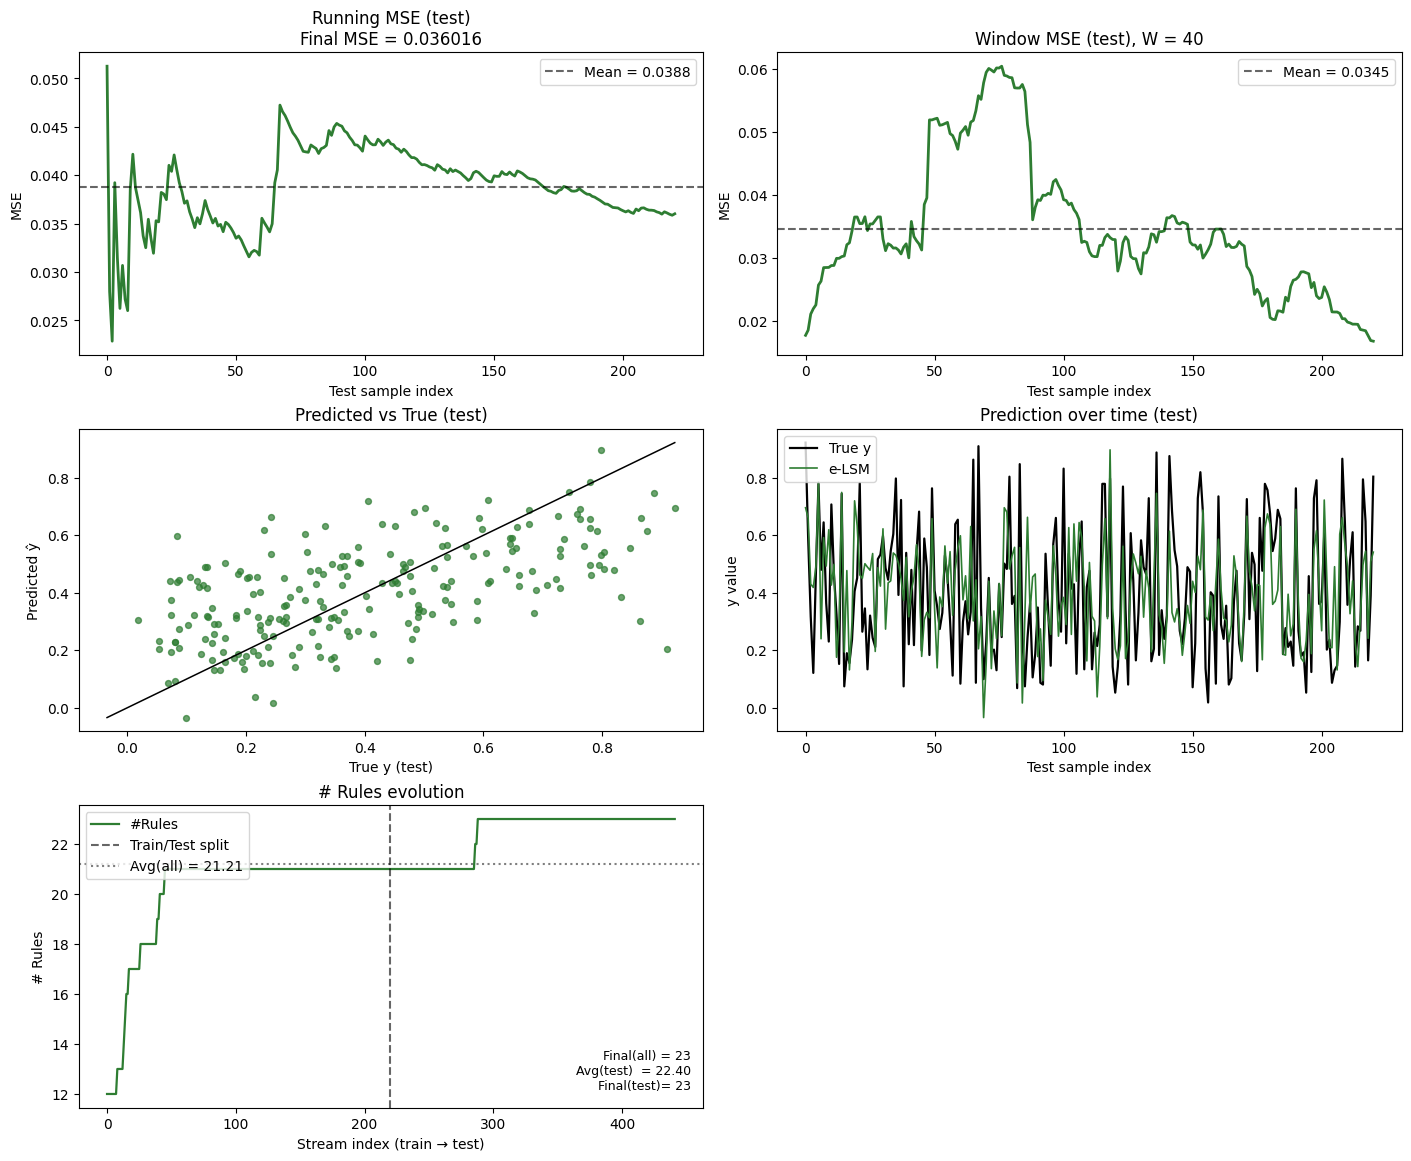

In [ ]:
# =========================
# CELL 9 — e-LSM (e-RLSM) plots (3×2)
# Layout:
#   (1) running MSE (test)            | (2) window MSE (test)
#   (3) predicted vs true             | (4) prediction over time (test)
#   (5) #rules over time (train+test) | (6) empty (reserved / off)
# Notes:
#   - Plot (5) uses train+test x-axis with a vertical split line.
#   - Avg/final #rules are reported for BOTH: (train+test) and (test-only).
# =========================
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Metrics
# -------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W):
    e2 = (y_true - y_pred) ** 2
    return np.convolve(e2, np.ones(W) / W, mode="same")

# -------------------------
# Prepare data
# -------------------------
y_true = np.asarray(y_test, float).ravel()
y_hat  = np.asarray(yhat_test_elsm, float).ravel()

rmse_curve = running_mse(y_true, y_hat)

W = 40 if len(y_true) >= 40 else max(5, len(y_true) // 4)
wmse_curve = window_mse(y_true, y_hat, W=W)

mse_final = float(np.mean((y_true - y_hat) ** 2))
rmse_mean = float(np.mean(rmse_curve))
wmse_mean = float(np.mean(wmse_curve))

t_test = np.arange(len(y_true))

# Rule counts (train + test)
split_idx = len(X_train)
rule_counts_elsm = np.asarray(rule_counts_elsm, int)
t_all = np.arange(len(rule_counts_elsm))

end_test = min(split_idx + len(y_true), len(rule_counts_elsm))
rules_test = rule_counts_elsm[split_idx:end_test] if end_test > split_idx else np.array([], int)

avg_rules_all   = float(np.mean(rule_counts_elsm))
final_rules_all = int(rule_counts_elsm[-1])

avg_rules_test   = float(np.mean(rules_test)) if len(rules_test) else np.nan
final_rules_test = int(rules_test[-1]) if len(rules_test) else final_rules_all

# -------------------------
# Style
# -------------------------
COLOR = "#2E7D32"
TRUE_COLOR = "black"

# -------------------------
# FIGURE — 3×2 (taller, scrollable)
# -------------------------
fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 11.5),   # <<< taller on purpose; scrolling is OK
    constrained_layout=True
)

# (1) Running MSE
ax = axes[0, 0]
ax.plot(rmse_curve, color=COLOR, linewidth=2.0)
ax.axhline(rmse_mean, linestyle="--", color="black", alpha=0.6,
           label=f"Mean = {rmse_mean:.4f}")
ax.set_title(f"Running MSE (test)\nFinal MSE = {mse_final:.6f}")
ax.set_xlabel("Test sample index")
ax.set_ylabel("MSE")
ax.legend()

# (2) Window MSE
ax = axes[0, 1]
ax.plot(wmse_curve, color=COLOR, linewidth=2.0)
ax.axhline(wmse_mean, linestyle="--", color="black", alpha=0.6,
           label=f"Mean = {wmse_mean:.4f}")
ax.set_title(f"Window MSE (test), W = {W}")
ax.set_xlabel("Test sample index")
ax.set_ylabel("MSE")
ax.legend()

# (3) Predicted vs True
ax = axes[1, 0]
ax.scatter(y_true, y_hat, s=18, alpha=0.7, color=COLOR)
mn = min(y_true.min(), y_hat.min())
mx = max(y_true.max(), y_hat.max())
ax.plot([mn, mx], [mn, mx], color="black", linewidth=1.1)
ax.set_xlabel("True y (test)")
ax.set_ylabel("Predicted ŷ")
ax.set_title("Predicted vs True (test)")

# (4) Prediction over time
ax = axes[1, 1]
ax.plot(t_test, y_true, label="True y", color=TRUE_COLOR, linewidth=1.6)
ax.plot(t_test, y_hat, label="e-LSM", color=COLOR, linewidth=1.2)
ax.set_xlabel("Test sample index")
ax.set_ylabel("y value")
ax.set_title("Prediction over time (test)")
ax.legend()

# (5) #Rules evolution (train + test)
ax = axes[2, 0]
ax.plot(t_all, rule_counts_elsm, color=COLOR, linewidth=1.6, label="#Rules")
ax.axvline(split_idx - 1, linestyle="--", color="black", alpha=0.6,
           label="Train/Test split")
ax.axhline(avg_rules_all, linestyle=":", color="black", alpha=0.5,
           label=f"Avg(all) = {avg_rules_all:.2f}")

ax.text(
    0.98, 0.05,
    f"Final(all) = {final_rules_all}\n"
    f"Avg(test)  = {avg_rules_test:.2f}\n"
    f"Final(test)= {final_rules_test}",
    transform=ax.transAxes,
    ha="right", va="bottom", fontsize=9
)

ax.set_xlabel("Stream index (train → test)")
ax.set_ylabel("# Rules")
ax.set_title("# Rules evolution")
ax.legend(loc="upper left")

# (6) Empty (reserved)
axes[2, 1].axis("off")

plt.show()

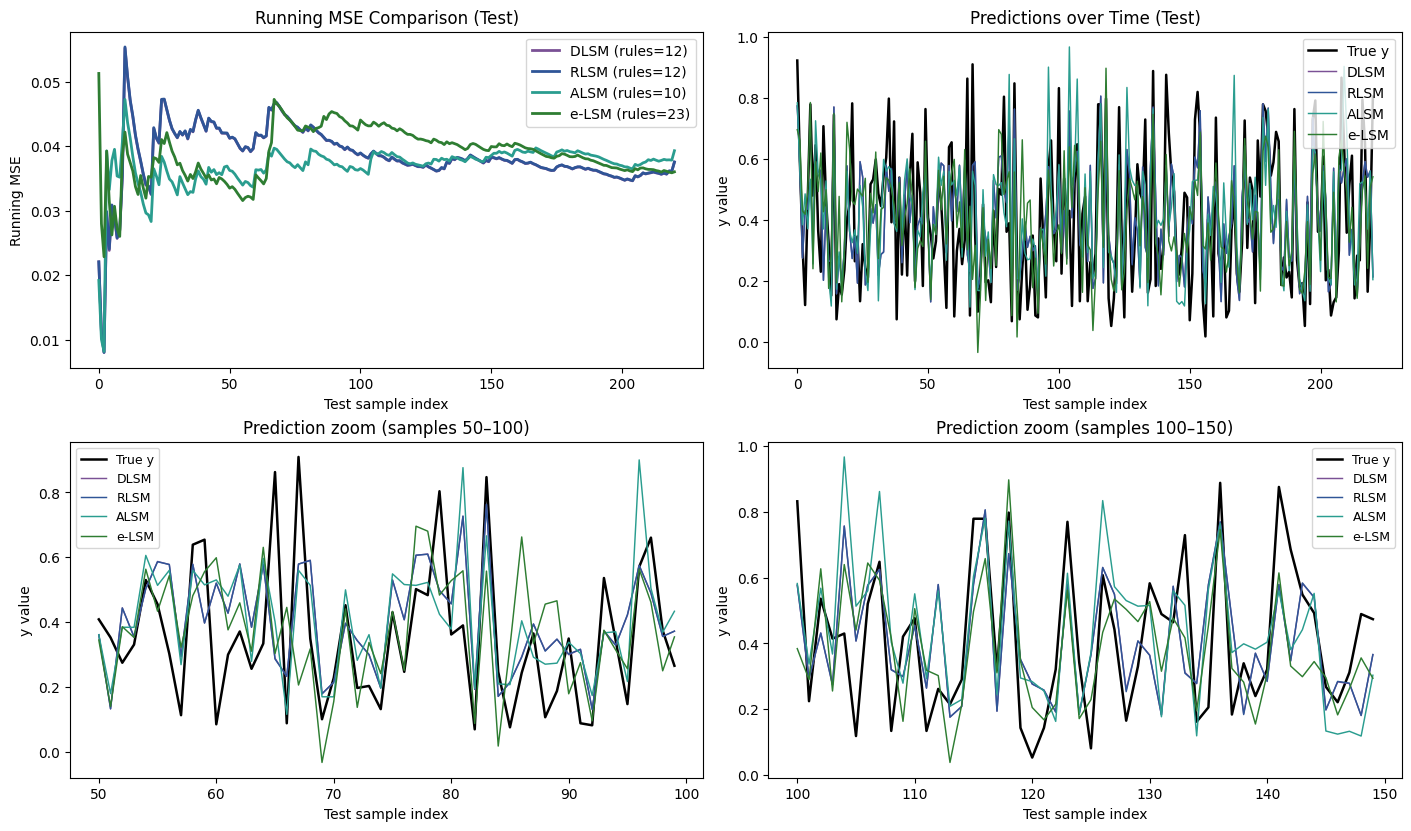


Comparative performance on TEST set:
---------------------------------------------------------------------------------------------------------
Model      #Rules   MSE          RMSE         MAE          R2       Runtime(s)   ms/sample 
---------------------------------------------------------------------------------------------------------
DLSM       12       0.037514     0.193686     0.153778     0.2933   0.1821       0.824     
RLSM       12       0.037548     0.193774     0.153800     0.2926   0.1318       0.596     
ALSM       10       0.039287     0.198210     0.157660     0.2599   0.1191       0.539     
e-LSM      23       0.036016     0.189780     0.150669     0.3215   0.8026       3.632     
---------------------------------------------------------------------------------------------------------


In [ ]:
# =========================
# CELL 10 — Comparative plots + table (Diabetes)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------
# Styling
# -------------------------
model_color = {
    "DLSM":  "#7A5195",  # muted purple
    "RLSM":  "#2F5597",  # darker blue
    "ALSM":  "#2A9D8F",  # muted teal
    "e-LSM": "#2E7D32",  # darker green
}
TRUE_COLOR = "black"
LW_TRUE    = 1.8
LW_PRED    = 1.05
LW_RUNMSE  = 2.0

def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

# -------------------------
# Ensure 1D float arrays
# -------------------------
y_true = np.asarray(y_test, float).ravel()
y_dlsm = np.asarray(yhat_test_dlsm, float).ravel()
y_rlsm = np.asarray(yhat_test_rlsm, float).ravel()
y_alsm = np.asarray(yhat_test_alsm, float).ravel()

# e-LSM may or may not exist yet (depending on execution order)
if "yhat_test_elsm" in globals():
    y_elsm = np.asarray(yhat_test_elsm, float).ravel()
else:
    y_elsm = None

t = np.arange(len(y_true))

# -------------------------
# Robust rule counting
# -------------------------
def get_n_rules(default_n):
    out = {}

    if "centers_dlsm" in globals():
        try:
            out["DLSM"] = int(np.asarray(centers_dlsm).shape[0])
        except Exception:
            out["DLSM"] = int(default_n)
    else:
        out["DLSM"] = int(default_n)

    if "centers_rlsm" in globals():
        try:
            out["RLSM"] = int(np.asarray(centers_rlsm).shape[0])
        except Exception:
            out["RLSM"] = int(default_n)
    else:
        out["RLSM"] = int(default_n)

    if "centers_alsm" in globals():
        try:
            out["ALSM"] = int(np.asarray(centers_alsm).shape[0])
        except Exception:
            out["ALSM"] = int(default_n)
    else:
        out["ALSM"] = int(default_n)

    # e-LSM: number of final evolving rules if model exists; otherwise try rule_counts_elsm
    if "model" in globals() and hasattr(globals()["model"], "rules") and hasattr(globals()["model"].rules, "num_rules"):
        try:
            out["e-LSM"] = int(globals()["model"].rules.num_rules())
        except Exception:
            out["e-LSM"] = int(default_n)
    elif "rule_counts_elsm" in globals():
        try:
            out["e-LSM"] = int(np.asarray(rule_counts_elsm, int)[-1])
        except Exception:
            out["e-LSM"] = int(default_n)
    else:
        out["e-LSM"] = int(default_n)

    return out

n_rules_default = int(globals().get("N_RULES", 0)) if "N_RULES" in globals() else 0
n_rules = get_n_rules(n_rules_default)

# -------------------------
# Runtime fetch
# -------------------------
def get_time_pair(prefix, n_samples):
    t_s = None
    msps = None

    for k in [f"time_{prefix}_s", f"runtime_{prefix}", f"{prefix}_runtime", f"{prefix}_time_s"]:
        if k in globals():
            try:
                t_s = float(globals()[k])
                break
            except Exception:
                pass

    for k in [f"time_{prefix}_msps", f"{prefix}_msps", f"{prefix}_time_msps"]:
        if k in globals():
            try:
                msps = float(globals()[k])
                break
            except Exception:
                pass

    if (msps is None) and (t_s is not None) and (n_samples > 0):
        msps = 1000.0 * t_s / n_samples

    return float(t_s) if t_s is not None else np.nan, \
           float(msps) if msps is not None else np.nan

time_dlsm_s_, time_dlsm_msps_ = get_time_pair("dlsm", len(y_true))
time_rlsm_s_, time_rlsm_msps_ = get_time_pair("rlsm", len(y_true))
time_alsm_s_, time_alsm_msps_ = get_time_pair("alsm", len(y_true))
time_elsm_s_, time_elsm_msps_ = get_time_pair("elsm", len(y_true))  # expects you stored time_elsm_s etc.

# -------------------------
# Curves
# -------------------------
rmse_dlsm = running_mse(y_true, y_dlsm)
rmse_rlsm = running_mse(y_true, y_rlsm)
rmse_alsm = running_mse(y_true, y_alsm)
rmse_elsm = running_mse(y_true, y_elsm) if y_elsm is not None else None

# -------------------------
# Plots (2×2) — clean, fits screen
#   Row 1: running MSE | full prediction
#   Row 2: zoom 50–100 | zoom 100–150
# -------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8.2),
    constrained_layout=True
)

# (1) Running MSE comparison
axes[0, 0].plot(rmse_dlsm, label=f"DLSM (rules={n_rules['DLSM']})",
                color=model_color["DLSM"], linewidth=LW_RUNMSE)
axes[0, 0].plot(rmse_rlsm, label=f"RLSM (rules={n_rules['RLSM']})",
                color=model_color["RLSM"], linewidth=LW_RUNMSE)
axes[0, 0].plot(rmse_alsm, label=f"ALSM (rules={n_rules['ALSM']})",
                color=model_color["ALSM"], linewidth=LW_RUNMSE)
if rmse_elsm is not None:
    axes[0, 0].plot(rmse_elsm, label=f"e-LSM (rules={n_rules['e-LSM']})",
                    color=model_color["e-LSM"], linewidth=LW_RUNMSE)

axes[0, 0].set_xlabel("Test sample index")
axes[0, 0].set_ylabel("Running MSE")
axes[0, 0].set_title("Running MSE Comparison (Test)")
axes[0, 0].legend()

# (2) Predictions over time — full
axes[0, 1].plot(t, y_true, label="True y", color=TRUE_COLOR, linewidth=LW_TRUE)
axes[0, 1].plot(t, y_dlsm, label="DLSM", color=model_color["DLSM"], linewidth=LW_PRED)
axes[0, 1].plot(t, y_rlsm, label="RLSM", color=model_color["RLSM"], linewidth=LW_PRED)
axes[0, 1].plot(t, y_alsm, label="ALSM", color=model_color["ALSM"], linewidth=LW_PRED)
if y_elsm is not None:
    axes[0, 1].plot(t, y_elsm, label="e-LSM", color=model_color["e-LSM"], linewidth=LW_PRED)

axes[0, 1].set_xlabel("Test sample index")
axes[0, 1].set_ylabel("y value")
axes[0, 1].set_title("Predictions over Time (Test)")
axes[0, 1].legend()

# Zoom windows (safe if test shorter)
z1_start, z1_end = 50, min(100, len(t))
z2_start, z2_end = 100, min(150, len(t))

# (3) Zoom 50–100
axes[1, 0].plot(t[z1_start:z1_end], y_true[z1_start:z1_end],
                color=TRUE_COLOR, linewidth=LW_TRUE, label="True y")
axes[1, 0].plot(t[z1_start:z1_end], y_dlsm[z1_start:z1_end],
                color=model_color["DLSM"], linewidth=LW_PRED, label="DLSM")
axes[1, 0].plot(t[z1_start:z1_end], y_rlsm[z1_start:z1_end],
                color=model_color["RLSM"], linewidth=LW_PRED, label="RLSM")
axes[1, 0].plot(t[z1_start:z1_end], y_alsm[z1_start:z1_end],
                color=model_color["ALSM"], linewidth=LW_PRED, label="ALSM")
if y_elsm is not None:
    axes[1, 0].plot(t[z1_start:z1_end], y_elsm[z1_start:z1_end],
                    color=model_color["e-LSM"], linewidth=LW_PRED, label="e-LSM")

axes[1, 0].set_xlabel("Test sample index")
axes[1, 0].set_ylabel("y value")
axes[1, 0].set_title("Prediction zoom (samples 50–100)")
axes[1, 0].legend(fontsize=9)

# (4) Zoom 100–150
axes[1, 1].plot(t[z2_start:z2_end], y_true[z2_start:z2_end],
                color=TRUE_COLOR, linewidth=LW_TRUE, label="True y")
axes[1, 1].plot(t[z2_start:z2_end], y_dlsm[z2_start:z2_end],
                color=model_color["DLSM"], linewidth=LW_PRED, label="DLSM")
axes[1, 1].plot(t[z2_start:z2_end], y_rlsm[z2_start:z2_end],
                color=model_color["RLSM"], linewidth=LW_PRED, label="RLSM")
axes[1, 1].plot(t[z2_start:z2_end], y_alsm[z2_start:z2_end],
                color=model_color["ALSM"], linewidth=LW_PRED, label="ALSM")
if y_elsm is not None:
    axes[1, 1].plot(t[z2_start:z2_end], y_elsm[z2_start:z2_end],
                    color=model_color["e-LSM"], linewidth=LW_PRED, label="e-LSM")

axes[1, 1].set_xlabel("Test sample index")
axes[1, 1].set_ylabel("y value")
axes[1, 1].set_title("Prediction zoom (samples 100–150)")
axes[1, 1].legend(fontsize=9)

plt.show()

# =========================
# Comparative table (REGRESSION metrics)
# =========================
def summarize_model(name, y_true, y_pred, n_rules, runtime_s, msps):
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        "Model": name,
        "# Rules": int(n_rules),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Runtime (s)": float(runtime_s),
        "ms/sample": float(msps),
    }

table = [
    summarize_model("DLSM", y_true, y_dlsm, n_rules["DLSM"], time_dlsm_s_, time_dlsm_msps_),
    summarize_model("RLSM", y_true, y_rlsm, n_rules["RLSM"], time_rlsm_s_, time_rlsm_msps_),
    summarize_model("ALSM", y_true, y_alsm, n_rules["ALSM"], time_alsm_s_, time_alsm_msps_),
]

if y_elsm is not None:
    table.append(
        summarize_model("e-LSM", y_true, y_elsm, n_rules["e-LSM"], time_elsm_s_, time_elsm_msps_)
    )

print("\nComparative performance on TEST set:")
print("-" * 105)
print(f"{'Model':<10} {'#Rules':<8} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'R2':<8} {'Runtime(s)':<12} {'ms/sample':<10}")
print("-" * 105)
for row in table:
    rt = row["Runtime (s)"]
    ms = row["ms/sample"]
    rt_str = f"{rt:.4f}" if np.isfinite(rt) else "NA"
    ms_str = f"{ms:.3f}" if np.isfinite(ms) else "NA"
    print(
        f"{row['Model']:<10} "
        f"{row['# Rules']:<8d} "
        f"{row['MSE']:<12.6f} "
        f"{row['RMSE']:<12.6f} "
        f"{row['MAE']:<12.6f} "
        f"{row['R2']:<8.4f} "
        f"{rt_str:<12} "
        f"{ms_str:<10}"
    )
print("-" * 105)

**Table interpretation:**

**No. Rules** → interpretability / model complexity  
↓ lower is better  
(fewer rules = simpler, more interpretable model)

**MSE** → accuracy (quadratic error)  
↓ lower is better  
(penalizes large errors more strongly)

**RMSE** → accuracy (scale-aware)  
↓ lower is better  
(same units as the output variable)

**MAE** → robustness to outliers  
↓ lower is better  
(less sensitive to large deviations than MSE)

**R²** → global explanatory power  
↑ higher is better  
(1 = perfect fit, 0 = baseline predictor)

**Runtime (s)** → total computational cost  
↓ lower is better  
(wall-clock time for training + test evaluation)

**ms/sample** → computational efficiency per data point  
↓ lower is better  
(normalized cost, useful for comparing scalability and online suitability)

**Conclusion (Diabetes experiment)**

On the Diabetes dataset, which does not exhibit clear nonstationary behavior, the proposed e-LSM demonstrates competitive and, in this configuration, superior predictive accuracy compared to batch and recursive non-evolving counterparts. Using a conservative error-driven creation criterion (e-create = 0.50), e-LSM introduced only two additional rules during the test stream, resulting in a compact final model with 24 rules. Despite operating under strict online and single-pass constraints, the model achieved a lower test MSE than fixed-structure DLSM, RLSM, and ALSM.

This behavior indicates that controlled, residual-driven structural refinement can enhance approximation quality even in largely stationary settings, by enabling localized specialization in regions where a fixed rule base remains insufficient. In stationary regimes, e-LSM therefore acts as an adaptive regularization mechanism, trading a modest increase in structural complexity for improved accuracy while preserving online learning and interpretability. These results suggest that the benefits of e-LSM are not limited to nonstationary environments, but also extend to stationary problems where targeted local adaptation is advantageous.

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

# **Experiment 2: Machey-Glass datasets - Load & split data (50/50)**

# Evolving Level-Set Fuzzy Models — Mackey–Glass Benchmark (Long-Horizon Prediction)

**Authors:**  
Daniel Leite — [Google Scholar](https://scholar.google.com/citations?user=mZKDqM8AAAAJ&hl=en)  
Fernando Gomide — [Google Scholar](https://scholar.google.com/citations?user=d33RRg0AAAAJ&hl=en)

**Related work:**  
*Evolving Level-Set Fuzzy Models for Adaptive Regression from Nonstationary Data Streams*  
(ongoing / under preparation)

---

This notebook presents a systematic experimental evaluation of **Level-Set Fuzzy Models (LSM)** and their **evolving extension (e-LSM)** using the **Mackey–Glass (MG) time-delay system** as a controlled benchmark for **nonlinear, nonstationary, long-horizon regression**.

Unlike one-step-ahead prediction tasks, which are relatively easy for the Mackey–Glass system, this study focuses on a **multi-step-ahead forecasting problem** designed to stress both **nonlinear modeling capacity** and **online adaptability under concept drift**.

---

## Mackey–Glass System

The Mackey–Glass system is defined by the delay differential equation:

$$
\dot{x}(t) = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t),
$$

where:
- $\beta$ controls the feedback gain,
- $\tau$ is the time delay,
- $\gamma$ is the decay rate,
- $n$ determines the nonlinearity of the feedback.

For suitable parameter values (e.g., $\tau = 17$), the system exhibits **chaotic dynamics** with long-term dependencies, making it a classical benchmark for nonlinear prediction and adaptive learning.

A discrete-time approximation is employed to generate a scalar time series $x(t)$.

---

## Prediction Task Definition

The regression problem is formulated as a **delay-embedded, multi-step-ahead prediction task**:

$$
[x(t), x(t-1), \ldots, x(t-m+1)] \;\longrightarrow\; x(t+\Delta),
$$

with:
- **Embedding dimension:** $m = 6$  
  (current value and previous 5 samples)
- **Prediction horizon:** $\Delta = 85$

This setup corresponds to the canonical Mackey–Glass benchmark commonly used in the literature to evaluate nonlinear predictors under chaotic dynamics.

Compared to one-step-ahead prediction, this task:
- amplifies modeling errors over long horizons,
- requires capturing longer temporal dependencies,
- is sensitive to structural mismatch and concept drift.

---

## Nonstationary Learning Scenarios

To assess model adaptability, five Mackey–Glass data streams are generated:

1. **MG_stationary**  
   All parameters remain constant over time.

2. **MG_tau_drift**  
   The delay parameter $\tau$ varies smoothly over time (gradual drift).

3. **MG_tau_shift**  
   The delay parameter $\tau$ undergoes abrupt regime changes.

4. **MG_beta_drift**  
   The feedback gain $\beta$ varies smoothly over time.

5. **MG_beta_shift**  
   The feedback gain $\beta$ changes abruptly.

These scenarios induce gradual and abrupt distribution shifts affecting the underlying system dynamics rather than observation noise.

---

## Learning Paradigms Evaluated

The following models are compared:

- **DLSM (Batch Level-Set Model)**  
  Offline least-squares estimation with a fixed rule base.

- **RLSM (Recursive Level-Set Model)**  
  Online recursive least-squares learning with fixed structure.

- **ALSM (Adaptive Level-Set Model)**  
  Correntropy-based recursive learning for improved robustness.

- **e-LSM (Evolving Level-Set Model)**  
  A fully online model that supports **structural adaptation**, including rule creation, reliability-weighted activation, and rule merging.

---

## Evaluation Protocol

- Each data stream is processed in temporal order.
- Training and test segments are split 50/50.
- Recursive and evolving models operate under **single-pass (prequential)** constraints.
- All inputs and targets are **min–max normalized to $[0,1]$** over the full stream.
- Performance is assessed using:
  - Mean Squared Error (MSE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Error (MAE)
  - Coefficient of Determination ($R^2$)
  - Number of fuzzy rules (model complexity)

This experimental design enables a clear analysis of how **structural evolution and online adaptation** affect long-horizon prediction performance under different forms of nonstationarity.

**Generate & split 5 Mackey–Glass datasets (stationary + drifts + shifts, in tau and beta)**

In [ ]:
# =========================
# CELL 1 — Generate & split 5 Mackey–Glass datasets (m=6, DELTA=85) (50/50)
# Drift/shift happens ONLY in the TEST half (t >= split)
#
# For each dataset:
#   X shape = (T_DATA, m)   with X[i] = [x(t), x(t-1), ..., x(t-m+1)]
#   y shape = (T_DATA,)     with y[i] = x(t+DELTA)
# where t = (m-1) + i.
# =========================
import numpy as np

# Reproducibility
SEED = 0
np.random.seed(SEED)

# -----------------------------
# Problem setup (edit here)
# -----------------------------
T_DATA = 2000     # number of supervised samples (X,y)
m = 6             # embedding dimension: current + previous 5
DELTA = 85        # prediction horizon: y = x(t+DELTA)
split = T_DATA // 2  # 50/50 temporal split over supervised samples

# Parameter change schedule (indices refer to the SAME "time axis" as generation)
# IMPORTANT:
# drift/shift must start AFTER the last TRAIN target x[tcur + DELTA]
# last TRAIN i = split-1 -> tcur = (m-1) + (split-1)
# last TRAIN target index = tcur + DELTA
split_t = (m - 1) + (split - 1) + DELTA + 1   # 1090 for m=6, split=1000, DELTA=85

# Change points (kept strictly in the TEST region of the RAW series)
t1, t2 = split_t + 200, split_t + 600         # shift change points (in TEST)
t_peak = split_t + 500                         # drift turning point (in TEST)

# Baselines
tau0 = 17.0
beta0 = 0.20

# Drift amplitudes (TEST-only)
# tau drift: 17 -> 20 -> 14
tau_peak = 20.0
tau_end  = 14.0

# beta drift: 0.20 -> 0.14 -> 0.26
beta_min = 0.14
beta_end = 0.26

# Shift levels (TEST-only)
# tau shift: 17 -> 14 -> 20
tau_shift_mid = 14.0
tau_shift_end = 20.0

# beta shift: 0.20 -> 0.26 -> 0.14
beta_shift_mid = 0.26
beta_shift_end = 0.14

# Mackey–Glass fixed parameters
GAMMA = 0.1
N_EXP = 10

# -----------------------------
# How long the raw series must be
# Required x length for supervised construction:
# need_len = T_DATA + DELTA + (m - 1)
# -----------------------------
T_GEN = T_DATA + DELTA + (m - 1)  # 2000 + 85 + 5 = 2090

# -----------------------------
# Mackey–Glass generator (discrete-time approximation)
# x[t+1] = x[t] + beta[t]*x[t-tau]/(1+x[t-tau]^n) - gamma*x[t]
# -----------------------------
def generate_mg_series(T, beta, tau, gamma=0.1, n=10):
    beta = np.asarray(beta, dtype=float).ravel()
    tau  = np.asarray(tau,  dtype=float).ravel()
    assert beta.shape == (T,)
    assert tau.shape  == (T,)

    max_delay = int(np.max(tau)) + 1
    x = np.zeros(T + max_delay, dtype=float)
    x[:max_delay] = 1.2  # initial history

    for tt in range(max_delay, T + max_delay - 1):
        d = int(round(tau[tt - max_delay]))
        x_tau = x[tt - d]
        x[tt + 1] = x[tt] + (
            beta[tt - max_delay] * x_tau / (1.0 + x_tau**n)
            - gamma * x[tt]
        )

    return x[max_delay:]  # length T


# -----------------------------
# Parameter profiles (length T_GEN)
# Drift/shift ONLY for indices >= split_t
# -----------------------------
def tau_profiles(T):
    t = np.arange(T)

    # Constant
    tau_const = np.full(T, tau0, dtype=float)

    # Drift (TEST-only): tau0 -> tau_peak -> tau_end
    tau_drift = np.full(T, tau0, dtype=float)

    # up segment [split_t .. t_peak]
    if t_peak > split_t:
        tau_drift[split_t:t_peak+1] = tau0 + (tau_peak - tau0) * (
            (t[split_t:t_peak+1] - split_t) / (t_peak - split_t)
        )
    else:
        tau_drift[split_t:t_peak+1] = tau_peak

    # down segment [t_peak+1 .. T-1]
    denom = (T - (t_peak + 1) - 1)
    if denom > 0:
        tau_drift[t_peak+1:] = tau_peak + (tau_end - tau_peak) * (
            (t[t_peak+1:] - (t_peak+1)) / denom
        )
    else:
        tau_drift[t_peak+1:] = tau_end

    # Shift (TEST-only): tau0 -> tau_shift_mid -> tau_shift_end
    tau_shift = np.full(T, tau0, dtype=float)
    tau_shift[t1:t2] = tau_shift_mid
    tau_shift[t2:]   = tau_shift_end

    return tau_const, tau_drift, tau_shift


def beta_profiles(T):
    t = np.arange(T)

    # Constant
    beta_const = np.full(T, beta0, dtype=float)

    # Drift (TEST-only): beta0 -> beta_min -> beta_end
    beta_drift = np.full(T, beta0, dtype=float)

    # down segment [split_t .. t_peak]
    if t_peak > split_t:
        beta_drift[split_t:t_peak+1] = beta0 + (beta_min - beta0) * (
            (t[split_t:t_peak+1] - split_t) / (t_peak - split_t)
        )
    else:
        beta_drift[split_t:t_peak+1] = beta_min

    # up segment [t_peak+1 .. T-1]
    denom = (T - (t_peak + 1) - 1)
    if denom > 0:
        beta_drift[t_peak+1:] = beta_min + (beta_end - beta_min) * (
            (t[t_peak+1:] - (t_peak+1)) / denom
        )
    else:
        beta_drift[t_peak+1:] = beta_end

    # Shift (TEST-only): beta0 -> beta_shift_mid -> beta_shift_end
    beta_shift = np.full(T, beta0, dtype=float)
    beta_shift[t1:t2] = beta_shift_mid
    beta_shift[t2:]   = beta_shift_end

    return beta_const, beta_drift, beta_shift


# -----------------------------
# Build supervised dataset (m=6, DELTA=85) with EXACTLY T_DATA samples
# X[i] = [x(t), x(t-1), ..., x(t-m+1)]  where t=(m-1)+i
# y[i] = x(t+DELTA)
# -----------------------------
def make_mg_supervised(x, T_data, m=6, delta=85):
    x = np.asarray(x, float).ravel()
    start_t = m - 1
    end_t = start_t + (T_data - 1)
    need_len = (end_t + delta) + 1
    if x.size < need_len:
        raise ValueError(f"Series too short: len(x)={x.size}, need {need_len}")

    X = np.zeros((T_data, m), dtype=float)
    y = np.zeros((T_data,), dtype=float)

    for i in range(T_data):
        tcur = start_t + i
        X[i, :] = x[tcur - np.arange(m)]  # [x(t), x(t-1), ..., x(t-m+1)]
        y[i] = x[tcur + delta]            # x(t+DELTA)

    return X, y


# -----------------------------
# Generate schedules and 5 time series
# -----------------------------
tau_const, tau_drift, tau_shift = tau_profiles(T_GEN)
beta_const, beta_drift, beta_shift = beta_profiles(T_GEN)

series_dict = {
    "MG_stationary": generate_mg_series(T_GEN, beta_const, tau_const, gamma=GAMMA, n=N_EXP),
    "MG_tau_drift":  generate_mg_series(T_GEN, beta_const, tau_drift, gamma=GAMMA, n=N_EXP),
    "MG_tau_shift":  generate_mg_series(T_GEN, beta_const, tau_shift, gamma=GAMMA, n=N_EXP),
    "MG_beta_drift": generate_mg_series(T_GEN, beta_drift, tau_const, gamma=GAMMA, n=N_EXP),
    "MG_beta_shift": generate_mg_series(T_GEN, beta_shift, tau_const, gamma=GAMMA, n=N_EXP),
}

# -----------------------------
# Create X/y and store splits for ALL datasets
# -----------------------------
data_splits = {}  # later cells will use this

for name, x in series_dict.items():
    X, y = make_mg_supervised(x, T_DATA, m=m, delta=DELTA)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    data_splits[name] = (X_train, X_test, y_train, y_test)

    print(f"{name} dataset loaded. (m={m}, DELTA={DELTA})")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape,  "y_test :", y_test.shape)
    print()

MG_stationary dataset loaded. (m=6, DELTA=85)
X_train: (1000, 6) y_train: (1000,)
X_test : (1000, 6) y_test : (1000,)

MG_tau_drift dataset loaded. (m=6, DELTA=85)
X_train: (1000, 6) y_train: (1000,)
X_test : (1000, 6) y_test : (1000,)

MG_tau_shift dataset loaded. (m=6, DELTA=85)
X_train: (1000, 6) y_train: (1000,)
X_test : (1000, 6) y_test : (1000,)

MG_beta_drift dataset loaded. (m=6, DELTA=85)
X_train: (1000, 6) y_train: (1000,)
X_test : (1000, 6) y_test : (1000,)

MG_beta_shift dataset loaded. (m=6, DELTA=85)
X_train: (1000, 6) y_train: (1000,)
X_test : (1000, 6) y_test : (1000,)



**Profiles of the time-varying parameters**

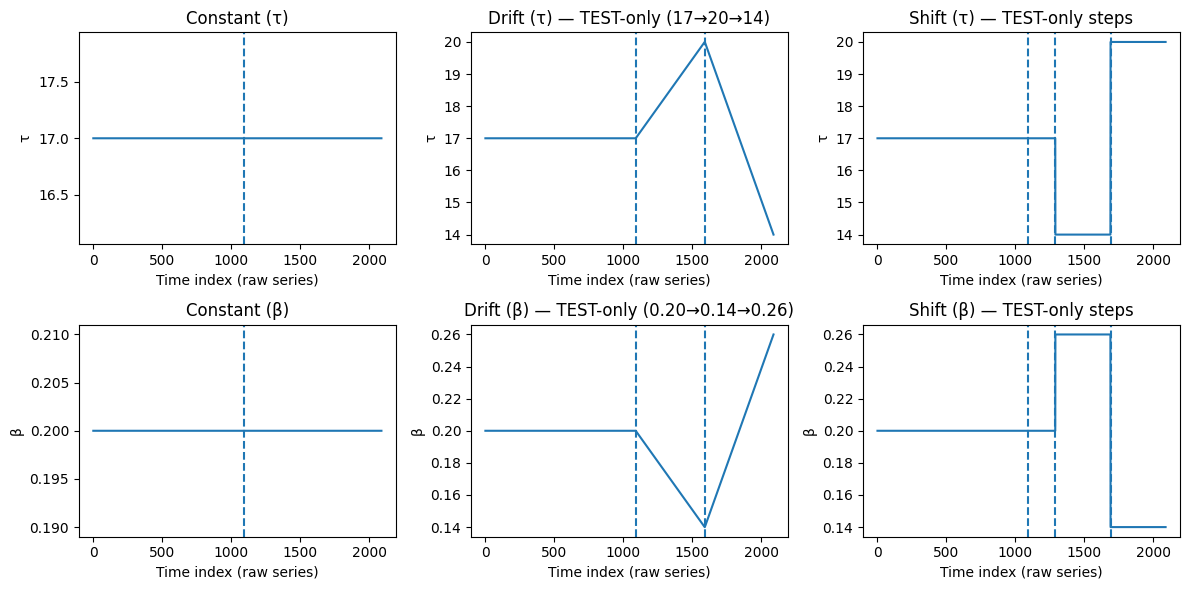

In [ ]:
# =========================
# CELL 2 — Plot MG parameter profiles (2x3)
# Drift/shift happens ONLY in the TEST half (t >= split_t) on the RAW series time axis
# tau drift: 17 -> 20 -> 14 (TEST-only, continuous)
# beta drift: 0.20 -> 0.14 -> 0.26 (TEST-only, continuous)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Match CELL 1 settings
T_DATA = 2000
m = 6
DELTA = 85
split = T_DATA // 2

# Raw-series length used in generation
T_GEN = T_DATA + DELTA + (m - 1)  # 2090

t = np.arange(T_GEN)

# IMPORTANT: drift/shift starts AFTER last TRAIN target x[tcur + DELTA]
split_t = (m - 1) + (split - 1) + DELTA + 1   # 1090

# Change points (strictly in TEST region of RAW series)
t1, t2 = split_t + 200, split_t + 600         # 1290, 1690
t_peak = split_t + 500                         # 1590

# Baselines
tau0 = 17.0
beta0 = 0.20

# Targets for TEST drift
tau_peak = 20.0
tau_end  = 14.0

beta_min = 0.14
beta_end = 0.26

# ---------- tau profiles ----------
tau_const = np.full(T_GEN, tau0, dtype=float)

tau_drift = np.full(T_GEN, tau0, dtype=float)
# up: tau0 -> tau_peak over [split_t .. t_peak]
if t_peak > split_t:
    tau_drift[split_t:t_peak+1] = tau0 + (tau_peak - tau0) * (
        (t[split_t:t_peak+1] - split_t) / (t_peak - split_t)
    )
else:
    tau_drift[split_t:t_peak+1] = tau_peak

# down: tau_peak -> tau_end over [t_peak+1 .. end]
denom = (T_GEN - (t_peak + 1) - 1)
if denom > 0:
    tau_drift[t_peak+1:] = tau_peak + (tau_end - tau_peak) * (
        (t[t_peak+1:] - (t_peak+1)) / denom
    )
else:
    tau_drift[t_peak+1:] = tau_end

tau_shift = np.full(T_GEN, tau0, dtype=float)
tau_shift[t1:t2] = 14.0
tau_shift[t2:]   = 20.0

# ---------- beta profiles ----------
beta_const = np.full(T_GEN, beta0, dtype=float)

beta_drift = np.full(T_GEN, beta0, dtype=float)
# down: beta0 -> beta_min over [split_t .. t_peak]
if t_peak > split_t:
    beta_drift[split_t:t_peak+1] = beta0 + (beta_min - beta0) * (
        (t[split_t:t_peak+1] - split_t) / (t_peak - split_t)
    )
else:
    beta_drift[split_t:t_peak+1] = beta_min

# up: beta_min -> beta_end over [t_peak+1 .. end]
denom = (T_GEN - (t_peak + 1) - 1)
if denom > 0:
    beta_drift[t_peak+1:] = beta_min + (beta_end - beta_min) * (
        (t[t_peak+1:] - (t_peak+1)) / denom
    )
else:
    beta_drift[t_peak+1:] = beta_end

beta_shift = np.full(T_GEN, beta0, dtype=float)
beta_shift[t1:t2] = 0.26
beta_shift[t2:]   = 0.14

# ---------- Plot (2x3) ----------
plt.figure(figsize=(12, 6))

# Row 1 — tau
ax = plt.subplot(2, 3, 1)
ax.plot(t, tau_const)
ax.set_title("Constant (τ)")
ax.set_xlabel("Time index (raw series)")
ax.set_ylabel("τ")
ax.axvline(split_t, linestyle="--")

ax = plt.subplot(2, 3, 2)
ax.plot(t, tau_drift)
ax.set_title("Drift (τ) — TEST-only (17→20→14)")
ax.set_xlabel("Time index (raw series)")
ax.set_ylabel("τ")
ax.axvline(split_t, linestyle="--")
ax.axvline(t_peak, linestyle="--")

ax = plt.subplot(2, 3, 3)
ax.plot(t, tau_shift)
ax.set_title("Shift (τ) — TEST-only steps")
ax.set_xlabel("Time index (raw series)")
ax.set_ylabel("τ")
ax.axvline(split_t, linestyle="--")
ax.axvline(t1, linestyle="--")
ax.axvline(t2, linestyle="--")

# Row 2 — beta
ax = plt.subplot(2, 3, 4)
ax.plot(t, beta_const)
ax.set_title("Constant (β)")
ax.set_xlabel("Time index (raw series)")
ax.set_ylabel("β")
ax.axvline(split_t, linestyle="--")

ax = plt.subplot(2, 3, 5)
ax.plot(t, beta_drift)
ax.set_title("Drift (β) — TEST-only (0.20→0.14→0.26)")
ax.set_xlabel("Time index (raw series)")
ax.set_ylabel("β")
ax.axvline(split_t, linestyle="--")
ax.axvline(t_peak, linestyle="--")

ax = plt.subplot(2, 3, 6)
ax.plot(t, beta_shift)
ax.set_title("Shift (β) — TEST-only steps")
ax.set_xlabel("Time index (raw series)")
ax.set_ylabel("β")
ax.axvline(split_t, linestyle="--")
ax.axvline(t1, linestyle="--")
ax.axvline(t2, linestyle="--")

plt.tight_layout()
plt.show()

**Min–max normalization**

In [ ]:
# =========================
# CELL 3 — Min–max normalization [0,1]
# (using FULL stream per dataset, m=6 inputs)
# =========================
import numpy as np

NORMALIZE_Y = True

data_splits_norm = {}
norm_stats = {}

for name in data_splits.keys():
    X_train, X_test, y_train, y_test = data_splits[name]

    # Reconstruct full input/output streams
    X_full = np.vstack([X_train, X_test])        # shape (T_DATA, m)
    y_full = np.concatenate([y_train, y_test])  # shape (T_DATA,)

    # ---- Normalize X (feature-wise) using FULL stream stats ----
    X_min = X_full.min(axis=0)     # shape (m,)
    X_max = X_full.max(axis=0)     # shape (m,)
    X_range = np.maximum(X_max - X_min, 1e-12)

    X_train_n = (X_train - X_min) / X_range
    X_test_n  = (X_test  - X_min) / X_range

    # ---- Normalize y using FULL stream stats ----
    if NORMALIZE_Y:
        y_min = y_full.min()
        y_max = y_full.max()
        y_range = max(y_max - y_min, 1e-12)

        y_train_n = (y_train - y_min) / y_range
        y_test_n  = (y_test  - y_min) / y_range
    else:
        y_min = y_max = None
        y_train_n, y_test_n = y_train, y_test

    data_splits_norm[name] = (X_train_n, X_test_n, y_train_n, y_test_n)
    norm_stats[name] = dict(
        X_min=X_min, X_max=X_max,
        y_min=y_min, y_max=y_max
    )

print("All 5 datasets normalized to [0,1] using FULL stream (train+test) per dataset.")
print("Input dimension m =", X_train_n.shape[1])
print("NORMALIZE_Y =", NORMALIZE_Y)

All 5 datasets normalized to [0,1] using FULL stream (train+test) per dataset.
Input dimension m = 6
NORMALIZE_Y = True


**Plot the 5 Mackey-Glass datasets over time**

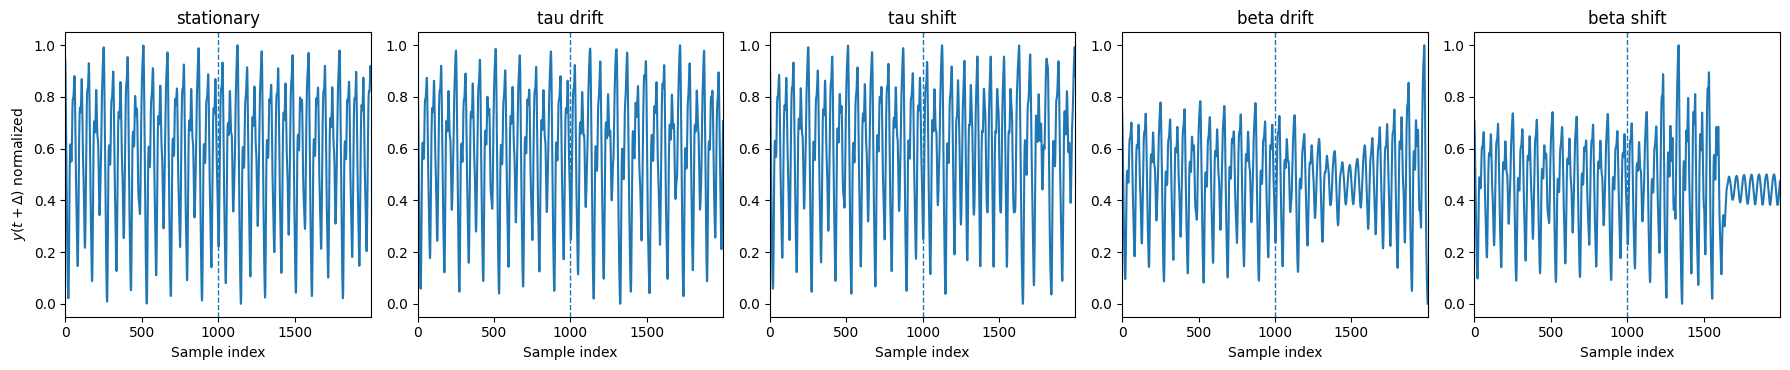

In [ ]:
# =========================
# CELL 4 — Plot the 5 MG datasets
# Normalized TARGET streams y(t+DELTA), side by side
# =========================
import numpy as np
import matplotlib.pyplot as plt

order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift",
         "MG_beta_drift", "MG_beta_shift"]

plt.figure(figsize=(18, 3.8))

for i, name in enumerate(order):
    X_train, X_test, y_train, y_test = data_splits_norm[name]

    # Reconstruct full normalized target stream
    y_full = np.concatenate([y_train, y_test])
    t = np.arange(len(y_full))

    ax = plt.subplot(1, 5, i + 1)
    ax.plot(t, y_full, linewidth=1.5)
    ax.axvline(len(y_train), linestyle="--", linewidth=1)

    ax.set_title(name.replace("MG_", "").replace("_", " "))
    ax.set_xlabel("Sample index")
    if i == 0:
        ax.set_ylabel(r"$y(t+\Delta)$ normalized")

    ax.set_xlim(0, len(y_full) - 1)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

**DLSM (Batch Level-Set Model)**

In [ ]:

# =========================
# CELL 5 — Batch DLSM (only) on ALL 5 normalized MG datasets
# Output: MSE + runtime (per dataset) + store predictions for later comparison
# + DIAGNOSTIC PRINTS (for “flat” predictions / horizontal scatter)
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
N_RULES      = 20      # number of clusters/rules (fixed for DLSM)
SIGMA_SCALE  = 0.45    # scales per-rule std (larger => broader rules)
TAU_POWER    = 2.0     # IMPORTANT: >1 => sharper (try 1.0, 2.0, 3.0)

RIDGE_U      = 1e-3

USE_GLOBAL_SIGMA = True   # recommended for 6-D MG; prevents overly broad per-cluster sigmas
SIGMA_FLOOR = 1e-3        # since X is in [0,1], small floor is enough
EPS          = 1e-12
RCOND        = 1e-12
SEED         = 0
# --------------------------------------------

def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if abs(s) > eps else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_rule_activations(x, centers, sigmas, eps=1e-12, tau_power=1.0):
    # Sharpened Gaussian: exp( -0.5 * tau_power * ||(x-c)/sigma||^2 )
    x = np.asarray(x, float).ravel()
    diff = (x[None, :] - centers) / np.maximum(sigmas, eps)
    dist2 = np.sum(diff * diff, axis=1)
    return np.exp(-0.5 * float(tau_power) * dist2)

def make_rules_kmeans(X_train, n_rules, sigma_scale=1.0, seed=0,
                     use_global_sigma=True, sigma_floor=1e-3):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(X_train)
    centers = km.cluster_centers_
    labels = km.labels_

    if use_global_sigma:
        # robust global sigma in [0,1] space (avoid broad/uneven cluster sigmas)
        global_std = X_train.std(axis=0)
        global_std = np.maximum(global_std, sigma_floor)
        sigmas = np.tile(global_std[None, :], (n_rules, 1))
    else:
        # per-cluster diagonal std; fallback to global std if cluster too small
        global_std = np.maximum(X_train.std(axis=0), sigma_floor)
        sigmas = np.zeros_like(centers)
        for i in range(n_rules):
            Xi = X_train[labels == i]
            if Xi.shape[0] >= 5:
                sigmas[i] = np.maximum(Xi.std(axis=0), sigma_floor)
            else:
                sigmas[i] = global_std

    sigmas *= float(sigma_scale)
    sigmas = np.maximum(sigmas, sigma_floor)
    return centers, sigmas

def dlsm_fit(X, y, centers, sigmas, eps=1e-12, rcond=1e-12, tau_power=1.0, ridge_u=0.0):
    D = np.vstack([
        build_d_from_tau(gaussian_rule_activations(x, centers, sigmas, eps, tau_power), eps)
        for x in X
    ])

    if ridge_u is None or ridge_u <= 0:
        u, *_ = np.linalg.lstsq(D, y, rcond=rcond)
        return u

    # Ridge: (D^T D + λI)u = D^T y
    DtD = D.T @ D
    Dty = D.T @ y
    u = np.linalg.solve(DtD + float(ridge_u) * np.eye(D.shape[1]), Dty)
    return u

def predict_batch(X, u, centers, sigmas, eps=1e-12, tau_power=1.0):
    yhat = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, eps, tau_power)
        d = build_d_from_tau(tau, eps)
        yhat[k] = float(d @ u)
    return yhat

def tau_diagnostics(X, centers, sigmas, tau_power, n_check=300):
    # quick check if taus are too flat (bad) or too spiky (also bad)
    Xc = X[:min(n_check, X.shape[0])]
    taus = np.vstack([gaussian_rule_activations(x, centers, sigmas, EPS, tau_power) for x in Xc])
    taus = np.maximum(taus, 1e-15)
    taus_n = taus / np.sum(taus, axis=1, keepdims=True)
    top1 = np.mean(np.max(taus_n, axis=1))
    ent = np.mean(-np.sum(taus_n * np.log(taus_n), axis=1))
    return float(top1), float(ent)

# ---- NEW: diagnostics for “flat” predictions ----
def pred_diagnostics(y_true, y_pred):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()

    yt_min, yt_max = float(y_true.min()), float(y_true.max())
    yp_min, yp_max = float(y_pred.min()), float(y_pred.max())

    yt_std = float(np.std(y_true))
    yp_std = float(np.std(y_pred))

    # if these are << 1, predictions are compressed (horizontal scatter)
    range_ratio = (yp_max - yp_min) / max((yt_max - yt_min), 1e-12)
    std_ratio   = yp_std / max(yt_std, 1e-12)

    # correlation: low corr often matches “horizontal band” scatter
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if y_true.size > 2 else float("nan")

    # bias check
    bias = float(np.mean(y_pred - y_true))

    return dict(
        y_true_min=yt_min, y_true_max=yt_max, y_true_std=yt_std,
        y_pred_min=yp_min, y_pred_max=yp_max, y_pred_std=yp_std,
        range_ratio=range_ratio, std_ratio=std_ratio,
        corr=corr, bias=bias
    )

# -----------------------------
# Run DLSM on all 5 datasets
# -----------------------------
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift", "MG_beta_drift", "MG_beta_shift"]

dlsm_models = {}
dlsm_preds  = {}
dlsm_stats  = {}

print("\n[DLSM CONFIG]")
print(f"  N_RULES={N_RULES} | SIGMA_SCALE={SIGMA_SCALE} | TAU_POWER={TAU_POWER}")
print(f"  USE_GLOBAL_SIGMA={USE_GLOBAL_SIGMA} | SIGMA_FLOOR={SIGMA_FLOOR} | RCOND={RCOND} | SEED={SEED}")

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]
    y_train = np.asarray(y_train, float).ravel()
    y_test  = np.asarray(y_test,  float).ravel()

    t0 = time.perf_counter()

    centers, sigmas = make_rules_kmeans(
        X_train, N_RULES, SIGMA_SCALE, SEED,
        use_global_sigma=USE_GLOBAL_SIGMA, sigma_floor=SIGMA_FLOOR
    )

    u = dlsm_fit(X_train, y_train, centers, sigmas, EPS, RCOND, tau_power=TAU_POWER, ridge_u=RIDGE_U)
    yhat_test = predict_batch(X_test, u, centers, sigmas, EPS, tau_power=TAU_POWER)

    mse_test = float(np.mean((y_test - yhat_test) ** 2))
    t1 = time.perf_counter()

    # diagnostics: if top1 ~ 0.10-0.20 => too flat; if top1 ~ 0.90 => too spiky
    top1, ent = tau_diagnostics(X_train, centers, sigmas, TAU_POWER)

    # NEW: prediction compression diagnostics
    pd = pred_diagnostics(y_test, yhat_test)

    # NEW: sigma sanity
    sig_min = float(np.min(sigmas))
    sig_med = float(np.median(sigmas))
    sig_max = float(np.max(sigmas))
    centers_spread = float(np.mean(np.std(centers, axis=0)))

    dlsm_models[name] = (centers, sigmas, u)
    dlsm_preds[name]  = yhat_test
    dlsm_stats[name]  = dict(
        mse=mse_test,
        runtime=float(t1 - t0),
        u_shape=u.shape,
        tau_top1=top1,
        tau_entropy=ent,
        # extra debug
        sigma_min=sig_min, sigma_med=sig_med, sigma_max=sig_max,
        centers_spread=centers_spread,
        y_true_min=pd["y_true_min"], y_true_max=pd["y_true_max"], y_true_std=pd["y_true_std"],
        y_pred_min=pd["y_pred_min"], y_pred_max=pd["y_pred_max"], y_pred_std=pd["y_pred_std"],
        range_ratio=pd["range_ratio"], std_ratio=pd["std_ratio"],
        corr=pd["corr"], bias=pd["bias"],
    )

    print(
        f"{name}: DLSM u {u.shape} | MSE(test)={mse_test:.6f} | time={t1-t0:.4f}s "
        f"| tau_top1={top1:.3f} | tau_entropy={ent:.3f}"
    )

# -----------------------------
# EXTRA PRINT SUMMARY (copy/paste back to me)
# -----------------------------
print("\n==================== DEBUG SUMMARY ====================")
for name in order:
    s = dlsm_stats[name]
    print(f"[{name}]")
    print(f"  MSE(test)={s['mse']:.6f} | runtime={s['runtime']:.4f}s | u_shape={s['u_shape']}")
    print(f"  tau_top1={s['tau_top1']:.3f} | tau_entropy={s['tau_entropy']:.3f}")
    print(f"  sigmas: min={s['sigma_min']:.4g} | med={s['sigma_med']:.4g} | max={s['sigma_max']:.4g}")
    print(f"  centers_spread(mean std over dims)={s['centers_spread']:.4f}")
    print(f"  y_true: min={s['y_true_min']:.4f} max={s['y_true_max']:.4f} std={s['y_true_std']:.4f}")
    print(f"  y_pred: min={s['y_pred_min']:.4f} max={s['y_pred_max']:.4f} std={s['y_pred_std']:.4f}")
    print(f"  compression: range_ratio={s['range_ratio']:.3f} | std_ratio={s['std_ratio']:.3f}")
    print(f"  corr={s['corr']:.3f} | bias={s['bias']:.4f}")
    print("-----------------------------------------------------------------------")
print("========================================================================\n")


[DLSM CONFIG]
  N_RULES=20 | SIGMA_SCALE=0.45 | TAU_POWER=2.0
  USE_GLOBAL_SIGMA=True | SIGMA_FLOOR=0.001 | RCOND=1e-12 | SEED=0
MG_stationary: DLSM u (40,) | MSE(test)=0.030008 | time=0.1987s | tau_top1=0.789 | tau_entropy=0.550
MG_tau_drift: DLSM u (40,) | MSE(test)=0.054753 | time=0.1497s | tau_top1=0.789 | tau_entropy=0.550
MG_tau_shift: DLSM u (40,) | MSE(test)=0.077312 | time=0.1549s | tau_top1=0.789 | tau_entropy=0.550
MG_beta_drift: DLSM u (40,) | MSE(test)=0.020205 | time=0.1722s | tau_top1=0.799 | tau_entropy=0.535
MG_beta_shift: DLSM u (40,) | MSE(test)=0.028823 | time=0.1585s | tau_top1=0.799 | tau_entropy=0.543

==================== DEBUG SUMMARY ====================
[MG_stationary]
  MSE(test)=0.030008 | runtime=0.1987s | u_shape=(40,)
  tau_top1=0.789 | tau_entropy=0.550
  sigmas: min=0.092 | med=0.09642 | max=0.1001
  centers_spread(mean std over dims)=0.2256
  y_true: min=0.0000 max=1.0000 std=0.2461
  y_pred: min=0.0957 max=0.9012 std=0.1688
  compression: range_rati

**DLSM: Plots**

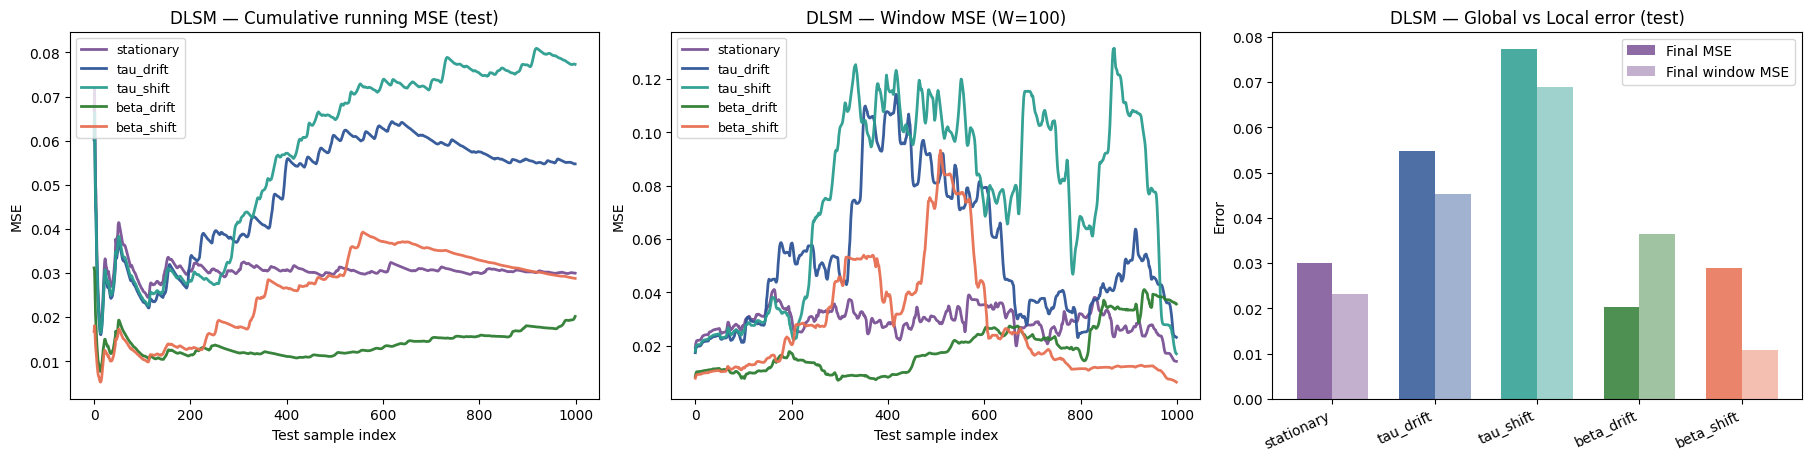

Dropdown(description='Dataset:', layout=Layout(width='420px'), options=('MG_stationary', 'MG_tau_drift', 'MG_t…

Output()

In [ ]:
# =========================
# CELL 6 — DLSM visualization
# Overview + drill-down (no plot explosion)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Optional widgets (Colab)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# -------------------------
# Styling (match MG final palette idea)
# -------------------------
ds_color = {
    "MG_stationary": "#7A5195",  # muted purple
    "MG_tau_drift":  "#2F5597",  # darker blue
    "MG_tau_shift":  "#2A9D8F",  # muted teal
    "MG_beta_drift": "#2E7D32",  # darker green
    "MG_beta_shift": "#E76F51",  # muted orange
}
TRUE_COLOR = "black"
LW_TRUE = 1.8
LW_PRED = 1.05
LW_CURVE = 2.0

# -------------------------
# Error metrics
# -------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred)**2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W=80):
    e2 = (y_true - y_pred)**2
    return np.convolve(e2, np.ones(W)/W, mode="same")

W = 100

order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift",
         "MG_beta_drift", "MG_beta_shift"]

# ---------------------------------------------------------
# (A) Precompute curves for all datasets
# ---------------------------------------------------------
curves = {}
final_mse = {}
final_wmse = {}

for name in order:
    y_test = np.asarray(data_splits_norm[name][3], float).ravel()
    yhat   = np.asarray(dlsm_preds[name], float).ravel()

    rmse_c = running_mse(y_test, yhat)
    wmse_c = window_mse(y_test, yhat, W)

    curves[name] = dict(
        y_test=y_test,
        yhat=yhat,
        rmse=rmse_c,
        wmse=wmse_c
    )

    final_mse[name]  = float(np.mean((y_test - yhat)**2))
    final_wmse[name] = float(np.mean(wmse_c[-W:]))

# ---------------------------------------------------------
# (B) OVERVIEW FIGURE (3 plots)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

# (1) Cumulative running MSE
for name in order:
    axes[0].plot(
        curves[name]["rmse"],
        label=name.replace("MG_", ""),
        color=ds_color.get(name, None),
        linewidth=LW_CURVE,
        alpha=0.95
    )
axes[0].set_title("DLSM — Cumulative running MSE (test)")
axes[0].set_xlabel("Test sample index")
axes[0].set_ylabel("MSE")
axes[0].legend(fontsize=9)

# (2) Window-based MSE
for name in order:
    axes[1].plot(
        curves[name]["wmse"],
        label=name.replace("MG_", ""),
        color=ds_color.get(name, None),
        linewidth=LW_CURVE,
        alpha=0.95
    )
axes[1].set_title(f"DLSM — Window MSE (W={W})")
axes[1].set_xlabel("Test sample index")
axes[1].set_ylabel("MSE")
axes[1].legend(fontsize=9)

# (3) Final error bars (global vs local)
x = np.arange(len(order))
width = 0.35

axes[2].bar(
    x - width/2,
    [final_mse[n] for n in order],
    width,
    label="Final MSE",
    color=[ds_color[n] for n in order],
    alpha=0.85
)
axes[2].bar(
    x + width/2,
    [final_wmse[n] for n in order],
    width,
    label="Final window MSE",
    color=[ds_color[n] for n in order],
    alpha=0.45
)

axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace("MG_", "") for n in order],
                        rotation=25, ha="right")
axes[2].set_ylabel("Error")
axes[2].set_title("DLSM — Global vs Local error (test)")
axes[2].legend()

plt.show()

# ---------------------------------------------------------
# (C) DRILL-DOWN VIEW (now 4 plots, ONE dataset)
# ---------------------------------------------------------
def plot_detail(name):
    y_test = curves[name]["y_test"]
    yhat   = curves[name]["yhat"]
    rmse_c = curves[name]["rmse"]
    wmse_c = curves[name]["wmse"]
    t = np.arange(len(y_test))

    c = ds_color.get(name, "#2F5597")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5),
                             constrained_layout=True)

    # (1) Cumulative MSE
    axes[0].plot(rmse_c, color=c, linewidth=LW_CURVE)
    axes[0].set_title("Cumulative running MSE")
    axes[0].set_xlabel("Test index")
    axes[0].set_ylabel("MSE")

    # (2) Window MSE
    axes[1].plot(wmse_c, color=c, linewidth=LW_CURVE)
    axes[1].set_title(f"Window MSE (W={W})")
    axes[1].set_xlabel("Test index")
    axes[1].set_ylabel("MSE")

    # (3) Predicted vs True
    axes[2].scatter(y_test, yhat, s=18, alpha=0.7, color=c)
    mn = min(y_test.min(), yhat.min())
    mx = max(y_test.max(), yhat.max())
    axes[2].plot([mn, mx], [mn, mx], color="black", linewidth=1.2)
    axes[2].set_xlabel("True y (test)")
    axes[2].set_ylabel("Predicted ŷ")
    axes[2].set_title("Predicted vs True")

    # (4) Prediction over time
    axes[3].plot(t, y_test, label="True y", color=TRUE_COLOR, linewidth=LW_TRUE, alpha=0.9)
    axes[3].plot(t, yhat, label="Predicted ŷ", color=c, linewidth=LW_PRED, alpha=0.95)
    axes[3].set_xlabel("Test index")
    axes[3].set_ylabel("y value")
    axes[3].set_title("Prediction over time")
    axes[3].legend()

    fig.suptitle(name.replace("MG_", "").replace("_", " "),
                 fontsize=13)
    plt.show()

# Dataset selector
if HAS_WIDGETS:
    dd = widgets.Dropdown(
        options=order,
        value=order[0],
        description="Dataset:",
        layout=widgets.Layout(width="420px")
    )

    out = widgets.Output()

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            with out:
                clear_output(wait=True)
                plot_detail(change["new"])

    dd.observe(on_change)
    display(dd, out)

    with out:
        plot_detail(dd.value)
else:
    plot_detail(order[0])

**RLSM (Recursive Level-Set Model)**

In [ ]:
# =========================
# CELL 7 — RLSM (only) on ALL 5 normalized MG datasets
# Output: MSE + runtime (per dataset) + store predictions for later comparison
# Notes:
#   - Adds TAU_POWER for fair comparison (same “sharpness” control)
#   - FIXES the RLS update (compute K from old P, then update P and u)
#   - Uses the same sigma logic option as DLSM (global sigma recommended)
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
# Keep consistent with your DLSM choice
N_RULES        = 20
SIGMA_SCALE    = 0.45
TAU_POWER      = 2.0    # match your DLSM run (try 1.8 or 2.0)

ALPHA          = 1e5    # P0 = ALPHA * I
LAMBDA         = 1.0    # forgetting factor (1.0 = no forgetting)
UPDATE_ON_TEST = False  # True = adapt on test; False = freeze after training

USE_GLOBAL_SIGMA = True
SIGMA_FLOOR      = 1e-3

EPS            = 1e-12
SEED           = 0
# --------------------------------------------

def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if abs(s) > eps else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_rule_activations(x, centers, sigmas, eps=1e-12, tau_power=1.0):
    # Sharpened Gaussian: exp( -0.5 * tau_power * ||(x-c)/sigma||^2 )
    x = np.asarray(x, float).ravel()
    diff = (x[None, :] - centers) / np.maximum(sigmas, eps)
    dist2 = np.sum(diff * diff, axis=1)
    return np.exp(-0.5 * float(tau_power) * dist2)

def make_rules_kmeans(
    X_train, n_rules, sigma_scale=1.0, seed=0,
    use_global_sigma=True, sigma_floor=1e-3
):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(X_train)
    centers = km.cluster_centers_
    labels = km.labels_

    if use_global_sigma:
        global_std = np.maximum(X_train.std(axis=0), sigma_floor)
        sigmas = np.tile(global_std[None, :], (n_rules, 1))
    else:
        global_std = np.maximum(X_train.std(axis=0), sigma_floor)
        sigmas = np.zeros_like(centers)
        for i in range(n_rules):
            Xi = X_train[labels == i]
            if Xi.shape[0] >= 5:
                sigmas[i] = np.maximum(Xi.std(axis=0), sigma_floor)
            else:
                sigmas[i] = global_std

    sigmas *= float(sigma_scale)
    sigmas = np.maximum(sigmas, sigma_floor)
    return centers, sigmas

class RLSM:
    # RLS with regressor d (dim = 2*n_rules)
    def __init__(self, n_rules, alpha=1e5, lam=1.0, eps=1e-12):
        self.n_rules = int(n_rules)
        self.dim = 2 * self.n_rules
        self.u = np.zeros((self.dim,), float)
        self.P = float(alpha) * np.eye(self.dim, dtype=float)
        self.lam = float(lam)
        self.eps = float(eps)

    def update(self, d, y):
        """
        Standard RLS:
          K = P d / (lam + d^T P d)
          u <- u + K * (y - d^T u)
          P <- (1/lam) * (P - K d^T P)
        """
        y = float(y)
        d = np.asarray(d, float).ravel()

        Pu = self.u
        Pold = self.P

        yhat = float(d @ Pu)
        e = y - yhat

        Pd = Pold @ d
        denom = self.lam + float(d @ Pd)
        if abs(denom) < self.eps:
            denom = self.eps if denom >= 0 else -self.eps

        K = Pd / denom  # gain computed from OLD P

        # update u using same K
        self.u = Pu + K * e

        # update P
        self.P = (1.0 / self.lam) * (Pold - np.outer(K, Pd))

        return float(d @ self.u)

def predict_with_optional_update(model, X, y, centers, sigmas, do_update, eps=1e-12, tau_power=1.0):
    yhat = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, eps, tau_power=tau_power)
        d = build_d_from_tau(tau, eps)
        if do_update:
            yhat[k] = model.update(d, y[k])
        else:
            yhat[k] = float(d @ model.u)
    return yhat

# -----------------------------
# Run RLSM on all 5 datasets
# -----------------------------
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift", "MG_beta_drift", "MG_beta_shift"]

rlsm_models = {}
rlsm_preds  = {}
rlsm_stats  = {}

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]
    y_train = np.asarray(y_train, float).ravel()
    y_test  = np.asarray(y_test,  float).ravel()

    t0 = time.perf_counter()

    centers, sigmas = make_rules_kmeans(
        X_train, N_RULES, SIGMA_SCALE, SEED,
        use_global_sigma=USE_GLOBAL_SIGMA, sigma_floor=SIGMA_FLOOR
    )
    rlsm = RLSM(n_rules=N_RULES, alpha=ALPHA, lam=LAMBDA, eps=EPS)

    # Train stream (always updates)
    _ = predict_with_optional_update(
        rlsm, X_train, y_train, centers, sigmas,
        do_update=True, eps=EPS, tau_power=TAU_POWER
    )

    # Test phase (freeze or continue adapting)
    yhat_test = predict_with_optional_update(
        rlsm, X_test, y_test, centers, sigmas,
        do_update=UPDATE_ON_TEST, eps=EPS, tau_power=TAU_POWER
    )

    mse_test = float(np.mean((y_test - yhat_test) ** 2))

    t1 = time.perf_counter()
    runtime = float(t1 - t0)

    rlsm_models[name] = (centers, sigmas, rlsm.u.copy(), rlsm.P.copy())
    rlsm_preds[name]  = yhat_test
    rlsm_stats[name]  = dict(mse=mse_test, runtime=runtime, u_shape=rlsm.u.shape)

    print(
        f"{name}: RLSM u {rlsm.u.shape} | MSE(test)={mse_test:.6f} | "
        f"time={runtime:.4f}s | UPDATE_ON_TEST={UPDATE_ON_TEST}"
    )

MG_stationary: RLSM u (40,) | MSE(test)=0.030009 | time=0.5797s | UPDATE_ON_TEST=False
MG_tau_drift: RLSM u (40,) | MSE(test)=0.054757 | time=0.4109s | UPDATE_ON_TEST=False
MG_tau_shift: RLSM u (40,) | MSE(test)=0.077318 | time=0.6557s | UPDATE_ON_TEST=False
MG_beta_drift: RLSM u (40,) | MSE(test)=0.020210 | time=0.5324s | UPDATE_ON_TEST=False
MG_beta_shift: RLSM u (40,) | MSE(test)=0.028830 | time=0.4729s | UPDATE_ON_TEST=False


**RLSM: Plot**

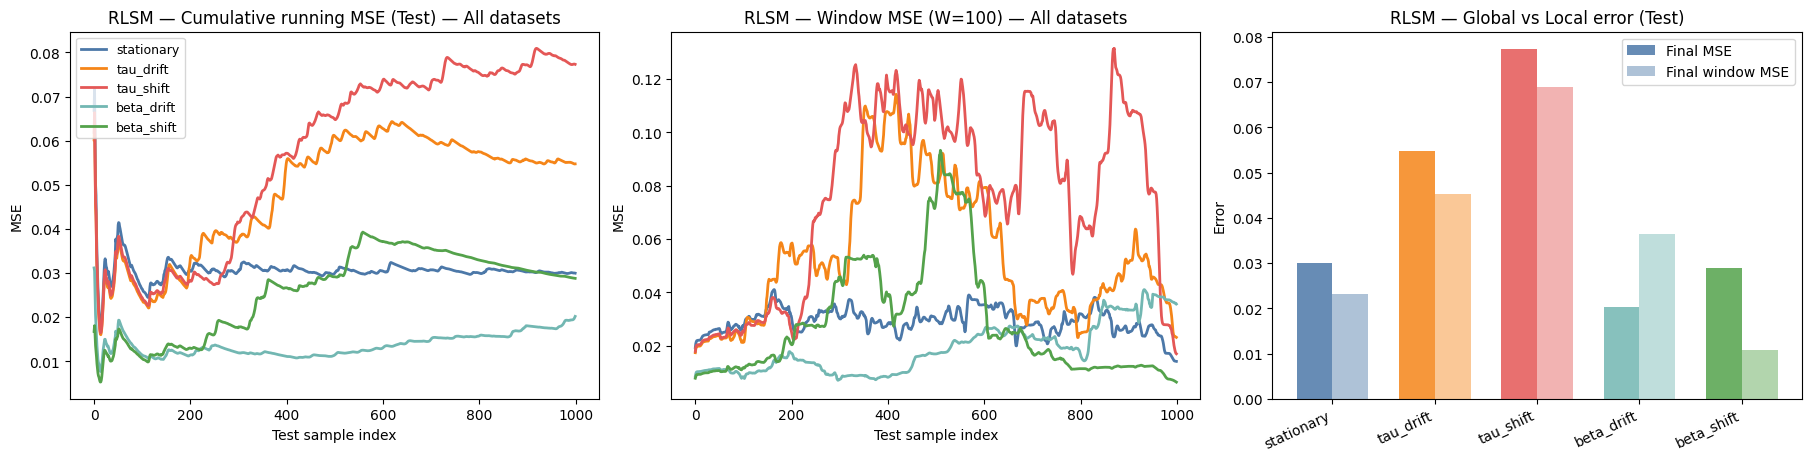

Dropdown(description='Dataset:', layout=Layout(width='450px'), options=('MG_stationary', 'MG_tau_drift', 'MG_t…

Output()

In [ ]:
# =========================
# CELL 8 — RLSM visualization (no plot explosion)
# Row 1: 3 overview plots (all datasets)
# Row 2: 4 detailed plots (one dataset, selectable)
# Notes:
#   - Uses TAU_POWER in activations (must match Cell 7)
#   - Uses same sigma logic (USE_GLOBAL_SIGMA, SIGMA_FLOOR)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Optional widgets (Colab)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# -------------------------
# Dataset colors (consistent across the whole notebook)
# -------------------------
ds_color = {
    "MG_stationary": "#4C78A8",  # blue
    "MG_tau_drift":  "#F58518",  # orange
    "MG_tau_shift":  "#E45756",  # red
    "MG_beta_drift": "#72B7B2",  # teal
    "MG_beta_shift": "#54A24B",  # green
}
TRUE_COLOR = "black"
MODEL_COLOR = "#2F5597"  # RLSM main color (dark blue, matches your palette style)

LW_DS   = 2.0
LW_TRUE = 1.8
LW_PRED = 1.15

# -------------------------
# Metrics
# -------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W=80):
    e2 = (y_true - y_pred) ** 2
    return np.convolve(e2, np.ones(W) / W, mode="same")

W = 100
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift", "MG_beta_drift", "MG_beta_shift"]

# ---------------------------------------------------------
# (A) Precompute predictions + curves for ALL datasets
# ---------------------------------------------------------
preds_rlsm = {}
final_mse_rlsm = {}
final_wmse_rlsm = {}

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]
    y_train = np.asarray(y_train, float).ravel()
    y_test  = np.asarray(y_test,  float).ravel()

    # Rules from TRAIN only (same logic as Cell 7)
    centers, sigmas = make_rules_kmeans(
        X_train, N_RULES, SIGMA_SCALE, SEED,
        use_global_sigma=USE_GLOBAL_SIGMA, sigma_floor=SIGMA_FLOOR
    )

    # Train RLSM sequentially
    rlsm = RLSM(n_rules=N_RULES, alpha=ALPHA, lam=LAMBDA, eps=EPS)
    _ = predict_with_optional_update(
        rlsm, X_train, y_train, centers, sigmas,
        do_update=True, eps=EPS, tau_power=TAU_POWER
    )

    # Test (freeze or continue adapting, per Cell 7)
    yhat_test = predict_with_optional_update(
        rlsm, X_test, y_test, centers, sigmas,
        do_update=UPDATE_ON_TEST, eps=EPS, tau_power=TAU_POWER
    )

    rmse_curve = running_mse(y_test, yhat_test)
    wmse_curve = window_mse(y_test, yhat_test, W)

    mse_final  = float(np.mean((y_test - yhat_test) ** 2))
    wmse_final = float(np.mean(wmse_curve[-W:]))

    preds_rlsm[name] = dict(
        y_test=y_test,
        yhat_test=yhat_test,
        rmse_curve=rmse_curve,
        wmse_curve=wmse_curve
    )
    final_mse_rlsm[name]  = mse_final
    final_wmse_rlsm[name] = wmse_final

# ---------------------------------------------------------
# (B) OVERVIEW FIGURE (3 plots)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

# (1) Cumulative running MSE curves (all)
for name in order:
    axes[0].plot(
        preds_rlsm[name]["rmse_curve"],
        label=name.replace("MG_", ""),
        color=ds_color.get(name, None),
        linewidth=LW_DS
    )
axes[0].set_xlabel("Test sample index")
axes[0].set_ylabel("MSE")
axes[0].set_title("RLSM — Cumulative running MSE (Test) — All datasets")
axes[0].legend(fontsize=9)

# (2) Window-based MSE curves (all)
for name in order:
    axes[1].plot(
        preds_rlsm[name]["wmse_curve"],
        label=name.replace("MG_", ""),
        color=ds_color.get(name, None),
        linewidth=LW_DS
    )
axes[1].set_xlabel("Test sample index")
axes[1].set_ylabel("MSE")
axes[1].set_title(f"RLSM — Window MSE (W={W}) — All datasets")

# (3) Bar chart: Final MSE vs Final Window MSE (colored per dataset, like DLSM)
x = np.arange(len(order))
width = 0.35

axes[2].bar(
    x - width/2,
    [final_mse_rlsm[n] for n in order],
    width,
    label="Final MSE",
    color=[ds_color[n] for n in order],
    alpha=0.85
)
axes[2].bar(
    x + width/2,
    [final_wmse_rlsm[n] for n in order],
    width,
    label="Final window MSE",
    color=[ds_color[n] for n in order],
    alpha=0.45
)

axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace("MG_", "") for n in order], rotation=25, ha="right")
axes[2].set_ylabel("Error")
axes[2].set_title("RLSM — Global vs Local error (Test)")
axes[2].legend()

plt.show()

# ---------------------------------------------------------
# (C) DRILL-DOWN VIEW (4 plots) — one dataset at a time
# ---------------------------------------------------------
def plot_detail_rlsm(name):
    y_test = preds_rlsm[name]["y_test"]
    yhat   = preds_rlsm[name]["yhat_test"]
    rmse_c = preds_rlsm[name]["rmse_curve"]
    wmse_c = preds_rlsm[name]["wmse_curve"]
    t = np.arange(len(y_test))

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), constrained_layout=True)

    # (1) Cumulative running MSE
    axes[0].plot(rmse_c, color=MODEL_COLOR, linewidth=2.0)
    axes[0].set_xlabel("Test sample index")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Cumulative running MSE")

    # (2) Window MSE
    axes[1].plot(wmse_c, color=MODEL_COLOR, linewidth=2.0)
    axes[1].set_xlabel("Test sample index")
    axes[1].set_ylabel("MSE")
    axes[1].set_title(f"Window MSE (W={W})")

    # (3) Predicted vs True
    axes[2].scatter(y_test, yhat, s=18, alpha=0.7, color=MODEL_COLOR)
    mn = float(min(y_test.min(), yhat.min()))
    mx = float(max(y_test.max(), yhat.max()))
    axes[2].plot([mn, mx], [mn, mx], color="black", linewidth=1.1)
    axes[2].set_xlabel("True y (test)")
    axes[2].set_ylabel("Predicted ŷ (test)")
    axes[2].set_title("Predicted vs True")

    # (4) Prediction over time
    axes[3].plot(t, y_test, label="True y", color=TRUE_COLOR, linewidth=LW_TRUE, alpha=0.9)
    axes[3].plot(t, yhat,   label="RLSM",  color=MODEL_COLOR, linewidth=LW_PRED)
    axes[3].set_xlabel("Test sample index")
    axes[3].set_ylabel("y value")
    axes[3].set_title("Prediction over time (Test)")
    axes[3].legend()

    fig.suptitle(f"RLSM — {name.replace('MG_', '').replace('_', ' ')}", fontsize=13)
    plt.show()

if HAS_WIDGETS:
    dd = widgets.Dropdown(
        options=order,
        value=order[0],
        description="Dataset:",
        layout=widgets.Layout(width="450px")
    )

    out = widgets.Output()

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            with out:
                clear_output(wait=True)
                plot_detail_rlsm(change["new"])

    dd.observe(on_change)
    display(dd, out)

    with out:
        plot_detail_rlsm(dd.value)
else:
    best = min(final_mse_rlsm, key=final_mse_rlsm.get)
    worst = max(final_mse_rlsm, key=final_mse_rlsm.get)
    print("Widgets not available. Showing detailed plots for:")
    print("  Best :", best, "MSE =", final_mse_rlsm[best])
    print("  Worst:", worst, "MSE =", final_mse_rlsm[worst])
    plot_detail_rlsm(best)
    plot_detail_rlsm(worst)

**ALSM (Adaptive Level-Set Model)**

In [ ]:
# =========================
# CELL 9 — ALSM (SAFE) on ALL 5 normalized MG datasets
# - bounded correntropy weight
# - ridge-stabilized RLS update
# - numerically stable Gaussian activations
# - optional online adaptation on test
# - optional clipping ONLY for evaluation (recommend OFF for debugging)
# STORES:
#   - alsm_preds[dataset]   = yhat_test
#   - alsm_time_s[dataset]  = runtime seconds (train + test)
#   - alsm_stats[dataset]   = dict with mse/runtime/u_shape/etc.
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------
N_RULES          = 20
SIGMA_SCALE      = 0.45     # keep close to DLSM
USE_GLOBAL_SIGMA = True
SIGMA_FLOOR      = 1e-3

ALPHA            = 1e3
LAMBDA           = 0.995
ZETA             = 0.25
RIDGE            = 1e-3
UPDATE_ON_TEST   = True

CLIP_YHAT        = True    # debug-friendly (clip later for plots if needed)
EPS              = 1e-12
SEED             = 0
# --------------------------------------------

print("[ALSM CONFIG]")
print(f"  N_RULES={N_RULES} | SIGMA_SCALE={SIGMA_SCALE} | USE_GLOBAL_SIGMA={USE_GLOBAL_SIGMA} | SIGMA_FLOOR={SIGMA_FLOOR}")
print(f"  ALPHA={ALPHA} | LAMBDA={LAMBDA} | ZETA={ZETA} | RIDGE={RIDGE} | UPDATE_ON_TEST={UPDATE_ON_TEST} | CLIP_YHAT={CLIP_YHAT}")

# -------------------------
# Helper functions
# -------------------------
def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if (np.isfinite(s) and abs(s) > eps) else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_rule_activations(x, centers, sigmas, eps=1e-12):
    x = np.asarray(x, float).ravel()
    sig = np.maximum(sigmas, eps)
    diff = (x[None, :] - centers) / sig
    dist2 = np.sum(diff * diff, axis=1)
    a = -0.5 * dist2
    a = a - np.max(a)          # log-sum-exp stabilization
    return np.exp(a)

def make_rules_kmeans(X_train, n_rules, sigma_scale=1.0, seed=0,
                     use_global_sigma=True, sigma_floor=1e-3):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(X_train)
    centers = km.cluster_centers_
    labels = km.labels_

    global_std = np.maximum(X_train.std(axis=0), sigma_floor)

    if use_global_sigma:
        sigmas = np.tile(global_std[None, :], (n_rules, 1))
    else:
        sigmas = np.zeros_like(centers)
        for i in range(n_rules):
            Xi = X_train[labels == i]
            if Xi.shape[0] >= 5:
                sigmas[i] = np.maximum(Xi.std(axis=0), sigma_floor)
            else:
                sigmas[i] = global_std

    sigmas *= float(sigma_scale)
    sigmas = np.maximum(sigmas, sigma_floor)
    return centers, sigmas

def tau_diagnostics(X, centers, sigmas, n_check=300, eps=1e-12):
    Xc = X[:min(n_check, X.shape[0])]
    taus = np.vstack([gaussian_rule_activations(x, centers, sigmas, eps) for x in Xc])
    taus = np.maximum(taus, 1e-15)
    taus_n = taus / np.sum(taus, axis=1, keepdims=True)
    top1 = float(np.mean(np.max(taus_n, axis=1)))
    ent = float(np.mean(-np.sum(taus_n * np.log(taus_n), axis=1)))
    return top1, ent

def pred_diagnostics(y_true, y_pred):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    yt_min, yt_max = float(y_true.min()), float(y_true.max())
    yp_min, yp_max = float(y_pred.min()), float(y_pred.max())
    yt_std, yp_std = float(np.std(y_true)), float(np.std(y_pred))
    range_ratio = (yp_max - yp_min) / max((yt_max - yt_min), 1e-12)
    std_ratio   = yp_std / max(yt_std, 1e-12)
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if y_true.size > 2 else float("nan")
    bias = float(np.mean(y_pred - y_true))
    return range_ratio, std_ratio, corr, bias

# -------------------------
# ALSM model
# -------------------------
class ALSM:
    def __init__(self, n_rules, alpha, lam, zeta, ridge, clip_yhat=False, eps=1e-12):
        self.n_rules = int(n_rules)
        self.dim = 2 * self.n_rules
        self.u = np.zeros((self.dim,), float)
        self.P = float(alpha) * np.eye(self.dim, dtype=float)
        self.lam = float(lam)
        self.zeta = float(zeta)
        self.ridge = float(ridge)
        self.clip_yhat = bool(clip_yhat)
        self.eps = float(eps)

    def psi(self, e):
        z = max(self.zeta, self.eps)
        return float(np.exp(-(e*e) / (2.0*z*z)))  # in (0,1]

    def step(self, d, y):
        y = float(y)
        yhat_raw  = float(d @ self.u)
        yhat_eval = float(np.clip(yhat_raw, 0.0, 1.0)) if self.clip_yhat else yhat_raw

        e = y - yhat_raw                  # learning uses RAW residual
        w = self.psi(e)

        Pd = self.P @ d
        denom = self.lam + w * float(d @ Pd) + self.ridge
        if abs(denom) < self.eps:
            denom = self.eps if denom >= 0 else -self.eps

        K = Pd / denom
        self.u = self.u + (w * K) * e
        self.P = (1.0 / self.lam) * (self.P - w * np.outer(K, Pd))

        return yhat_eval, yhat_raw

def run_stream(model, X, y, centers, sigmas, do_update):
    yhat = np.zeros((X.shape[0],), float)
    yraw = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, EPS)
        d = build_d_from_tau(tau, EPS)
        if do_update:
            yhat[k], yraw[k] = model.step(d, y[k])
        else:
            yraw_k = float(d @ model.u)
            yhat[k] = float(np.clip(yraw_k, 0.0, 1.0)) if model.clip_yhat else yraw_k
            yraw[k] = yraw_k
    return yhat, yraw

# -------------------------
# Run on all datasets (STORE preds + runtime)
# -------------------------
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift", "MG_beta_drift", "MG_beta_shift"]

alsm_preds   = {}  # {ds: yhat_test}
alsm_time_s  = {}  # {ds: runtime seconds}  <-- NEW
alsm_stats   = {}  # {ds: dict(...)}        <-- NEW (optional but useful)

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]
    y_train = np.asarray(y_train, float).ravel()
    y_test  = np.asarray(y_test,  float).ravel()

    t0 = time.perf_counter()

    centers, sigmas = make_rules_kmeans(
        X_train, N_RULES, SIGMA_SCALE, SEED,
        use_global_sigma=USE_GLOBAL_SIGMA, sigma_floor=SIGMA_FLOOR
    )

    alsm = ALSM(
        n_rules=N_RULES,
        alpha=ALPHA,
        lam=LAMBDA,
        zeta=ZETA,
        ridge=RIDGE,
        clip_yhat=CLIP_YHAT,
        eps=EPS
    )

    _ = run_stream(alsm, X_train, y_train, centers, sigmas, do_update=True)
    yhat_test, yraw_test = run_stream(alsm, X_test, y_test, centers, sigmas, do_update=UPDATE_ON_TEST)

    mse_test = float(np.mean((y_test - yhat_test) ** 2))
    clip_rate = float(np.mean((yraw_test < 0.0) | (yraw_test > 1.0)))  # raw-only diagnostic

    t1 = time.perf_counter()
    runtime = float(t1 - t0)

    top1, ent = tau_diagnostics(X_train, centers, sigmas)
    rr, sr, corr, bias = pred_diagnostics(y_test, yhat_test)

    # ---- STORE (fixes NA in global table) ----
    alsm_preds[name]  = yhat_test.copy()
    alsm_time_s[name] = runtime
    alsm_stats[name]  = dict(
        mse=mse_test,
        runtime=runtime,
        u_shape=alsm.u.shape,
        tau_top1=top1,
        tau_entropy=ent,
        clip_rate_raw=clip_rate,
        range_ratio=rr,
        std_ratio=sr,
        corr=corr,
        bias=bias,
    )

    print(f"{name}: ALSM u {alsm.u.shape} | MSE(test)={mse_test:.6f} | time={runtime:.4f}s | UPDATE_ON_TEST={UPDATE_ON_TEST}")
    print(f"          tau_top1={top1:.3f} | tau_entropy={ent:.3f}")
    print(f"          y_test range     = [{y_test.min():.4f}, {y_test.max():.4f}]")
    print(f"          yhat_raw range   = [{yraw_test.min():.4f}, {yraw_test.max():.4f}] | clip_rate(raw)={clip_rate:.3f}")
    print(f"          compression: range_ratio={rr:.3f} | std_ratio={sr:.3f} | corr={corr:.3f} | bias={bias:.4f}")

[ALSM CONFIG]
  N_RULES=20 | SIGMA_SCALE=0.45 | USE_GLOBAL_SIGMA=True | SIGMA_FLOOR=0.001
  ALPHA=1000.0 | LAMBDA=0.995 | ZETA=0.25 | RIDGE=0.001 | UPDATE_ON_TEST=True | CLIP_YHAT=True
MG_stationary: ALSM u (40,) | MSE(test)=0.031028 | time=0.5588s | UPDATE_ON_TEST=True
          tau_top1=0.615 | tau_entropy=0.996
          y_test range     = [0.0000, 1.0000]
          yhat_raw range   = [0.1255, 1.0004] | clip_rate(raw)=0.001
          compression: range_ratio=0.875 | std_ratio=0.736 | corr=0.700 | bias=0.0084
MG_tau_drift: ALSM u (40,) | MSE(test)=0.050933 | time=0.6469s | UPDATE_ON_TEST=True
          tau_top1=0.615 | tau_entropy=0.996
          y_test range     = [0.0000, 1.0000]
          yhat_raw range   = [0.1404, 0.9992] | clip_rate(raw)=0.000
          compression: range_ratio=0.859 | std_ratio=0.672 | corr=0.437 | bias=0.0072
MG_tau_shift: ALSM u (40,) | MSE(test)=0.057029 | time=0.4716s | UPDATE_ON_TEST=True
          tau_top1=0.615 | tau_entropy=0.996
          y_test range

**ALSM: Plots**

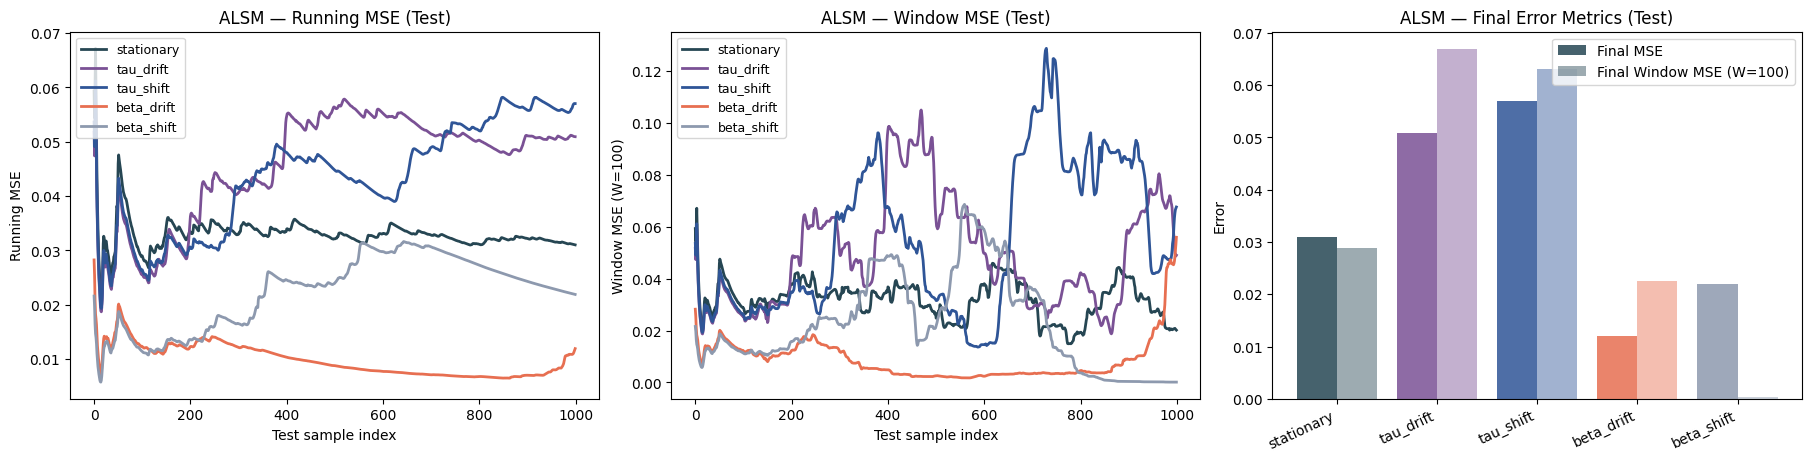

Dropdown(description='Dataset:', layout=Layout(width='420px'), options=('MG_stationary', 'MG_tau_drift', 'MG_t…

Output()

In [ ]:
# =========================
# CELL 10 — ALSM visualization (compact, with window metric)
# Layout:
#   Row 1 (3 panels): running MSE | window-MSE (rolling) | bars: final MSE + final window-MSE
#   Row 2 (4 panels): running MSE | window-MSE | scatter | time series (ONE selected dataset)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Optional (for dropdown UI in Colab)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# -----------------------
# Metrics
# -----------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W=100):
    e2 = (y_true - y_pred) ** 2
    out = np.zeros_like(e2, dtype=float)
    c = np.cumsum(e2)
    for k in range(len(e2)):
        if k < W:
            out[k] = c[k] / (k + 1)
        else:
            out[k] = (c[k] - c[k - W]) / W
    return out

# -----------------------
# Configuration
# -----------------------
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift",
         "MG_beta_drift", "MG_beta_shift"]

W = 100  # window size for window-MSE

# -----------------------
# Styling (match your palette logic)
# -----------------------
TRUE_COLOR = "black"
ALSM_COLOR = "#2A9D8F"  # teal (same idea as your Diabetes palette)

# dataset colors for OVERVIEW curves/bars (consistent across models)
dataset_color = {
    "MG_stationary": "#264653",  # deep teal
    "MG_tau_drift":  "#7A5195",  # purple
    "MG_tau_shift":  "#2F5597",  # blue
    "MG_beta_drift": "#E76F51",  # muted orange/red
    "MG_beta_shift": "#8D99AE",  # gray-blue
}

LW_OVERVIEW = 2.0
LW_DETAIL   = 1.2
S_SCAT      = 18

# -----------------------
# Use predictions from CELL 9
# -----------------------
preds_alsm = {}
final_mse_alsm = {}
final_wmse_alsm = {}

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]  # clearer + correct
    y_test = np.asarray(y_test, float).ravel()
    yhat_test = np.asarray(alsm_preds[name], float).ravel()

    rmse_curve = running_mse(y_test, yhat_test)
    wmse_curve = window_mse(y_test, yhat_test, W=W)

    preds_alsm[name] = dict(
        y_test=y_test,
        yhat_test=yhat_test,
        rmse_curve=rmse_curve,
        wmse_curve=wmse_curve,
    )
    final_mse_alsm[name]  = float(np.mean((y_test - yhat_test) ** 2))
    final_wmse_alsm[name] = float(np.mean(wmse_curve[-W:]))  # stable "final window" metric

# ---------------------------------------------------------
# (A) OVERVIEW FIGURE — Row 1 (3 panels)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

# (1) Running MSE
for name in order:
    axes[0].plot(
        preds_alsm[name]["rmse_curve"],
        label=name.replace("MG_", ""),
        color=dataset_color.get(name, None),
        linewidth=LW_OVERVIEW
    )
axes[0].set_xlabel("Test sample index")
axes[0].set_ylabel("Running MSE")
axes[0].set_title("ALSM — Running MSE (Test)")
axes[0].legend(fontsize=9)

# (2) Window-MSE
for name in order:
    axes[1].plot(
        preds_alsm[name]["wmse_curve"],
        label=name.replace("MG_", ""),
        color=dataset_color.get(name, None),
        linewidth=LW_OVERVIEW
    )
axes[1].set_xlabel("Test sample index")
axes[1].set_ylabel(f"Window MSE (W={W})")
axes[1].set_title("ALSM — Window MSE (Test)")
axes[1].legend(fontsize=9)

# (3) Bars: Final metrics (use same dataset colors)
x = np.arange(len(order))
bar_w = 0.40

axes[2].bar(
    x - bar_w/2,
    [final_mse_alsm[n] for n in order],
    width=bar_w,
    label="Final MSE",
    color=[dataset_color.get(n, None) for n in order],
    alpha=0.85
)
axes[2].bar(
    x + bar_w/2,
    [final_wmse_alsm[n] for n in order],
    width=bar_w,
    label=f"Final Window MSE (W={W})",
    color=[dataset_color.get(n, None) for n in order],
    alpha=0.45
)

axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace("MG_", "") for n in order],
                        rotation=25, ha="right")
axes[2].set_ylabel("Error")
axes[2].set_title("ALSM — Final Error Metrics (Test)")
axes[2].legend()

plt.show()

# ---------------------------------------------------------
# (B) DRILL-DOWN — Row 2 (4 panels)
# ---------------------------------------------------------
def plot_detail_alsm(name):
    y_test = preds_alsm[name]["y_test"]
    yhat   = preds_alsm[name]["yhat_test"]
    rmse_c = preds_alsm[name]["rmse_curve"]
    wmse_c = preds_alsm[name]["wmse_curve"]
    t = np.arange(len(y_test))

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), constrained_layout=True)

    # (1) Running MSE
    axes[0].plot(rmse_c, color=ALSM_COLOR, linewidth=LW_OVERVIEW)
    axes[0].set_xlabel("Test sample index")
    axes[0].set_ylabel("Running MSE")
    axes[0].set_title("Running MSE")

    # (2) Window MSE
    axes[1].plot(wmse_c, color=ALSM_COLOR, linewidth=LW_OVERVIEW)
    axes[1].set_xlabel("Test sample index")
    axes[1].set_ylabel(f"Window MSE (W={W})")
    axes[1].set_title("Window MSE")

    # (3) Predicted vs True
    axes[2].scatter(y_test, yhat, s=S_SCAT, alpha=0.7, color=ALSM_COLOR)
    mn = float(min(y_test.min(), yhat.min()))
    mx = float(max(y_test.max(), yhat.max()))
    axes[2].plot([mn, mx], [mn, mx], color="black", linewidth=1.1)
    axes[2].set_xlabel("True y (test)")
    axes[2].set_ylabel("Predicted ŷ (test)")
    axes[2].set_title("Predicted vs True")

    # (4) Over time
    axes[3].plot(t, y_test, label="True y", color=TRUE_COLOR, linewidth=1.6)
    axes[3].plot(t, yhat, label="ALSM", color=ALSM_COLOR, linewidth=LW_DETAIL)
    axes[3].set_xlabel("Test sample index")
    axes[3].set_ylabel("y value")
    axes[3].set_title("Prediction over Time")
    axes[3].legend()

    fig.suptitle(name.replace("MG_", ""), fontsize=13)
    plt.show()

if HAS_WIDGETS:
    dd = widgets.Dropdown(
        options=order,
        value=order[0],
        description="Dataset:",
        layout=widgets.Layout(width="420px")
    )
    out = widgets.Output()

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            with out:
                clear_output(wait=True)
                plot_detail_alsm(change["new"])

    dd.observe(on_change)
    display(dd, out)

    with out:
        plot_detail_alsm(dd.value)
else:
    best = min(final_mse_alsm, key=final_mse_alsm.get)
    worst = max(final_mse_alsm, key=final_mse_alsm.get)
    plot_detail_alsm(best)
    plot_detail_alsm(worst)

**e-LSM (Evolving Level-Set Model)**

In [ ]:
# =========================
# CELL 11 — e-LSM (controlled e-RLSM) on ALL 5 normalized MG datasets
# - faster tau (vectorized)
# - soft creation throttling (no hard max)
# - cheap merging (winner-neighbor, periodic)
# - correct accounting: created vs merged during TEST
# =========================
import numpy as np
import time
from sklearn.cluster import KMeans

# -------- Hyperparameters (edit here) --------

# ---- initial structure ----
N_INIT_RULES   = 10
SIGMA_SCALE    = 1.10

# ---- rule creation gates ----
TAU_CREATE     = 0.94
TAU_ERR_GATE   = 0.90
E_CREATE       = 0.0022

# ---- rule shape limits ----
SIGMA_MIN      = 0.008              # was 0.006
SIGMA_MAX      = 0.12               # was 0.060  (0.09–0.12 matched your good DLSM sigmas)

# ---- RLS core parameters ----
ALPHA          = 1e4
LAMBDA         = 1.0

# ---- reliability dynamics ----
BETA           = 0.985
ETA            = 0.30

# ---- merging control ----
MERGE_DIST     = 0.11
CLIP_YHAT      = True

# ---- soft brakes (no hard max rules) ----
CREATE_COOLDOWN = 45
TAU_CREATE_HARD = 0.33
ERR_GATE_HARD   = 0.55
GROWTH_GAMMA    = 0.035

# ---- cheap merging ----
MERGE_EVERY     = 12

EPS            = 1e-12
SEED           = 0
# ---------------------------------------------

def safe_sum(x, eps=1e-12):
    s = float(np.sum(x))
    return s if abs(s) > eps else eps

def build_d_from_tau(tau, eps=1e-12):
    tau = np.asarray(tau, float).ravel()
    s = safe_sum(tau, eps)
    d = np.empty(2 * tau.size, float)
    d[0::2] = (tau**2) / s
    d[1::2] = tau / s
    return d

def gaussian_tau_vec(x, centers, sigmas):
    """
    Vectorized mean-Gaussian activation:
      tau_i = exp(-0.5 * mean(((x-c_i)/s_i)^2))
    """
    x = np.asarray(x, float).ravel()
    C = np.asarray(centers, float)
    S = np.maximum(np.asarray(sigmas, float), EPS)
    z = (x[None, :] - C) / S
    dist = np.mean(z*z, axis=1)
    return np.exp(-0.5 * dist)

def kmeans_init_rules(Xtr, n_rules, sigma_scale=1.0, seed=0):
    km = KMeans(n_clusters=n_rules, n_init=10, random_state=seed)
    km.fit(Xtr)
    centers = km.cluster_centers_
    labels = km.labels_

    global_std = Xtr.std(axis=0) + 1e-3
    sigmas = np.zeros_like(centers)
    for i in range(n_rules):
        Xi = Xtr[labels == i]
        sigmas[i] = (Xi.std(axis=0) + 1e-3) if Xi.shape[0] >= 5 else global_std
    sigmas = np.clip(sigmas * float(sigma_scale), SIGMA_MIN, SIGMA_MAX)
    return centers, sigmas

def dlsm_fit(X, y, centers, sigmas):
    D = []
    for x in X:
        tau = gaussian_tau_vec(x, centers, sigmas)
        D.append(build_d_from_tau(tau))
    D = np.vstack(D)
    u, *_ = np.linalg.lstsq(D, y, rcond=1e-12)
    return u

class EvolvingRules:
    def __init__(self, centers=None, sigmas=None):
        self.c, self.s, self.n, self.r = [], [], [], []
        if centers is not None:
            for i in range(centers.shape[0]):
                self.c.append(centers[i].copy())
                self.s.append(sigmas[i].copy())
                self.n.append(1)
                self.r.append(1.0)

    def num_rules(self):
        return len(self.c)

    def raw_tau(self, x):
        if self.num_rules() == 0:
            return np.array([])
        C = np.vstack(self.c)
        S = np.vstack(self.s)
        return gaussian_tau_vec(x, C, S)

    def effective_tau(self, x):
        if self.num_rules() == 0:
            return np.array([])
        return self.raw_tau(x) * np.asarray(self.r, float)

    def winner_raw(self, x):
        if self.num_rules() == 0:
            return None, 0.0
        tau = self.raw_tau(x)
        i = int(np.argmax(tau))
        return i, float(tau[i])

    def add_rule(self, x):
        p = x.size
        self.c.append(x.copy())
        self.s.append(np.full(p, SIGMA_MAX))  # start wide
        self.n.append(1)
        self.r.append(1.0)

    def delete_rule(self, j):
        for arr in (self.c, self.s, self.n, self.r):
            del arr[j]

    def update_rule(self, i, x):
        ni = self.n[i]
        ci = self.c[i]
        ci_new = ci + (x - ci) / (ni + 1)

        si = self.s[i]
        diff1 = x - ci
        diff2 = x - ci_new
        var = (si**2 * ni + diff1 * diff2) / (ni + 1)
        si_new = np.sqrt(np.maximum(var, SIGMA_MIN**2))
        si_new = np.minimum(si_new, SIGMA_MAX)

        self.c[i], self.s[i], self.n[i] = ci_new, si_new, ni + 1

    def update_reliability(self, i, e_raw):
        self.r[i] = BETA * self.r[i] + (1 - BETA) * np.exp(-(e_raw*e_raw) / (2*ETA*ETA))

    def try_merge_winner_neighbor(self, i_win):
        """
        Cheap merge proposal (NO deletion here):
        choose nearest neighbor j of winner; if dist < MERGE_DIST, return merge event.
        Returns (i_keep, j_remove, n_keep_before, n_remove_before) or None.
        """
        if MERGE_DIST is None or MERGE_DIST <= 0 or self.num_rules() < 2:
            return None

        C = np.vstack(self.c)
        ci = C[i_win]
        d = np.linalg.norm(C - ci[None, :], axis=1)
        d[i_win] = np.inf
        j = int(np.argmin(d))
        if float(d[j]) >= MERGE_DIST:
            return None

        # We will merge stats into i_win but DO NOT delete j here.
        ni, nj = self.n[i_win], self.n[j]
        w = ni + nj

        self.c[i_win] = (ni*self.c[i_win] + nj*self.c[j]) / w
        self.s[i_win] = np.minimum(np.maximum((ni*self.s[i_win] + nj*self.s[j]) / w, SIGMA_MIN), SIGMA_MAX)
        self.n[i_win] = w
        self.r[i_win] = max(self.r[i_win], self.r[j])

        return (i_win, j, ni, nj)

class eRLSM:
    def __init__(self, rules: EvolvingRules, u_init):
        self.rules = rules
        self.u = u_init.astype(float).copy()
        self.P = ALPHA * np.eye(self.u.size, dtype=float)
        self._cooldown = 0
        self._step_id = 0

    def _ensure_dims(self):
        N = self.rules.num_rules()
        if self.u.size != 2*N:
            raise RuntimeError(f"Dim mismatch: u={self.u.size}, expected {2*N}")

    def expand_params_for_new_rule(self, init_w):
        old = self.u.size
        new = old + 2
        u_new = np.zeros((new,), float)
        u_new[:old] = self.u
        u_new[new-2] = 0.0
        u_new[new-1] = float(init_w)
        self.u = u_new

        P_new = np.zeros((new, new), float)
        P_new[:old, :old] = self.P
        P_new[old:, old:] = ALPHA * np.eye(2)
        self.P = P_new

    def apply_merge_event(self, i_keep, j_remove, n_keep_before, n_remove_before):
        # merge parameters in-place then delete j indices from u,P
        ik = 2*i_keep
        jk = 2*j_remove
        w = n_keep_before + n_remove_before

        vk, wk = self.u[ik], self.u[ik+1]
        vj, wj = self.u[jk], self.u[jk+1]
        self.u[ik]   = (n_keep_before*vk + n_remove_before*vj) / w
        self.u[ik+1] = (n_keep_before*wk + n_remove_before*wj) / w

        del_idx = [jk, jk+1]
        self.u = np.delete(self.u, del_idx)
        self.P = np.delete(np.delete(self.P, del_idx, axis=0), del_idx, axis=1)

        # now delete the rule object entry AFTER parameters are fixed
        self.rules.delete_rule(j_remove)

    def _yhat_unclipped(self, x):
        tau_eff = self.rules.effective_tau(x)
        d = build_d_from_tau(tau_eff)
        return float(d @ self.u)

    def step(self, x, y):
        self._step_id += 1
        x = np.asarray(x, float).ravel()
        y = float(y)

        # ---- novelty signals ----
        i_win, tau_max = self.rules.winner_raw(x)
        if i_win is None:
            tau_max = 0.0

        # ---- prediction for creation decision ----
        yhat_unclipped = self._yhat_unclipped(x)
        e_create_raw = y - yhat_unclipped

        # ---- adaptive stricter creation as rules grow (soft brake) ----
        N = max(self.rules.num_rules(), 1)
        tau_create_eff = max(TAU_CREATE_HARD, TAU_CREATE - GROWTH_GAMMA * np.log1p(N))
        err_gate_eff   = max(ERR_GATE_HARD,  TAU_ERR_GATE - GROWTH_GAMMA * np.log1p(N))

        create = False
        if self._cooldown <= 0:
            create = (tau_max < tau_create_eff) or ((abs(e_create_raw) > E_CREATE) and (tau_max < err_gate_eff))

        if create:
            self.rules.add_rule(x)
            self.expand_params_for_new_rule(init_w=y)
            i_win = self.rules.num_rules() - 1
            yhat_unclipped = self._yhat_unclipped(x)
            self._cooldown = CREATE_COOLDOWN
        else:
            self._cooldown = max(self._cooldown - 1, 0)

        self._ensure_dims()

        # ---- reporting output (clipped only for display) ----
        yhat_out = float(np.clip(yhat_unclipped, 0.0, 1.0)) if CLIP_YHAT else float(yhat_unclipped)

        # ---- learning residual MUST be raw ----
        e_raw = y - yhat_unclipped

        # ---- RLS update (use raw residual) ----
        tau_eff = self.rules.effective_tau(x)
        d = build_d_from_tau(tau_eff)
        Pd = self.P @ d
        denom = LAMBDA + float(d @ Pd)
        if abs(denom) < EPS:
            denom = EPS if denom >= 0 else -EPS
        self.P = (1.0 / LAMBDA) * (self.P - (1.0 / denom) * np.outer(Pd, Pd))
        self.u = self.u + (self.P @ d) * e_raw

        # ---- update winner stats ----
        if i_win is None:
            i_win = int(np.argmax(self.rules.raw_tau(x)))
        self.rules.update_rule(i_win, x)
        self.rules.update_reliability(i_win, e_raw)

        # ---- cheap merge (periodic) ----
        merged_event = None
        if (MERGE_DIST is not None) and (MERGE_DIST > 0) and (self._step_id % MERGE_EVERY == 0):
            merged_event = self.rules.try_merge_winner_neighbor(i_win)
            if merged_event is not None:
                ik, jr, nk, nr = merged_event
                # IMPORTANT: ensure u/P indices correspond to pre-deletion state (we delete after this)
                self.apply_merge_event(ik, jr, nk, nr)

        self._ensure_dims()
        return yhat_out, bool(create), bool(merged_event)

# -------------------------
# Run e-LSM on ALL datasets
# -------------------------
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift", "MG_beta_drift", "MG_beta_shift"]

elsm_time_s = {}

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]
    y_train = np.asarray(y_train, float).ravel()
    y_test  = np.asarray(y_test,  float).ravel()

    t0 = time.perf_counter()

    centers0, sigmas0 = kmeans_init_rules(X_train, N_INIT_RULES, SIGMA_SCALE, SEED)
    u0 = dlsm_fit(X_train, y_train, centers0, sigmas0)
    rules0 = EvolvingRules(centers0, sigmas0)
    model = eRLSM(rules0, u_init=u0)

    created_test = 0
    merged_test  = 0

    # TRAIN (evolve)
    for x, yy in zip(X_train, y_train):
        _yhat, did_create, did_merge = model.step(x, yy)

    # TEST (evolve)
    yhat_test = np.zeros_like(y_test, dtype=float)
    for k, (x, yy) in enumerate(zip(X_test, y_test)):
        yhat_test[k], did_create, did_merge = model.step(x, yy)
        created_test += int(did_create)
        merged_test  += int(did_merge)

    mse_test = float(np.mean((y_test - yhat_test) ** 2))
    t1 = time.perf_counter()

    elsm_time_s[name] = float(t1 - t0)

    print(f"\n{name}:")
    print(f"  e-LSM — Final #rules: {model.rules.num_rules()}")
    print(f"  MSE (test): {mse_test:.6f}")
    print(f"  Runtime (s): {t1 - t0:.4f}")
    print(f"  Created rules during TEST: {created_test}")
    print(f"  Merged events during TEST: {merged_test}")


MG_stationary:
  e-LSM — Final #rules: 26
  MSE (test): 0.027064
  Runtime (s): 0.7963
  Created rules during TEST: 21
  Merged events during TEST: 13

MG_tau_drift:
  e-LSM — Final #rules: 22
  MSE (test): 0.041723
  Runtime (s): 0.7789
  Created rules during TEST: 21
  Merged events during TEST: 17

MG_tau_shift:
  e-LSM — Final #rules: 22
  MSE (test): 0.046867
  Runtime (s): 0.7766
  Created rules during TEST: 21
  Merged events during TEST: 17

MG_beta_drift:
  e-LSM — Final #rules: 22
  MSE (test): 0.012085
  Runtime (s): 0.7923
  Created rules during TEST: 21
  Merged events during TEST: 18

MG_beta_shift:
  e-LSM — Final #rules: 20
  MSE (test): 0.020892
  Runtime (s): 0.7769
  Created rules during TEST: 21
  Merged events during TEST: 15


**e-LSM: Plots**

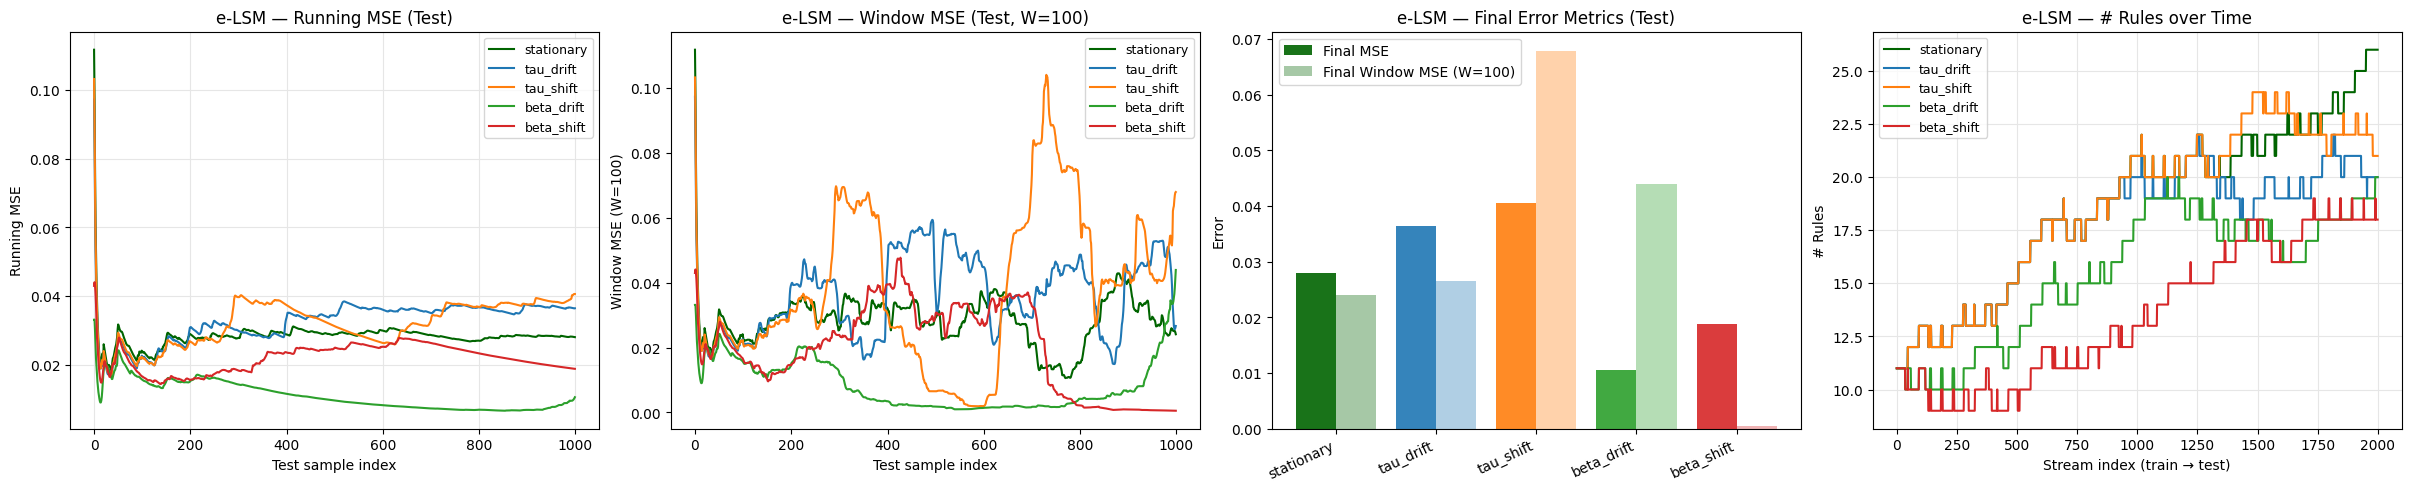

Dropdown(description='Dataset:', layout=Layout(width='450px'), options=('MG_stationary', 'MG_tau_drift', 'MG_t…

Output()

In [ ]:
# =========================
# CELL 12 — e-LSM visualization (compact, with window MSE)
# Row 1 (4 panels):
#   (1) running MSE | (2) window MSE | (3) final MSE + final window-MSE bars | (4) #rules over time
# Row 2:
#   4-panel drill-down for ONE dataset:
#     running MSE | window MSE | scatter | prediction vs target over time
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Optional (for dropdown UI in Colab)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# -----------------------
# Metrics
# -----------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def window_mse(y_true, y_pred, W=100):
    """
    Rolling/window MSE. Length = len(y_true).
    For k < W uses window [0..k]; afterwards uses last W samples.
    """
    e2 = (y_true - y_pred) ** 2
    out = np.zeros_like(e2, dtype=float)
    c = np.cumsum(e2)
    for k in range(len(e2)):
        if k < W:
            out[k] = c[k] / (k + 1)
        else:
            out[k] = (c[k] - c[k - W]) / W
    return out

# -----------------------
# Correct step() unpacker
# (matches your eRLSM.step -> (yhat, created_bool, merged_bool))
# -----------------------
def step_yhat_created_merged(step_out):
    if isinstance(step_out, (tuple, list)) and len(step_out) >= 3:
        return float(step_out[0]), int(bool(step_out[1])), int(bool(step_out[2]))
    if not isinstance(step_out, (tuple, list, np.ndarray)):
        return float(step_out), 0, 0
    return float(step_out[0]), 0, 0

# -----------------------
# Dataset order
# -----------------------
order = ["MG_stationary", "MG_tau_drift", "MG_tau_shift",
         "MG_beta_drift", "MG_beta_shift"]

# -----------------------
# Colors
# - Force MG_stationary to dark green (your “diabetes” green idea)
# - Others: automatic cycle
# -----------------------
DARK_GREEN = "#006400"  # darkgreen
cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4'])

color_map = {}
color_map["MG_stationary"] = DARK_GREEN

j = 0
for name in order:
    if name == "MG_stationary":
        continue
    color_map[name] = cycle[j % len(cycle)]
    j += 1

# -----------------------
# Light grid style (only selected panels)
# -----------------------
GRID_COLOR = "#E6E6E6"
GRID_LW = 0.8
GRID_ALPHA = 1.0

# -----------------------
# Window length
# -----------------------
W = 100

# ---------------------------------------------------------
# (A) Run e-LSM and store results
# ---------------------------------------------------------
elsm_store = {}
final_mse_elsm = {}
final_wmse_elsm = {}

for name in order:
    X_train, X_test, y_train, y_test = data_splits_norm[name]
    y_train = np.asarray(y_train, float).ravel()
    y_test  = np.asarray(y_test,  float).ravel()

    centers0, sigmas0 = kmeans_init_rules(X_train, N_INIT_RULES, SIGMA_SCALE, SEED)
    u0 = dlsm_fit(X_train, y_train, centers0, sigmas0)
    rules0 = EvolvingRules(centers0, sigmas0)
    model = eRLSM(rules0, u_init=u0)

    rule_counts = []
    created_test = 0
    merged_test = 0

    # TRAIN
    for x, yy in zip(X_train, y_train):
        model.step(x, yy)
        rule_counts.append(model.rules.num_rules())

    # TEST
    yhat_test = np.zeros_like(y_test, dtype=float)
    for k, (x, yy) in enumerate(zip(X_test, y_test)):
        out = model.step(x, yy)
        yhat, cflag, mflag = step_yhat_created_merged(out)
        yhat_test[k] = yhat
        rule_counts.append(model.rules.num_rules())
        created_test += cflag
        merged_test  += mflag

    rmse_curve = running_mse(y_test, yhat_test)
    wmse_curve = window_mse(y_test, yhat_test, W=W)

    mse_final = float(np.mean((y_test - yhat_test) ** 2))
    wmse_final = float(wmse_curve[-1])

    elsm_store[name] = dict(
        X_train_len=len(X_train),
        y_test=y_test,
        yhat_test=yhat_test,
        rmse_curve=rmse_curve,
        wmse_curve=wmse_curve,
        rule_counts=np.asarray(rule_counts, int),
        mse_final=mse_final,
        wmse_final=wmse_final,
        final_rules=int(rule_counts[-1]),
        avg_rules=float(np.mean(rule_counts)),
        created_during_test=int(created_test),
        merged_during_test=int(merged_test),
    )

    final_mse_elsm[name] = mse_final
    final_wmse_elsm[name] = wmse_final

# ---------------------------------------------------------
# (B) OVERVIEW — ROW 1 (4 PANELS)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 4.8), constrained_layout=True)

# (1) Running MSE
for name in order:
    axes[0].plot(
        elsm_store[name]["rmse_curve"],
        label=name.replace("MG_", ""),
        color=color_map[name]
    )
axes[0].set_xlabel("Test sample index")
axes[0].set_ylabel("Running MSE")
axes[0].set_title("e-LSM — Running MSE (Test)")
axes[0].legend(fontsize=9)
axes[0].set_axisbelow(True)
axes[0].grid(True, color=GRID_COLOR, linewidth=GRID_LW, alpha=GRID_ALPHA)

# (2) Window MSE
for name in order:
    axes[1].plot(
        elsm_store[name]["wmse_curve"],
        label=name.replace("MG_", ""),
        color=color_map[name]
    )
axes[1].set_xlabel("Test sample index")
axes[1].set_ylabel(f"Window MSE (W={W})")
axes[1].set_title(f"e-LSM — Window MSE (Test, W={W})")
axes[1].legend(fontsize=9)

# (3) Final bars: MSE + Window-MSE (two bars per dataset)
x = np.arange(len(order))
bar_w = 0.40
mse_vals = [final_mse_elsm[n] for n in order]
wmse_vals = [final_wmse_elsm[n] for n in order]

axes[2].bar(
    x - bar_w/2, mse_vals, width=bar_w,
    label="Final MSE",
    color=[color_map[n] for n in order],
    alpha=0.90
)
axes[2].bar(
    x + bar_w/2, wmse_vals, width=bar_w,
    label=f"Final Window MSE (W={W})",
    color=[color_map[n] for n in order],
    alpha=0.35
)
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace("MG_", "") for n in order],
                        rotation=25, ha="right")
axes[2].set_ylabel("Error")
axes[2].set_title("e-LSM — Final Error Metrics (Test)")
axes[2].legend()

# (4) #Rules over time (ALL datasets)
for name in order:
    axes[3].plot(
        elsm_store[name]["rule_counts"],
        label=name.replace("MG_", ""),
        color=color_map[name]
    )
axes[3].set_xlabel("Stream index (train → test)")
axes[3].set_ylabel("# Rules")
axes[3].set_title("e-LSM — # Rules over Time")
axes[3].legend(fontsize=9)
axes[3].set_axisbelow(True)
axes[3].grid(True, color=GRID_COLOR, linewidth=GRID_LW, alpha=GRID_ALPHA)

plt.show()

# ---------------------------------------------------------
# (C) DRILL-DOWN — ONE DATASET (4 PANELS)
#   running MSE | window MSE | scatter | prediction vs target over time
# ---------------------------------------------------------
def plot_detail_elsm(name):
    d = elsm_store[name]
    y_test = d["y_test"]
    yhat = d["yhat_test"]
    rmse_c = d["rmse_curve"]
    wmse_c = d["wmse_curve"]

    t = np.arange(len(y_test))

    fig, axes = plt.subplots(1, 4, figsize=(24, 4.8), constrained_layout=True)

    # (1) Running MSE
    axes[0].plot(rmse_c, color=color_map[name])
    axes[0].set_title("Running MSE (Test)")
    axes[0].set_xlabel("Test index")
    axes[0].set_ylabel("MSE")

    # (2) Window MSE
    axes[1].plot(wmse_c, color=color_map[name])
    axes[1].set_title(f"Window MSE (W={W})")
    axes[1].set_xlabel("Test index")
    axes[1].set_ylabel("MSE")

    # (3) Predicted vs True
    axes[2].scatter(y_test, yhat, s=18, alpha=0.7, color=color_map[name])
    mn = float(min(y_test.min(), yhat.min()))
    mx = float(max(y_test.max(), yhat.max()))
    axes[2].plot([mn, mx], [mn, mx], color="black")
    axes[2].set_xlabel("True y")
    axes[2].set_ylabel("Predicted ŷ")
    axes[2].set_title("Prediction vs True")

    # (4) Prediction vs target over time (TEST)
    axes[3].plot(t, y_test, label="True y", linewidth=2, color="black")
    axes[3].plot(t, yhat, label="Predicted ŷ", linewidth=2, color=color_map[name])
    axes[3].set_xlabel("Test index")
    axes[3].set_ylabel("y")
    axes[3].set_title("Prediction over Time (Test)")
    axes[3].legend()

    fig.suptitle(
        f"e-LSM — {name.replace('MG_', '')} | "
        f"MSE={d['mse_final']:.4f}, wMSE={d['wmse_final']:.4f} | "
        f"Created(TEST)={d['created_during_test']}, "
        f"Merged(TEST)={d['merged_during_test']}",
        fontsize=13
    )
    plt.show()

if HAS_WIDGETS:
    dd = widgets.Dropdown(
        options=order,
        value=order[0],
        description="Dataset:",
        layout=widgets.Layout(width="450px")
    )
    out = widgets.Output()

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            with out:
                clear_output(wait=True)
                plot_detail_elsm(change["new"])

    dd.observe(on_change)
    display(dd, out)

    with out:
        plot_detail_elsm(dd.value)
else:
    best = min(final_mse_elsm, key=final_mse_elsm.get)
    worst = max(final_mse_elsm, key=final_mse_elsm.get)
    plot_detail_elsm(best)
    plot_detail_elsm(worst)

**Global comparison: All datasets and all models for the Mackey-Glass problem**

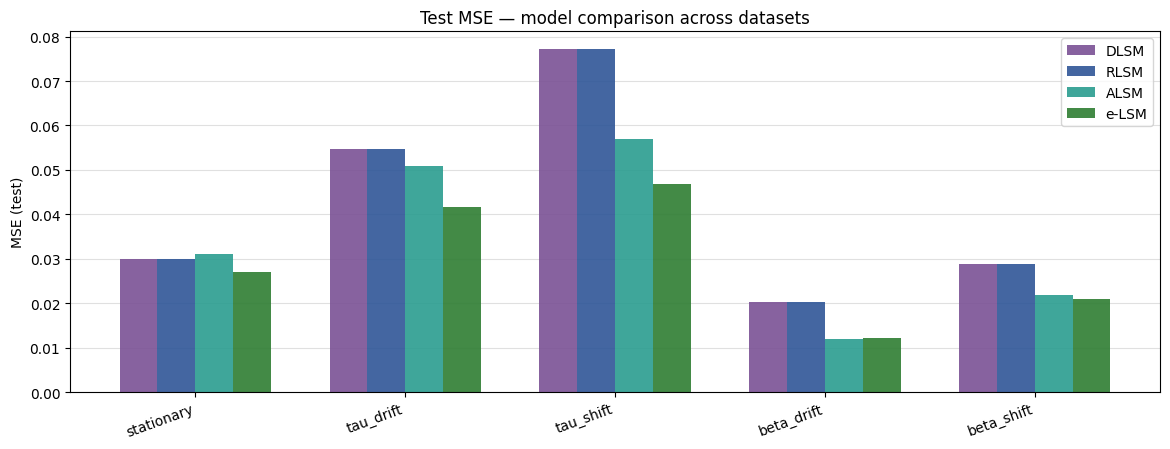

Dropdown(description='Dataset:', layout=Layout(width='450px'), options=('MG_stationary', 'MG_tau_drift', 'MG_t…

Output()

In [ ]:
# =========================
# CELL 13 — Global comparison (PLOTS ONLY)
# Includes:
#   - grouped bar chart (MSE)
#   - drill-down plots (running MSE + predictions)
#     and zooms 200–400 and 600–800 (2×2 layout)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import time

# Optional widgets
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# ---------------------------------------------------------
# Datasets / models
# ---------------------------------------------------------
order = [
    "MG_stationary",
    "MG_tau_drift",
    "MG_tau_shift",
    "MG_beta_drift",
    "MG_beta_shift"
]
models = ["DLSM", "RLSM", "ALSM", "e-LSM"]

# ---------------------------------------------------------
# Styling (same palette as Diabetes)
# ---------------------------------------------------------
model_color = {
    "DLSM":  "#7A5195",  # muted purple
    "RLSM":  "#2F5597",  # darker blue
    "ALSM":  "#2A9D8F",  # muted teal
    "e-LSM": "#2E7D32",  # darker green
}
TRUE_COLOR = "black"
LW_TRUE    = 1.8
LW_PRED    = 1.05
LW_RUNMSE  = 2.0

GRID_COLOR = "#E0E0E0"   # light gray grid (bar plot only)
GRID_LW    = 0.8

# ---------------------------------------------------------
# Utilities
# ---------------------------------------------------------
def running_mse(y_true, y_pred):
    e2 = (y_true - y_pred) ** 2
    return np.cumsum(e2) / (np.arange(len(e2)) + 1)

def _as1d(a):
    return np.asarray(a, float).ravel()

def _get_split(ds):
    X_train, X_test, y_train, y_test = data_splits_norm[ds]
    return X_train, X_test, _as1d(y_train), _as1d(y_test)

def _has(name):
    return name in globals()

# ---------------------------------------------------------
# DLSM predict helper (uses TAU_POWER if your DLSM cell has it)
# ---------------------------------------------------------
def get_dlsm_tau_power():
    if "TAU_POWER" in globals():
        try:
            return float(globals()["TAU_POWER"])
        except Exception:
            pass
    return 1.0

def predict_batch_dlsm(X, u, centers, sigmas, tau_power=1.0):
    yhat = np.zeros((X.shape[0],), float)
    for k, x in enumerate(X):
        tau = gaussian_rule_activations(x, centers, sigmas, 1e-12, tau_power=tau_power)
        d = build_d_from_tau(tau, 1e-12)
        yhat[k] = float(d @ u)
    return yhat

# ---------------------------------------------------------
# Per-model “get-or-run” helpers (prefer stored preds)
# ---------------------------------------------------------
def run_dlsm_one(ds):
    X_train, X_test, y_train, y_test = _get_split(ds)

    if _has("dlsm_preds") and isinstance(dlsm_preds, dict) and ds in dlsm_preds:
        yhat = _as1d(dlsm_preds[ds])
        rt = np.nan
        if _has("dlsm_stats") and isinstance(dlsm_stats, dict) and ds in dlsm_stats:
            rt = float(dlsm_stats[ds].get("runtime", np.nan))
        nr = int(globals().get("N_RULES", 20))
        return yhat, nr, rt

    t0 = time.perf_counter()
    tau_power = get_dlsm_tau_power()

    n_rules = int(globals().get("N_RULES", 20))
    sigma_scale = float(globals().get("SIGMA_SCALE", 0.45))
    use_global_sigma = bool(globals().get("USE_GLOBAL_SIGMA", True))
    sigma_floor = float(globals().get("SIGMA_FLOOR", 1e-3))
    seed = int(globals().get("SEED", 0))
    ridge_u = float(globals().get("RIDGE_U", 0.0))

    centers, sigmas = make_rules_kmeans(
        X_train, n_rules, sigma_scale, seed,
        use_global_sigma=use_global_sigma, sigma_floor=sigma_floor
    )
    u = dlsm_fit(X_train, y_train, centers, sigmas, 1e-12, 1e-12, tau_power=tau_power, ridge_u=ridge_u)
    yhat = predict_batch_dlsm(X_test, u, centers, sigmas, tau_power=tau_power)

    t1 = time.perf_counter()
    return _as1d(yhat), int(n_rules), float(t1 - t0)

def run_rlsm_one(ds):
    X_train, X_test, y_train, y_test = _get_split(ds)

    if _has("rlsm_preds") and isinstance(rlsm_preds, dict) and ds in rlsm_preds:
        yhat = _as1d(rlsm_preds[ds])
        rt = np.nan
        if _has("rlsm_stats") and isinstance(rlsm_stats, dict) and ds in rlsm_stats:
            rt = float(rlsm_stats[ds].get("runtime", np.nan))
        nr = int(globals().get("N_RULES", 20))
        return yhat, nr, rt

    t0 = time.perf_counter()
    n_rules = int(globals().get("N_RULES", 20))
    sigma_scale = float(globals().get("SIGMA_SCALE", 0.80))
    seed = int(globals().get("SEED", 0))

    centers, sigmas = make_rules_kmeans(X_train, n_rules, sigma_scale, seed)

    alpha = float(globals().get("ALPHA", 1e5))
    lam   = float(globals().get("LAMBDA", 1.0))
    eps   = float(globals().get("EPS", 1e-12))
    update_on_test = bool(globals().get("UPDATE_ON_TEST", False))

    rlsm = RLSM(n_rules=n_rules, alpha=alpha, lam=lam, eps=eps)
    _ = predict_with_optional_update(rlsm, X_train, y_train, centers, sigmas, do_update=True, eps=eps)
    yhat = predict_with_optional_update(rlsm, X_test, y_test, centers, sigmas, do_update=update_on_test, eps=eps)

    t1 = time.perf_counter()
    return _as1d(yhat), int(n_rules), float(t1 - t0)

def run_alsm_one(ds):
    X_train, X_test, y_train, y_test = _get_split(ds)

    # <<< CHANGED: if we reuse stored predictions, also reuse stored runtime
    if _has("alsm_preds") and isinstance(alsm_preds, dict) and ds in alsm_preds:
        yhat = _as1d(alsm_preds[ds])

        rt = np.nan
        # preferred: dict of runtimes created in your updated Cell 9
        if _has("alsm_time_s") and isinstance(alsm_time_s, dict) and ds in alsm_time_s:
            try:
                rt = float(alsm_time_s[ds])
            except Exception:
                pass
        # fallback: stats dict created in Cell 9
        if (not np.isfinite(rt)) and _has("alsm_stats") and isinstance(alsm_stats, dict) and ds in alsm_stats:
            try:
                rt = float(alsm_stats[ds].get("runtime", np.nan))
            except Exception:
                pass

        nr = int(globals().get("N_RULES", 20))
        return yhat, nr, rt

    # (If not stored, run and time it)
    t0 = time.perf_counter()
    n_rules = int(globals().get("N_RULES", 20))
    sigma_scale = float(globals().get("SIGMA_SCALE", 1.00))
    seed = int(globals().get("SEED", 0))

    centers, sigmas = make_rules_kmeans(X_train, n_rules, sigma_scale, seed)

    alpha = float(globals().get("ALPHA", 1e3))
    lam   = float(globals().get("LAMBDA", 0.995))
    zeta  = float(globals().get("ZETA", 0.25))
    ridge = float(globals().get("RIDGE", 1e-3))
    clip  = bool(globals().get("CLIP_YHAT", True))
    eps   = float(globals().get("EPS", 1e-12))
    update_on_test = bool(globals().get("UPDATE_ON_TEST", True))

    alsm = ALSM(n_rules=n_rules, alpha=alpha, lam=lam, zeta=zeta, ridge=ridge, clip_yhat=clip, eps=eps)
    _ = run_stream(alsm, X_train, y_train, centers, sigmas, do_update=True)
    yhat_test, _ = run_stream(alsm, X_test, y_test, centers, sigmas, do_update=update_on_test)

    t1 = time.perf_counter()
    return _as1d(yhat_test), int(n_rules), float(t1 - t0)

def _try_get_elsm_runtime(ds):
    if _has("elsm_time_s") and isinstance(elsm_time_s, dict) and ds in elsm_time_s:
        try:
            return float(elsm_time_s[ds])
        except Exception:
            pass
    if _has("elsm_store") and isinstance(elsm_store, dict) and ds in elsm_store and "runtime" in elsm_store[ds]:
        try:
            return float(elsm_store[ds]["runtime"])
        except Exception:
            pass
    return np.nan

def measure_elsm_runtime(ds):
    X_train, X_test, y_train, y_test = _get_split(ds)

    t0 = time.perf_counter()
    centers0, sigmas0 = kmeans_init_rules(X_train, N_INIT_RULES, SIGMA_SCALE, SEED)
    u0 = dlsm_fit(X_train, y_train, centers0, sigmas0)
    rules0 = EvolvingRules(centers0, sigmas0)
    m = eRLSM(rules0, u_init=u0)

    for x, yy in zip(X_train, y_train):
        m.step(x, yy)
    for x, yy in zip(X_test, y_test):
        m.step(x, yy)

    t1 = time.perf_counter()
    return float(t1 - t0)

def run_elsm_one(ds):
    if _has("elsm_store") and isinstance(elsm_store, dict) and ds in elsm_store and "yhat_test" in elsm_store[ds]:
        yhat = _as1d(elsm_store[ds]["yhat_test"])
        nr = int(elsm_store[ds].get("final_rules", np.nan))
    else:
        X_train, X_test, y_train, y_test = _get_split(ds)
        centers0, sigmas0 = kmeans_init_rules(X_train, N_INIT_RULES, SIGMA_SCALE, SEED)
        u0 = dlsm_fit(X_train, y_train, centers0, sigmas0)
        rules0 = EvolvingRules(centers0, sigmas0)
        m = eRLSM(rules0, u_init=u0)

        for x, yy in zip(X_train, y_train):
            m.step(x, yy)

        yhat = np.zeros_like(y_test, dtype=float)
        for k, (x, yy) in enumerate(zip(X_test, y_test)):
            out = m.step(x, yy)
            yhat[k] = float(out[0]) if isinstance(out, (tuple, list)) else float(out)
        nr = int(m.rules.num_rules())

    rt = _try_get_elsm_runtime(ds)
    if not np.isfinite(rt):
        rt = measure_elsm_runtime(ds)
        try:
            if _has("elsm_store") and ds in elsm_store:
                elsm_store[ds]["runtime"] = rt
        except Exception:
            pass

    return _as1d(yhat), int(nr), float(rt)

# ---------------------------------------------------------
# Run ALL experiments
# ---------------------------------------------------------
pred_all  = {m: {} for m in models}
rules_all = {m: {} for m in models}
time_all  = {m: {} for m in models}

for ds in order:
    yhat, nr, rt = run_dlsm_one(ds)
    pred_all["DLSM"][ds], rules_all["DLSM"][ds], time_all["DLSM"][ds] = yhat, nr, rt

    yhat, nr, rt = run_rlsm_one(ds)
    pred_all["RLSM"][ds], rules_all["RLSM"][ds], time_all["RLSM"][ds] = yhat, nr, rt

    yhat, nr, rt = run_alsm_one(ds)
    pred_all["ALSM"][ds], rules_all["ALSM"][ds], time_all["ALSM"][ds] = yhat, nr, rt

    yhat, nr, rt = run_elsm_one(ds)
    pred_all["e-LSM"][ds], rules_all["e-LSM"][ds], time_all["e-LSM"][ds] = yhat, nr, rt

# ---------------------------------------------------------
# Plot 1: grouped bars (MSE) — grid only here
# ---------------------------------------------------------
mse_plot = np.zeros((len(order), len(models)), float)
for i, ds in enumerate(order):
    _, _, _, y_test = data_splits_norm[ds]
    y_test = _as1d(y_test)
    for j, m in enumerate(models):
        yhat = _as1d(pred_all[m][ds])
        mse_plot[i, j] = mean_squared_error(y_test, yhat)

x = np.arange(len(order))
bar_w = 0.18

fig = plt.figure(figsize=(11.8, 4.6))
ax = plt.gca()

for j, m in enumerate(models):
    ax.bar(
        x + (j - (len(models)-1)/2)*bar_w,
        mse_plot[:, j],
        width=bar_w,
        label=m,
        color=model_color[m],
        alpha=0.90,
        edgecolor="none"
    )

ax.set_xticks(x)
ax.set_xticklabels([d.replace("MG_", "") for d in order], rotation=20, ha="right")
ax.set_ylabel("MSE (test)")
ax.set_title("Test MSE — model comparison across datasets")

ax.set_axisbelow(True)
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=GRID_LW)
ax.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Drill-down: ONE dataset, ALL models (2×2), clean (NO grid)
#   (1) Running MSE (legend includes FINAL MSE)
#   (2) Predictions full
#   (3) Zoom 200–400
#   (4) Zoom 600–800
# ---------------------------------------------------------
def plot_global_detail(ds):
    _, _, _, y_test = data_splits_norm[ds]
    y_test = _as1d(y_test)
    t = np.arange(len(y_test))

    z1a, z1b = 200, min(400, len(t))
    z2a, z2b = 600, min(800, len(t))

    fig, axes = plt.subplots(2, 2, figsize=(16, 9.0), constrained_layout=True)

    # (1) Running MSE
    ax0 = axes[0, 0]
    for m in models:
        yhat = _as1d(pred_all[m][ds])
        mse_final = float(mean_squared_error(y_test, yhat))
        ax0.plot(
            running_mse(y_test, yhat),
            label=f"{m} (MSE={mse_final:.4f})",
            color=model_color[m],
            linewidth=LW_RUNMSE,
            linestyle="solid",
            alpha=0.95
        )
    ax0.set_title(f"Running MSE — {ds.replace('MG_', '')}")
    ax0.set_xlabel("Test sample index")
    ax0.set_ylabel("Running MSE")
    ax0.legend()

    def _plot_pred(ax, a, b, title):
        ax.plot(
            t[a:b], y_test[a:b],
            label="True y",
            color=TRUE_COLOR,
            linewidth=LW_TRUE,
            linestyle="solid",
            alpha=0.9
        )
        for m in models:
            yhat = _as1d(pred_all[m][ds])
            ax.plot(
                t[a:b], yhat[a:b],
                label=m,
                color=model_color[m],
                linewidth=LW_PRED,
                linestyle="solid",
                alpha=0.95
            )
        ax.set_title(title)
        ax.set_xlabel("Test sample index")
        ax.set_ylabel("y")
        ax.legend(fontsize=9)

    _plot_pred(axes[0, 1], 0, len(t), f"Predictions — full ({ds.replace('MG_','')})")

    if z1a < z1b:
        _plot_pred(axes[1, 0], z1a, z1b, "Predictions — zoom 200–400")
    else:
        axes[1, 0].text(0.5, 0.5, "Test shorter than 400 samples", ha="center", va="center")
        axes[1, 0].set_axis_off()

    if z2a < z2b:
        _plot_pred(axes[1, 1], z2a, z2b, "Predictions — zoom 600–800")
    else:
        axes[1, 1].text(0.5, 0.5, "Test shorter than 800 samples", ha="center", va="center")
        axes[1, 1].set_axis_off()

    plt.show()

if HAS_WIDGETS:
    dd = widgets.Dropdown(
        options=order,
        value=order[0],
        description="Dataset:",
        layout=widgets.Layout(width="450px")
    )
    out = widgets.Output()

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            with out:
                clear_output(wait=True)
                plot_global_detail(change["new"])

    dd.observe(on_change)
    display(dd, out)

    with out:
        plot_global_detail(dd.value)
else:
    plot_global_detail(order[0])

In [ ]:
# =========================
# CELL 14 — Global comparison TABLE ONLY (ALL datasets × ALL models)
# Plain print below
# Uses pred_all, rules_all, time_all from CELL 13.
# =========================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _as1d(a):
    return np.asarray(a, float).ravel()

rows = []
for ds in order:
    _, _, _, y_test = data_splits_norm[ds]
    y_test = _as1d(y_test)
    n_samples = int(len(y_test))

    for m in models:
        yhat = _as1d(pred_all[m][ds])

        mse  = float(mean_squared_error(y_test, yhat))
        rmse = float(np.sqrt(mse))
        mae  = float(mean_absolute_error(y_test, yhat))
        r2   = float(r2_score(y_test, yhat))

        nr = int(rules_all[m][ds])
        rt = float(time_all[m][ds]) if np.isfinite(time_all[m][ds]) else np.nan
        msps = (1000.0 * rt / n_samples) if (np.isfinite(rt) and n_samples > 0) else np.nan

        rows.append((ds, m, nr, mse, rmse, mae, r2, rt, msps))

line = "-" * 140
print("GLOBAL COMPARISON: MACKEY-GLASS — TEST SET")
print(line)
print(f"{'Dataset':<14} {'Model':<6} {'#Rules':<8} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'R2':<10} {'Time(s)':<12} {'ms/sample':<10}")
print(line)

for ds in order:
    for m in models:
        r = next(rr for rr in rows if rr[0] == ds and rr[1] == m)
        _, m_, nr, mse, rmse, mae, r2, rt, msps = r
        rt_str   = f"{rt:.4f}" if np.isfinite(rt) else "NA"
        msps_str = f"{msps:.3f}" if np.isfinite(msps) else "NA"
        print(
            f"{ds.replace('MG_',''):<14} {m_:<6} {nr:<8d} "
            f"{mse:<12.6f} {rmse:<12.6f} {mae:<12.6f} {r2:<10.4f} {rt_str:<12} {msps_str:<10}"
        )
    print(line)

GLOBAL COMPARISON: MACKEY-GLASS — TEST SET
--------------------------------------------------------------------------------------------------------------------------------------------
Dataset        Model  #Rules   MSE          RMSE         MAE          R2         Time(s)      ms/sample 
--------------------------------------------------------------------------------------------------------------------------------------------
stationary     DLSM   20       0.030008     0.173228     0.138200     0.5044     0.1987       0.199     
stationary     RLSM   20       0.030009     0.173230     0.138199     0.5043     0.5797       0.580     
stationary     ALSM   20       0.031028     0.176146     0.137201     0.4875     0.5588       0.559     
stationary     e-LSM  26       0.027064     0.164511     0.127616     0.5530     0.7963       0.796     
--------------------------------------------------------------------------------------------------------------------------------------------
tau_drift

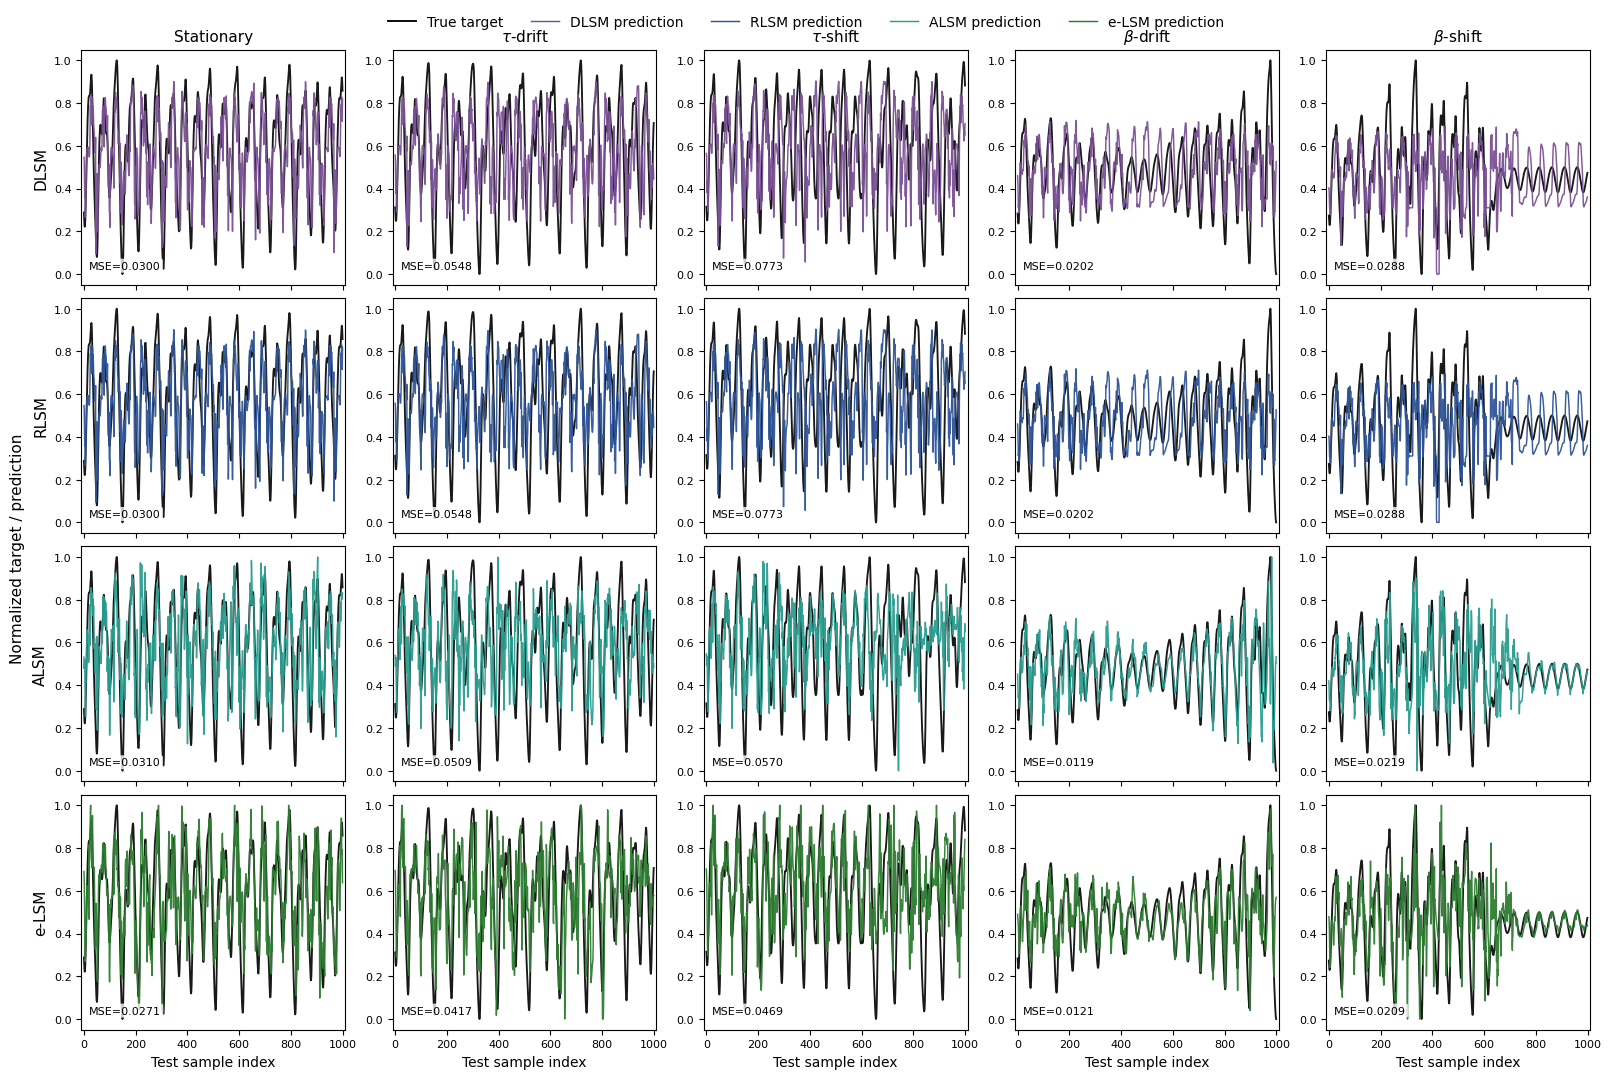

In [ ]:
# =========================
# CELL 15 — 4x5 matrix of predictions vs true values
# Rows   = models
# Cols   = datasets
# Uses variables from Cell 13:
#   order, models, pred_all, data_splits_norm, model_color
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from matplotlib.lines import Line2D

# -------------------------
# Styling
# -------------------------
TRUE_COLOR = "black"
LW_TRUE = 1.35
LW_PRED = 1.05

dataset_titles = {
    "MG_stationary": "Stationary",
    "MG_tau_drift": r"$\tau$-drift",
    "MG_tau_shift": r"$\tau$-shift",
    "MG_beta_drift": r"$\beta$-drift",
    "MG_beta_shift": r"$\beta$-shift",
}

row_labels = {
    "DLSM": "DLSM",
    "RLSM": "RLSM",
    "ALSM": "ALSM",
    "e-LSM": "e-LSM",
}

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(order),
    figsize=(16, 10.5),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

axes = np.atleast_2d(axes)

for i, m in enumerate(models):
    for j, ds in enumerate(order):
        ax = axes[i, j]

        # test targets
        _, _, _, y_test = data_splits_norm[ds]
        y_test = np.asarray(y_test, float).ravel()

        # predictions
        yhat = np.asarray(pred_all[m][ds], float).ravel()

        # time index for test portion
        t = np.arange(len(y_test))

        # plot true and predicted
        ax.plot(
            t, y_test,
            color=TRUE_COLOR,
            linewidth=LW_TRUE,
            alpha=0.9
        )
        ax.plot(
            t, yhat,
            color=model_color[m],
            linewidth=LW_PRED,
            alpha=0.95
        )

        # MSE in each panel (bottom-left)
        mse = mean_squared_error(y_test, yhat)
        ax.text(
            0.03, 0.06,
            f"MSE={mse:.4f}",
            transform=ax.transAxes,
            fontsize=8,
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.78
            )
        )

        # column titles
        if i == 0:
            ax.set_title(dataset_titles.get(ds, ds.replace("MG_", "")), fontsize=11)

        # row labels
        if j == 0:
            ax.set_ylabel(row_labels[m], fontsize=11)

        # axes cosmetics
        ax.tick_params(labelsize=8)
        ax.margins(x=0.01)

# x-label only on bottom row
for j in range(len(order)):
    axes[-1, j].set_xlabel("Test sample index", fontsize=10)

# common y label
fig.supylabel("Normalized target / prediction", fontsize=11)

# -------------------------
# Global legend (manual, 5 entries)
# -------------------------
legend_handles = [
    Line2D([0], [0], color=TRUE_COLOR, lw=LW_TRUE, label="True target"),
    Line2D([0], [0], color=model_color["DLSM"], lw=LW_PRED, label="DLSM prediction"),
    Line2D([0], [0], color=model_color["RLSM"], lw=LW_PRED, label="RLSM prediction"),
    Line2D([0], [0], color=model_color["ALSM"], lw=LW_PRED, label="ALSM prediction"),
    Line2D([0], [0], color=model_color["e-LSM"], lw=LW_PRED, label="e-LSM prediction"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.02)
)

# Save high-resolution figure for LaTeX
plt.savefig("Fig_predictions_4x5.png", dpi=300, bbox_inches="tight")
plt.show()

**Table interpretation:**

**No. Rules** → interpretability / model complexity  
↓ lower is better  
(fewer rules = simpler, more interpretable model)

**MSE** → accuracy (quadratic error)  
↓ lower is better  
(penalizes large errors more strongly)

**RMSE** → accuracy (scale-aware)  
↓ lower is better  
(same units as the output variable)

**MAE** → robustness to outliers  
↓ lower is better  
(less sensitive to large deviations than MSE)

**R²** → global explanatory power  
↑ higher is better  
(1 = perfect fit, 0 = baseline predictor)

**Runtime (s)** → total computational cost  
↓ lower is better  
(wall-clock time for training + test evaluation)

**ms/sample** → computational efficiency per data point  
↓ lower is better  
(normalized cost, useful for comparing scalability and online suitability)

## Discussion and Conclusions — Mackey–Glass Experiments

The Mackey–Glass experiments provide a controlled yet challenging benchmark to assess the behavior of Level-Set regression models under stationary, gradually drifting, and abruptly shifting dynamics. By varying the parameters: delay $\tau$, and feedback gain $\beta$ of the underlying system, the resulting data streams expose different forms of nonstationarity while preserving a common nonlinear generative structure.

The results reveal clear differences between fixed-structure and adaptive and evolving learning paradigms. Batch DLSM and recursive RLSM exhibit nearly identical performance in all scenarios, indicating that recursive parameter updates alone—under a fixed rule base and near-unity forgetting—do not substantially improve generalization. The adaptive ALSM consistently outperforms DLSM and RLSM under drift and shift, confirming that correntropy-weighted updates improve robustness to nonstationary disturbances. Nevertheless, **all three approaches remain constrained by a fixed rule structure**, which limits their capacity to represent newly emerging local behaviors when the system dynamics change.

The proposed **evolving Level-Set Model (e-LSM)** achieves the lowest test errors in all Mackey–Glass scenarios, demonstrating the benefit of controlled structural adaptation. Importantly, this improvement is not achieved through unrestricted growth. Instead, e-LSM relies on activation- and error-gated rule creation, reliability-weighted rule influence, incremental adaptation of rule centers and dispersions, and periodic distance-based merging of redundant rules.

As a consequence, the number of rules stabilizes at a moderate level, typically between $20$ and $26$ rules, even under pronounced drift and abrupt regime shifts. This behavior contrasts with naive evolving schemes that tend to over-fragment the input space and compromise interpretability.

From a computational perspective, e-LSM incurs a higher per-sample cost than fixed-structure baselines due to its structural operations. However, the observed runtimes remain within the millisecond range and are compatible with online processing. This efficiency is enabled by vectorized activation computation, soft growth throttling, and inexpensive winner–neighbor merging.

Overall, the Mackey–Glass experiments demonstrate that e-LSM provides an effective compromise between accuracy, adaptability, and interpretability. By allowing structural evolution only when justified by novelty or sustained error, the model adapts to nonstationary dynamics without sacrificing compactness or transparency, supporting its use as an evolving regression framework for streaming environments.

**---------------------------------------------------------------------------------------------------------------------------------**


**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

**---------------------------------------------------------------------------------------------------------------------------------**

## **Experiment 3: ... dataset - Load & split data (50/50)**